# Set UP


## Importing the BioXTAS API


In [86]:
import bioxtasraw.RAWAPI as raw
import bioxtasraw.RAWPlot as RAWPlot
import bioxtasraw.SASCalc as SASCalc


import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import glob
import os

from pptx import Presentation
from pptx.util import Inches
import tempfile

import imageio.v2 as imageio
import math

from scipy import optimize
from scipy import special



color = 'orangered'

In [2]:
AA_hdf5='./data/AA_042025.hdf5'



Set Up SAXS Settings

In [3]:
my_settings = raw.load_settings('/Applications/raw/docs/source/saxs/images/figure_data/SAXS.cfg')

/opt/anaconda3/envs/RAW/lib/python3.14/site-packages/bioxtasraw/RAWSettings.py:935: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  settings = pickle_obj.load()


## Load Series from Hdf5 file *For SEC-SAXS 

In [4]:
#Define a list of series filenames to load
series_names = [AA_hdf5]

#Load the series
series = raw.load_series(series_names)
print(series)

In [5]:
my_series = series[0]

frames = my_series.getFrames()
total_i = my_series.getIntI()
mean_i = my_series.getMeanI()


Text(0, 0.5, 'Total I')

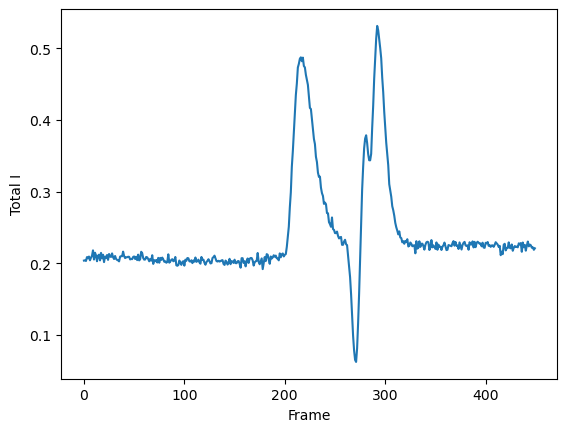

In [6]:
plt.plot(frames, total_i, label='Total I')
plt.xlabel('Frame')
plt.ylabel('Total I')

#### if only buffer subtraction is done

In [7]:
#Set buffer range
success, region_start, region_end = raw.find_buffer_range(my_series)
print(f"Buffer range found: {success}, start: {region_start}, end: {region_end}")
    
(sub_profiles, rg, rger, i0, i0er, vcmw, vcmwer,
    vpmw) = raw.set_buffer_range(my_series, [[region_start, region_end]])


Buffer range found: True, start: 162, end: 184


/opt/anaconda3/envs/RAW/lib/python3.14/site-packages/bioxtasraw/SASCalc.py:258: RuntimeWarning: invalid value encountered in log10
  iratio = np.abs(np.log10(i0/i) - 2.25)


Subtracted Series for ./data/AA_042025.hdf5:


Text(0, 0.5, 'Total Intensity')

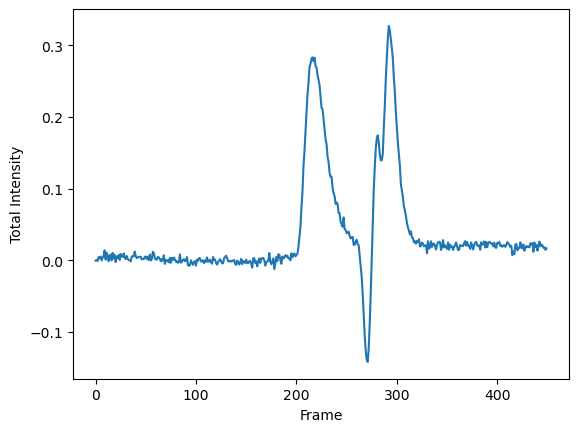

In [9]:
subtracted_total_i = my_series.getIntI('sub')
subtracted_mean_i = my_series.getMeanI('sub')

print(f"Subtracted Series for {series_names[0]}:")
plt.plot(frames, subtracted_total_i, label='subtracted Total I')
plt.xlabel('Frame')
plt.ylabel('Total Intensity')

In [10]:
frames = my_series.getFrames()
total_i = my_series.getIntI()
mean_i = my_series.getMeanI()

subtracted_total_i = my_series.getIntI('sub')
subtracted_mean_i = my_series.getMeanI('sub')


In [11]:
def to_int_scalar(x, fallback=0):
    if x is None:
        return int(fallback)
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.ravel(np.asarray(x))
        if arr.size == 0:
            return int(fallback)
        return int(arr[0])
    try:
        return int(x)
    except Exception:
        return int(fallback)

frames.shape: (450,)
total_i.shape: (450,)


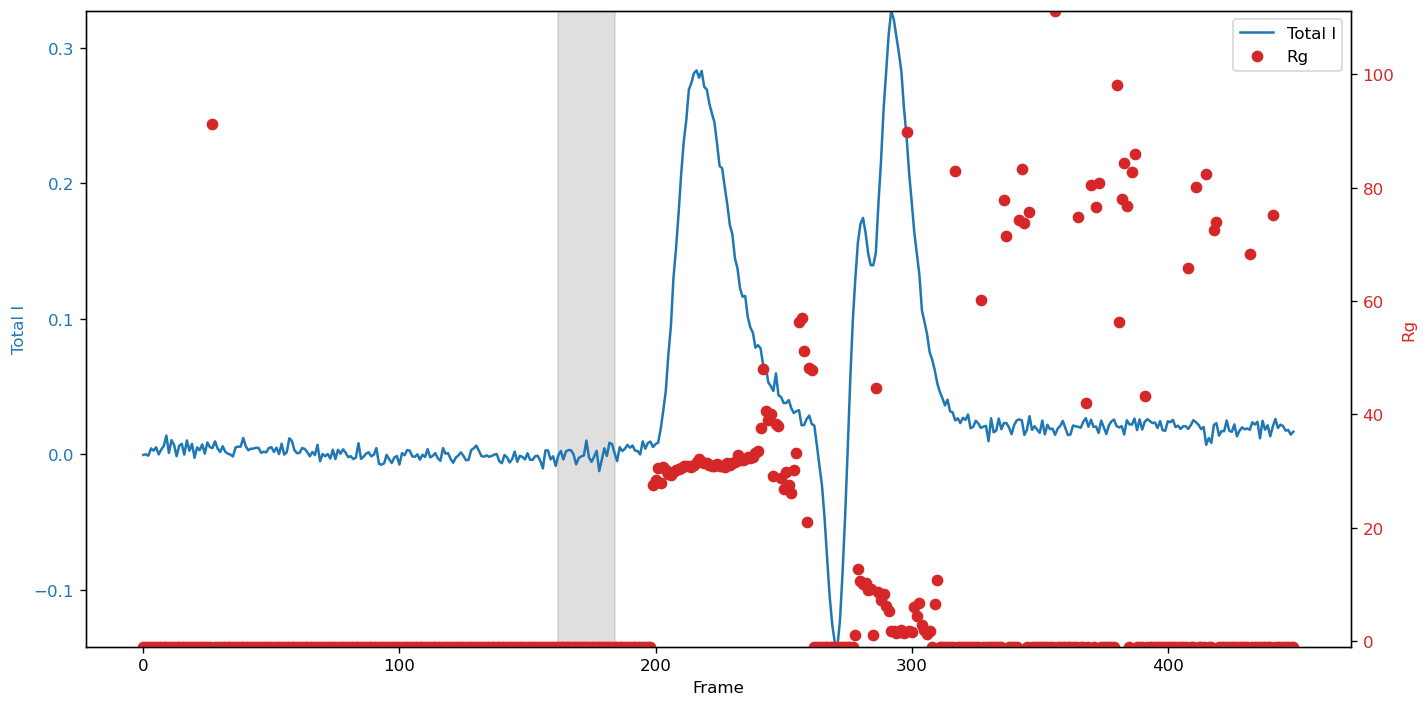

In [12]:
# Plot subtracted_total_i and rg on the same figure with two y-axes, highlighting the buffer region
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=120)

# find background buffer start and end (use defaults if not)
buffer_region_start = to_int_scalar(region_start, 0)
buffer_region_end   = to_int_scalar(region_end, 0)

# lightly translucent rectangle for buffer region (behind the plotted lines)
ax1.axvspan(buffer_region_start, buffer_region_end, color='gray', alpha=0.25, zorder=0)

# Robustly align x (frames) and y (total_i) lengths before plotting
x = frames
y = subtracted_total_i

print("frames.shape:", getattr(x, 'shape', None))
print("total_i.shape:", getattr(y, 'shape', None))

# If total_i is 2D, collapse q axis to produce one scalar per frame
if hasattr(y, 'ndim') and y.ndim == 2:
    # try obvious mappings
    if y.shape[0] == x.shape[0]:
        per_frame = np.sum(y, axis=1)
        x_plot = x
    elif y.shape[1] == x.shape[0]:
        per_frame = np.sum(y, axis=0)
        x_plot = x
    else:
        # fallback: collapse axis 1 and use integer index for x
        per_frame = np.sum(y, axis=1)
        x_plot = np.arange(len(per_frame))
        print("Warning: frames length does not match total_i; plotting per-frame sum vs index.")
else:
    # y is 1D
    if len(y) == len(x):
        per_frame = y
        x_plot = x
    else:
        # fallback: plot y vs its own index
        per_frame = y
        x_plot = np.arange(len(y))
        print("Warning: frames length does not match total_i; plotting total_i vs index.")

c1 = 'tab:blue'
ax1.plot(x_plot, per_frame, color=c1, label='Total I')
ax1.set_xlabel('Frame' if x_plot is frames else 'Index')
ax1.set_ylabel('Total I', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)
# set y limits safely ignoring NaNs
try:
    ymin, ymax = np.nanmin(per_frame), np.nanmax(per_frame)
    if ymin == ymax:
        ymin -= 0.5; ymax += 0.5
    ax1.set_ylim(ymin, ymax)
except ValueError:
    pass

ax2 = ax1.twinx()
c2 = 'tab:red'

# Align rg to x_plot if possible, otherwise plot rg vs its own index
rg_arr = np.asarray(rg)
if rg_arr.shape[0] == x_plot.shape[0]:
    ax2.plot(x_plot, rg_arr, color=c2, marker='o', linestyle='None', label='Rg')
else:
    ax2.plot(np.arange(len(rg_arr)), rg_arr, color=c2, marker='o', linestyle='None', label='Rg')
    print("Warning: rg length does not match x used for Total I; plotting rg vs its own index.")

ax2.set_ylabel('Rg', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)
try:
    ymin2, ymax2 = np.nanmin(rg_arr), np.nanmax(rg_arr)
    if ymin2 == ymax2:
        ymin2 -= 0.5; ymax2 += 0.5
    ax2.set_ylim(ymin2, ymax2)
except ValueError:
    pass

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

fig.tight_layout()
plt.show()

### Finding and setting buffer and sample regions



In [13]:
# Baseline Correction
# Validate baseline range
(lin_valid, lin_valid_results, lin_similarity_results, lin_svd_results,
    lin_intI_results, lin_other_results) = raw.validate_baseline_range(
    my_series, [0, 10], [439, 449], 'Linear')

#Do baseline correction
(lin_bl_cor_profiles, lin_rg, lin_rger, lin_i0, lin_i0er, lin_vcmw, lin_vcmwer,
    lin_vpmw, lin_bl_corr, lin_fit_results) = raw.set_baseline_correction(
    my_series, [0, 10], [439, 449], 'Linear')

In [14]:
subtracted_total_i = my_series.getIntI('baseline')
subtracted_mean_i = my_series.getMeanI('baseline')


Baseline Corrected Series for ./data/AA_042025.hdf5:


Text(0, 0.5, 'Total Intensity')

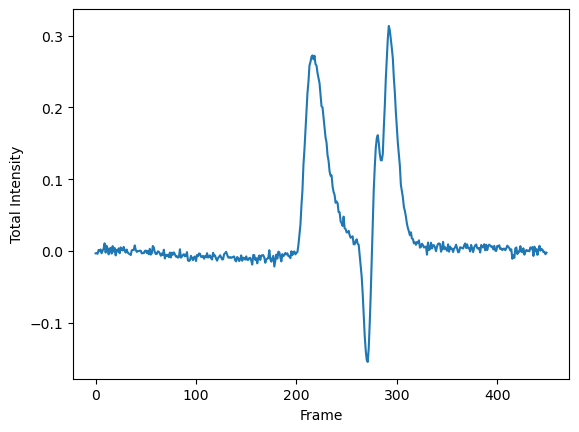

In [15]:
print(f"Baseline Corrected Series for {series_names[0]}:")
plt.plot(frames, subtracted_total_i, label='subtracted Total I')
plt.xlabel('Frame')
plt.ylabel('Total Intensity')

## Back to regular selection

In [16]:
def to_int_scalar(x, fallback=0):
    if x is None:
        return int(fallback)
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.ravel(np.asarray(x))
        if arr.size == 0:
            return int(fallback)
        return int(arr[0])
    try:
        return int(x)
    except Exception:
        return int(fallback)

In [17]:
frames = my_series.getFrames()
total_i = my_series.getIntI()
mean_i = my_series.getMeanI()

subtracted_total_i = my_series.getIntI('baseline')
subtracted_mean_i = my_series.getMeanI('baseline')


frames.shape: (450,)
total_i.shape: (450,)


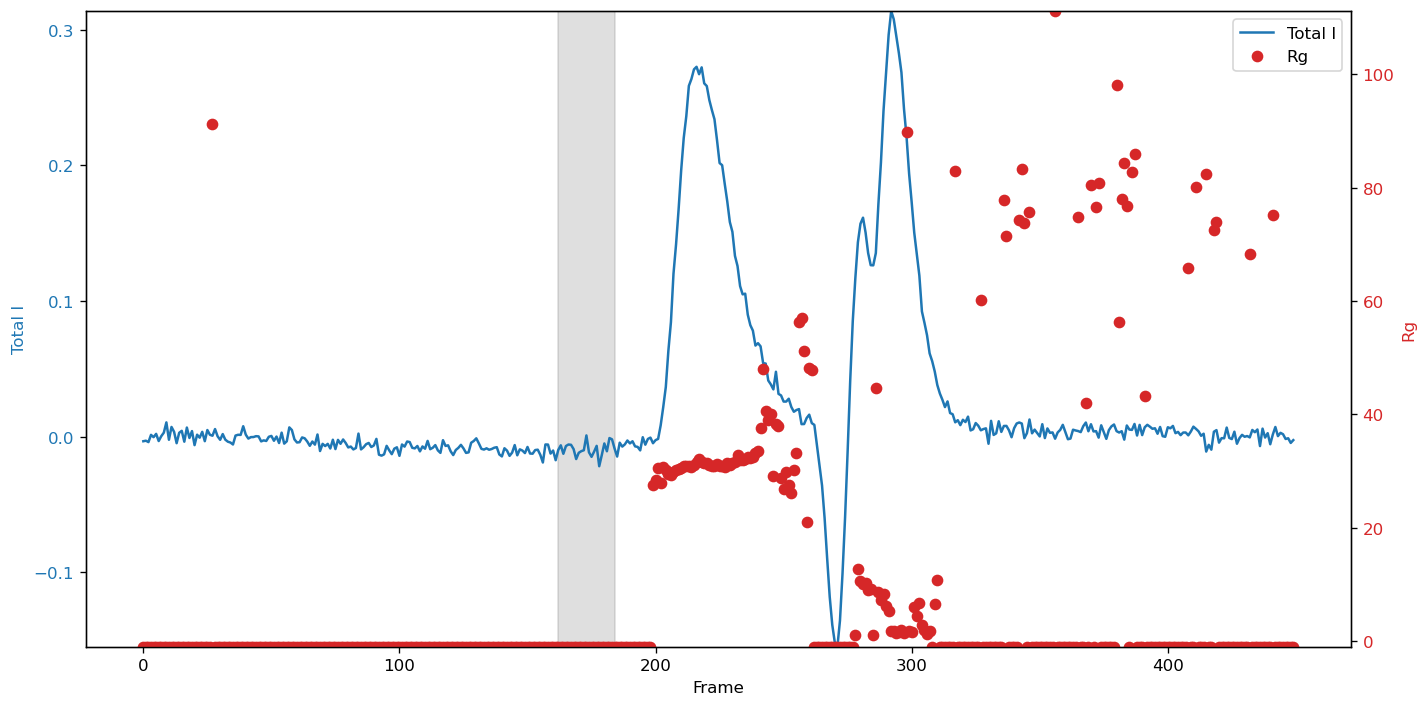

In [18]:
# Plot subtracted_total_i and rg on the same figure with two y-axes, highlighting the buffer region
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=120)

# find background buffer start and end (use defaults if not)
buffer_region_start = to_int_scalar(region_start, 0)
buffer_region_end   = to_int_scalar(region_end, 0)

# lightly translucent rectangle for buffer region (behind the plotted lines)
ax1.axvspan(buffer_region_start, buffer_region_end, color='gray', alpha=0.25, zorder=0)

# Robustly align x (frames) and y (total_i) lengths before plotting
x = frames
y = subtracted_total_i

print("frames.shape:", getattr(x, 'shape', None))
print("total_i.shape:", getattr(y, 'shape', None))

# If total_i is 2D, collapse q axis to produce one scalar per frame
if hasattr(y, 'ndim') and y.ndim == 2:
    # try obvious mappings
    if y.shape[0] == x.shape[0]:
        per_frame = np.sum(y, axis=1)
        x_plot = x
    elif y.shape[1] == x.shape[0]:
        per_frame = np.sum(y, axis=0)
        x_plot = x
    else:
        # fallback: collapse axis 1 and use integer index for x
        per_frame = np.sum(y, axis=1)
        x_plot = np.arange(len(per_frame))
        print("Warning: frames length does not match total_i; plotting per-frame sum vs index.")
else:
    # y is 1D
    if len(y) == len(x):
        per_frame = y
        x_plot = x
    else:
        # fallback: plot y vs its own index
        per_frame = y
        x_plot = np.arange(len(y))
        print("Warning: frames length does not match total_i; plotting total_i vs index.")

c1 = 'tab:blue'
ax1.plot(x_plot, per_frame, color=c1, label='Total I')
ax1.set_xlabel('Frame' if x_plot is frames else 'Index')
ax1.set_ylabel('Total I', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)
# set y limits safely ignoring NaNs
try:
    ymin, ymax = np.nanmin(per_frame), np.nanmax(per_frame)
    if ymin == ymax:
        ymin -= 0.5; ymax += 0.5
    ax1.set_ylim(ymin, ymax)
except ValueError:
    pass

ax2 = ax1.twinx()
c2 = 'tab:red'

# Align rg to x_plot if possible, otherwise plot rg vs its own index
rg_arr = np.asarray(rg)
if rg_arr.shape[0] == x_plot.shape[0]:
    ax2.plot(x_plot, rg_arr, color=c2, marker='o', linestyle='None', label='Rg')
else:
    ax2.plot(np.arange(len(rg_arr)), rg_arr, color=c2, marker='o', linestyle='None', label='Rg')
    print("Warning: rg length does not match x used for Total I; plotting rg vs its own index.")

ax2.set_ylabel('Rg', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)
try:
    ymin2, ymax2 = np.nanmin(rg_arr), np.nanmax(rg_arr)
    if ymin2 == ymax2:
        ymin2 -= 0.5; ymax2 += 0.5
    ax2.set_ylim(ymin2, ymax2)
except ValueError:
    pass

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

fig.tight_layout()
plt.show()

## Analyze Region of Interest, Select and Get Profiles

(ROI between 204-245)

### Finding and setting sample regions



In [44]:
# Define a region of interest (ROI) for analysis, zero indexed
roi_start = int(203)
roi_end = int(245)

#Get profiles from the series in a given range, zero indexed
profiles_roi = my_series.getSASMList(roi_start, roi_end)
sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'baseline')


In [20]:
## Zoom in start frame and end frame for analysis
# Zoom into the ROI
start_frame = 150
end_frame = 300

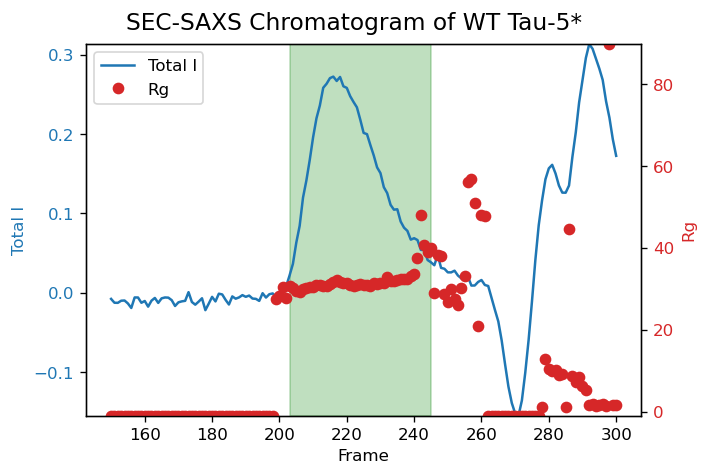

In [29]:
# Plot Total I and Rg with buffer and ROI highlighted, zoomed into the ROI
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)

# lightly translucent rectangle for buffer region (behind the plotted lines)
# ax1.axvspan(buffer_region_start, buffer_region_end, color='gray', alpha=0.25, zorder=0)

# lightly translucent rectangle for ROI (behind the plotted lines)
ax1.axvspan(roi_start, roi_end, color='green', alpha=0.25, zorder=0)


# boolean mask to slice arrays
mask = (frames >= start_frame) & (frames <= end_frame)

c1 = 'tab:blue'
ax1.plot(frames[mask], subtracted_total_i[mask], color=c1, label='Total I')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Total I', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)
# set y limits safely ignoring NaNs
try:
    ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
    if ymin == ymax:
        ymin -= 0.5; ymax += 0.5
    ax1.set_ylim(ymin, ymax)
except ValueError:
    pass

ax2 = ax1.twinx()
c2 = 'tab:red'
ax2.plot(frames[mask], rg[mask], color=c2, marker='o', linestyle='None', label='Rg')
ax2.set_ylabel('Rg', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)
try:
    ymin2, ymax2 = np.nanmin(rg[mask]), np.nanmax(rg[mask])
    if ymin2 == ymax2:
        ymin2 -= 0.5; ymax2 += 0.5
    ax2.set_ylim(ymin2, ymax2)
except ValueError:
    pass

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

fig.tight_layout(rect=[0, 0, 1, 0.95])            # leave top 8% for title
fig.suptitle(f"SEC-SAXS Chromatogram of WT Tau-5*", fontsize=14)
plt.show()

### Evaluate and Analyze All Profiles between 203-245

In [30]:
# Get the first sub-profile from the ROI
sub_profiles_roi[0]

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_18532/2613774222.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


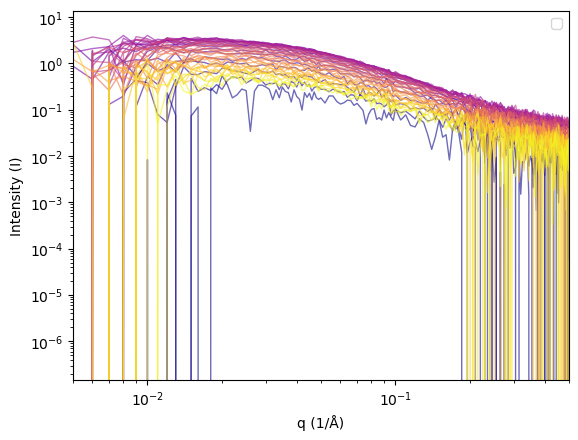

In [31]:
# Plot Sub-profiles
plt.figure()

n = len(sub_profiles_roi)
cmap = plt.cm.plasma  # yellow → purple

for i in range(len(sub_profiles_roi)):
    profile_n = sub_profiles_roi[i]

    q = profile_n.getQ()
    intensity = profile_n.getI()
    error = profile_n.getErr()

    # Normalize index to [0,1] for colormap
    color = cmap(i / (n - 1))

    # Plot individual curves
    plt.plot(q, intensity, color=color, alpha=0.6, linewidth=1)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')
plt.xlim(0.005, 0.5)
plt.legend()


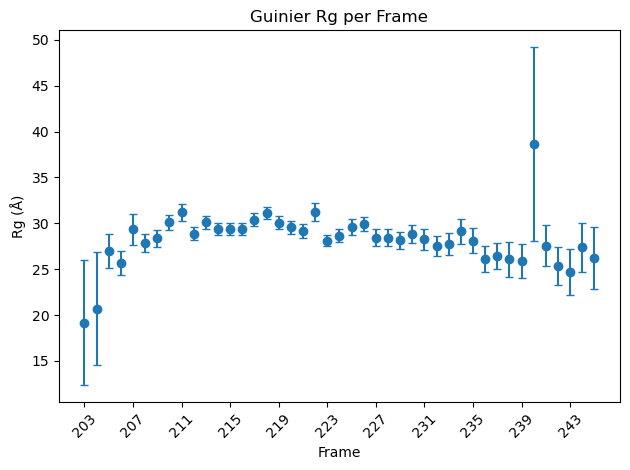

In [32]:
# Plot auto calculated Rg values for each profile in the ROI
# # efficient preallocated collection + nicer x-ticks
n = len(sub_profiles_roi)
rg_values = np.full(n, np.nan, dtype=float)
rg_errors = np.full(n, np.nan, dtype=float)

for j, profile in enumerate(sub_profiles_roi):
    try:
        rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max, r_sq = \
            raw.auto_guinier(profile, settings=my_settings)
        rg_values[j] = rg_j
        rg_errors[j] = rg_err_j
    except Exception as e:
        # keep NaN for failed fit, print brief info
        print(f"Guinier failed for ROI frame {j} (global frame {to_int_scalar(roi_start)+j}): {e}")

# map to real frame numbers
roi_start_val = to_int_scalar(roi_start)
frame_numbers = roi_start_val + np.arange(n)

fig, ax = plt.subplots()
rg_errors = np.abs(rg_errors)  # ensure non-negative errors for plotting
ax.errorbar(frame_numbers, rg_values, yerr=rg_errors, fmt='o', capsize=3)
ax.set_xlabel('Frame')
ax.set_ylabel('Rg (Å)')
ax.set_title('Guinier Rg per Frame')

# sensible x-ticks: show all for small ROI, subsample for larger
if n <= 20:
    ticks = frame_numbers
else:
    step = max(1, n // 10)
    ticks = frame_numbers[::step]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45)

fig.tight_layout()
plt.show()
# ...existing code...

[19.18515168 20.68452061 26.94142682 25.67398553 29.33582636 27.85141382
 28.37263607 30.11447714 31.1941895  28.86565437 30.10640727 29.41704066
 29.40083705 29.37131309 30.40344577 31.1168655  30.07462942 29.59200477
 29.15694576 31.22703332 28.10818009 28.66546258 29.60239665 29.9315405
 28.44806931 28.4533299  28.15130373 28.88254507 28.23869064 27.57135135
 27.74170967 29.11365518 28.09097614 26.12964201 26.44018988 26.07384137
 25.89497968 38.61397637 27.5623489  25.35994241 24.64386106 27.37912821
 26.210823  ]


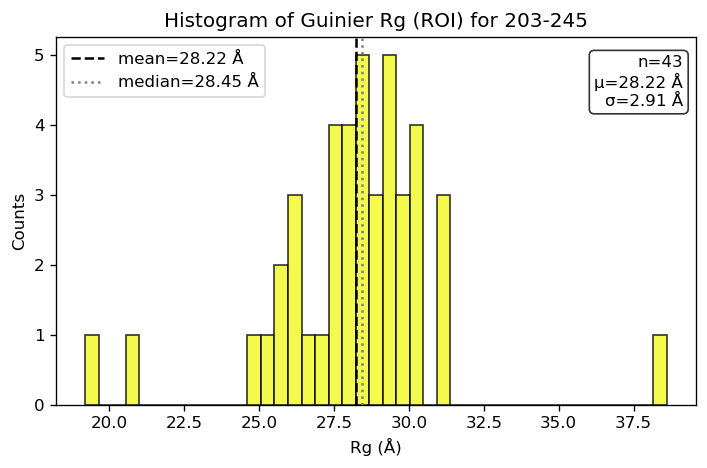

In [33]:
# Plot auto calculated Rg values for each profile in the ROI
# # efficient preallocated collection + nicer x-ticks
n = len(sub_profiles_roi)
rg_values = np.full(n, np.nan, dtype=float)
rg_errors = np.full(n, np.nan, dtype=float)

for j, profile in enumerate(sub_profiles_roi):
    try:
        rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max, r_sq = \
            raw.auto_guinier(profile, settings=my_settings)
        rg_values[j] = rg_j
        rg_errors[j] = rg_err_j
    except Exception as e:
        # keep NaN for failed fit, print brief info
        print(f"Guinier failed for ROI frame {j} (global frame {to_int_scalar(roi_start)+j}): {e}")

print(rg_values)

# Plot Rg values in histogram
fig.tight_layout()
plt.show()

# histogram of Rg values (ignore NaNs)
valid = ~np.isnan(rg_values)
if np.count_nonzero(valid) == 0:
    print("No valid Rg values to plot.")
else:
    vals = rg_values[valid]
    mean_rg = np.mean(vals)
    median_rg = np.median(vals)
    std_rg = np.std(vals, ddof=1)

    plt.figure(figsize=(6,4), dpi=120)
    plt.hist(vals, bins=n, color=color, alpha=0.8, edgecolor='k')
    plt.axvline(mean_rg, color='black', linestyle='--', label=f'mean={mean_rg:.2f} Å')
    plt.axvline(median_rg, color='gray', linestyle=':', label=f'median={median_rg:.2f} Å')
    plt.xlabel('Rg (Å)')
    plt.ylabel('Counts')
    plt.title(f"Histogram of Guinier Rg (ROI) for {roi_start}-{roi_end}")
    plt.legend(loc='best')
    plt.gca().text(0.98, 0.95, f'n={len(vals)}\nμ={mean_rg:.2f} Å\nσ={std_rg:.2f} Å',
                   transform=plt.gca().transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()
# ...existing code...

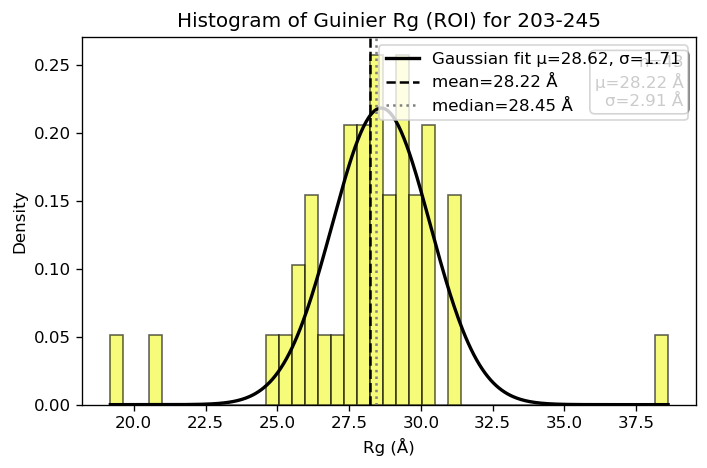

In [34]:
# Plot auto calculated Rg values for each profile in the ROI
# # efficient preallocated collection + nicer x-ticks
n = len(sub_profiles_roi)
rg_values = np.full(n, np.nan, dtype=float)
rg_errors = np.full(n, np.nan, dtype=float)

for j, profile in enumerate(sub_profiles_roi):
    try:
        rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max, r_sq = \
            raw.auto_guinier(profile, settings=my_settings)
        rg_values[j] = rg_j
        rg_errors[j] = rg_err_j
    except Exception as e:
        # keep NaN for failed fit, print brief info
        print(f"Guinier failed for ROI frame {j} (global frame {to_int_scalar(roi_start)+j}): {e}")

# Plot Rg values in histogram
fig.tight_layout()
plt.show()

# histogram of Rg values (ignore NaNs)
valid = ~np.isnan(rg_values)
if np.count_nonzero(valid) == 0:
    print("No valid Rg values to plot.")
else:
    vals = rg_values[valid]
    mean_rg = np.mean(vals)
    median_rg = np.median(vals)
    std_rg = np.std(vals, ddof=1)

    # control bin count here
    nbins = n

    plt.figure(figsize=(6,4), dpi=120)
    # plot density histogram so fitted PDF overlays correctly
    counts, bins, patches = plt.hist(vals, bins=nbins, density=True,
                                     color=color, alpha=0.6, edgecolor='k')

    # bin centers for fitting / diagnostics
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Try to fit a Gaussian with scipy.optimize.curve_fit
    try:
        from scipy.optimize import curve_fit

        def gauss(x, A, mu, sigma):
            return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

        p0 = [1.0, mean_rg, std_rg]
        popt, pcov = curve_fit(gauss, bin_centers, counts, p0=p0)
        x = np.linspace(bins[0], bins[-1], 400)
        plt.plot(x, gauss(x, *popt), color='black', lw=2,
                 label=f'Gaussian fit μ={popt[1]:.2f}, σ={popt[2]:.2f}')
    except Exception:
        # fallback to KDE if curve_fit / scipy not available
        try:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(vals)
            x = np.linspace(bins[0], bins[-1], 400)
            plt.plot(x, kde(x), color='black', lw=2, label='KDE')
        except Exception:
            # final fallback: plot normal pdf using sample mean/std
            x = np.linspace(bins[0], bins[-1], 400)
            pdf = (1 / (std_rg * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_rg) / std_rg) ** 2)
            plt.plot(x, pdf, color='black', lw=2, label=f'Normal μ={mean_rg:.2f}, σ={std_rg:.2f}')

    # annotate vertical lines and text
    plt.axvline(mean_rg, color='black', linestyle='--', label=f'mean={mean_rg:.2f} Å')
    plt.axvline(median_rg, color='gray', linestyle=':', label=f'median={median_rg:.2f} Å')

    plt.xlabel('Rg (Å)')
    plt.ylabel('Density')
    plt.title(f"Histogram of Guinier Rg (ROI) for {roi_start}-{roi_end}")
    plt.legend(loc='best')
    plt.gca().text(0.98, 0.95, f'n={len(vals)}\nμ={mean_rg:.2f} Å\nσ={std_rg:.2f} Å',
                   transform=plt.gca().transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()

In [191]:
# # IF YOU WANT TO SAVE THE PROFILES IN THE ROI TO INDIVIDUAL .DAT FILES, UNCOMMENT THE FOLLOWING CODE BLOCK AND SET THE OUTPUT DIRECTORY
# # save profiles in the ROI to individual .dat files
# output_dir = './dat_files/'

# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# for i, profile in enumerate(sub_profiles_roi):
#     raw.save_profile(profile, os.path.join(output_dir, f'profile_{roi_start + i}.dat'))


### Moving window of subprofiles

Center frame for step-wise analysis: 225 for 207:243
Processing window j=1: frames 224 to 226


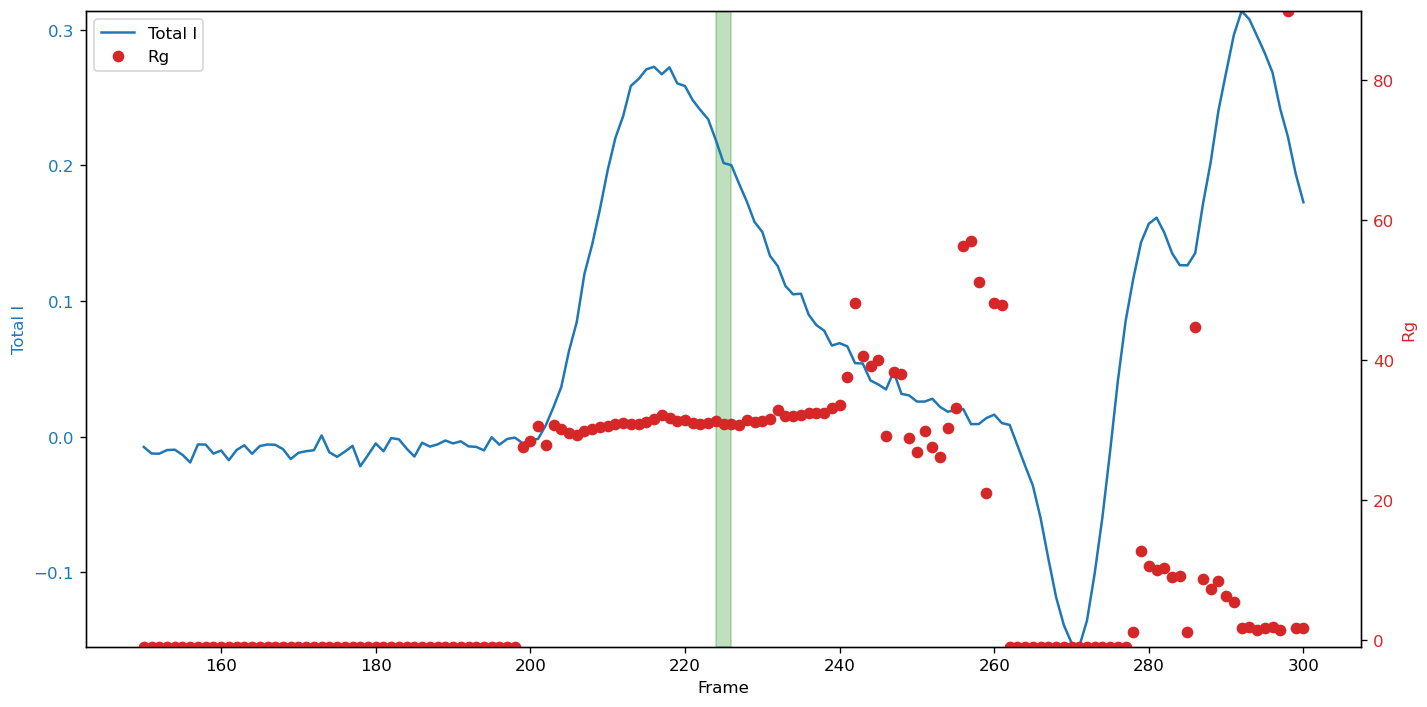

Processing window j=2: frames 223 to 227


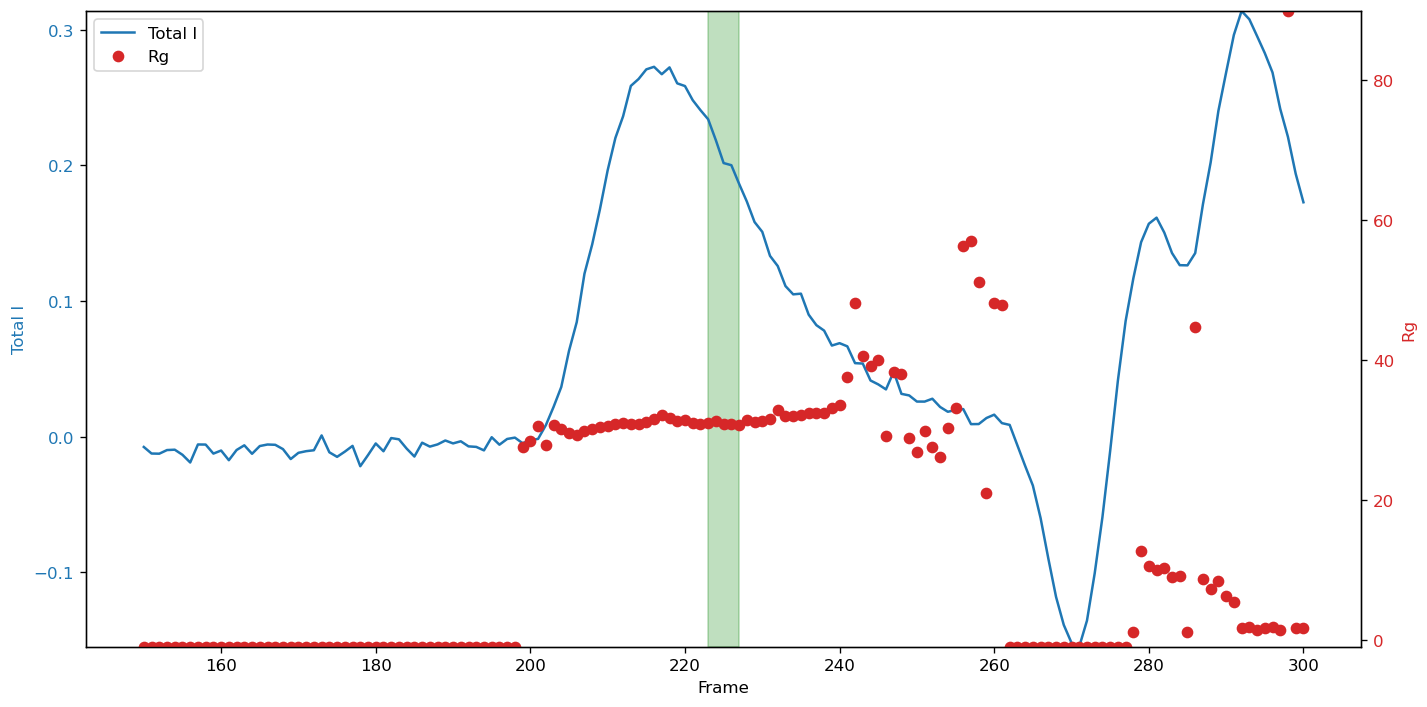

Processing window j=3: frames 222 to 228


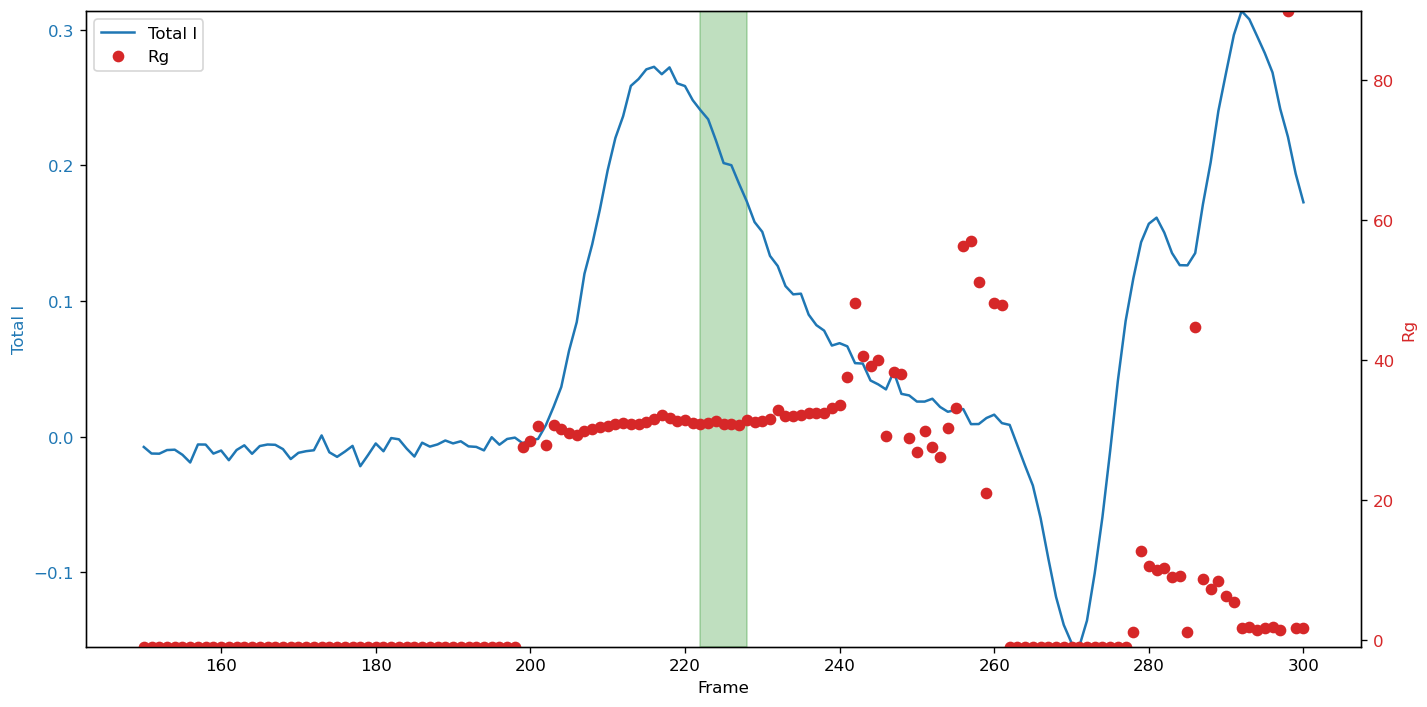

Processing window j=4: frames 221 to 229


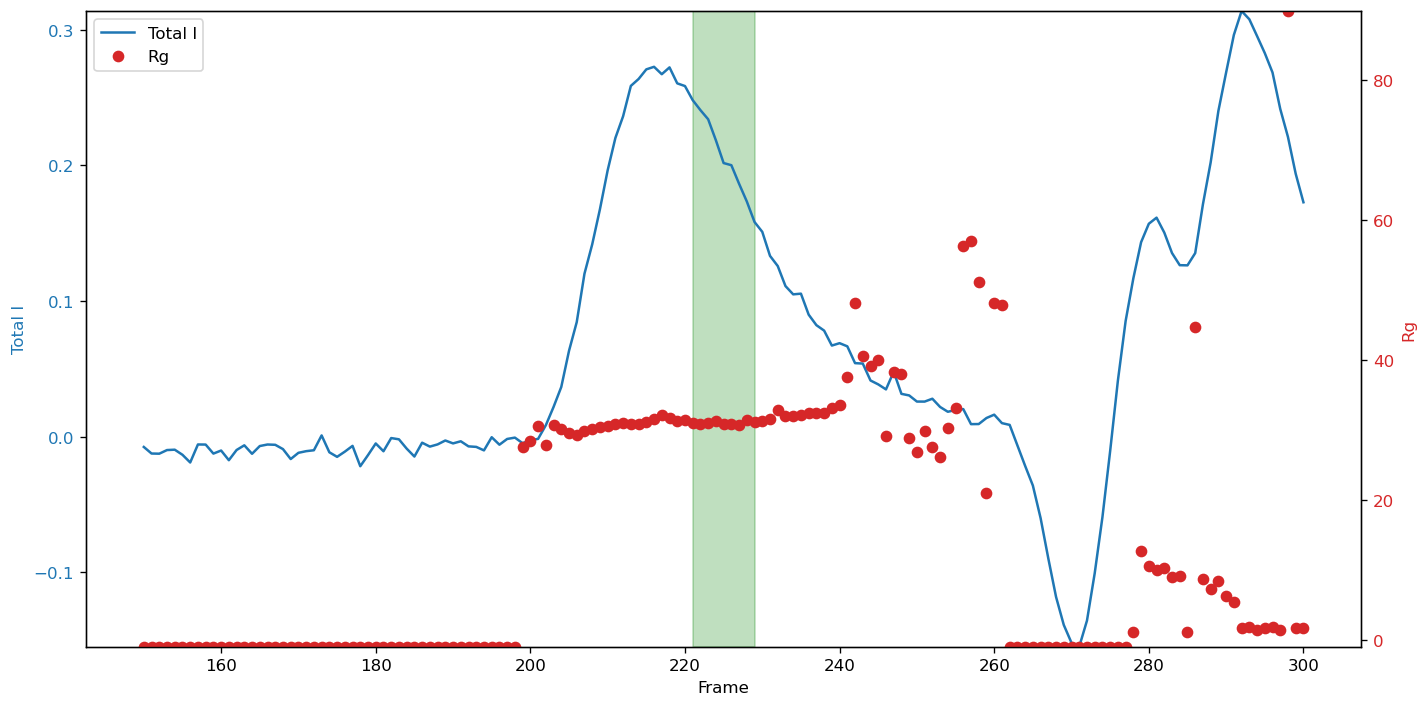

Processing window j=5: frames 220 to 230


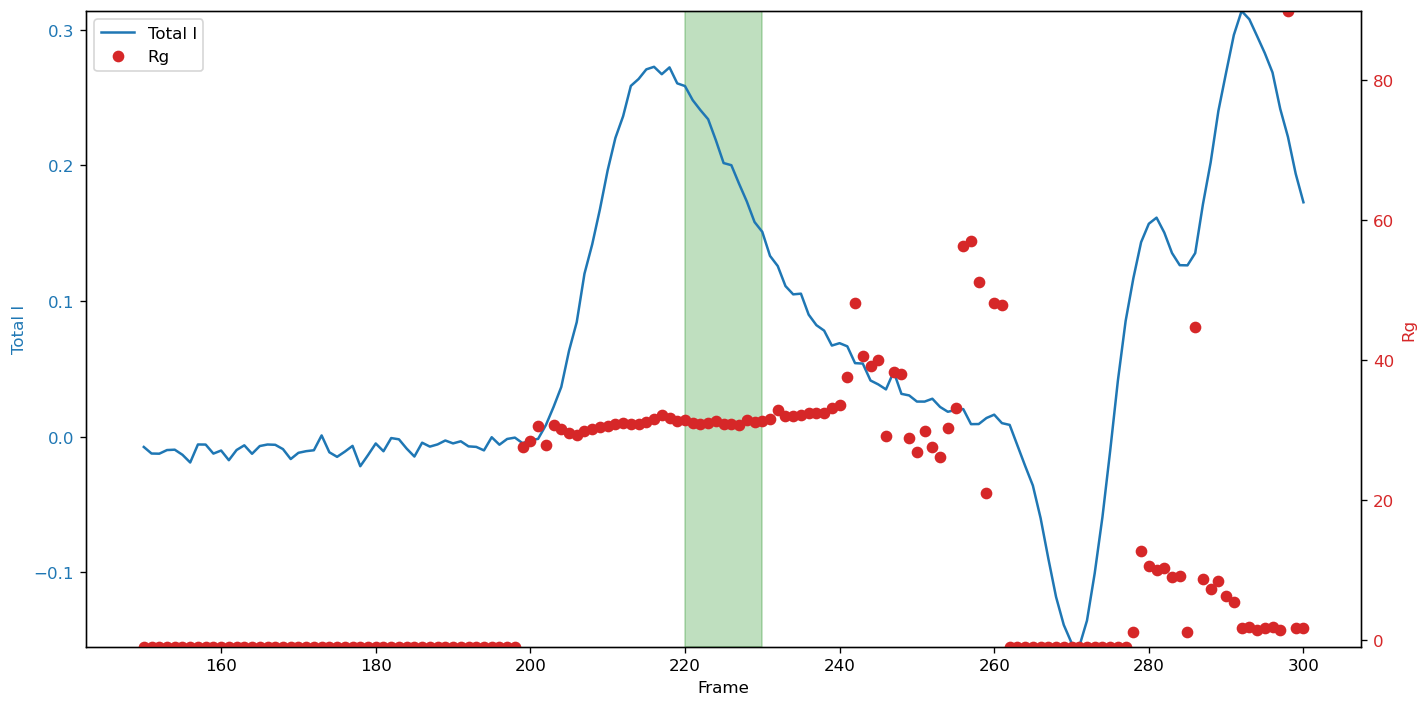

Processing window j=6: frames 219 to 231


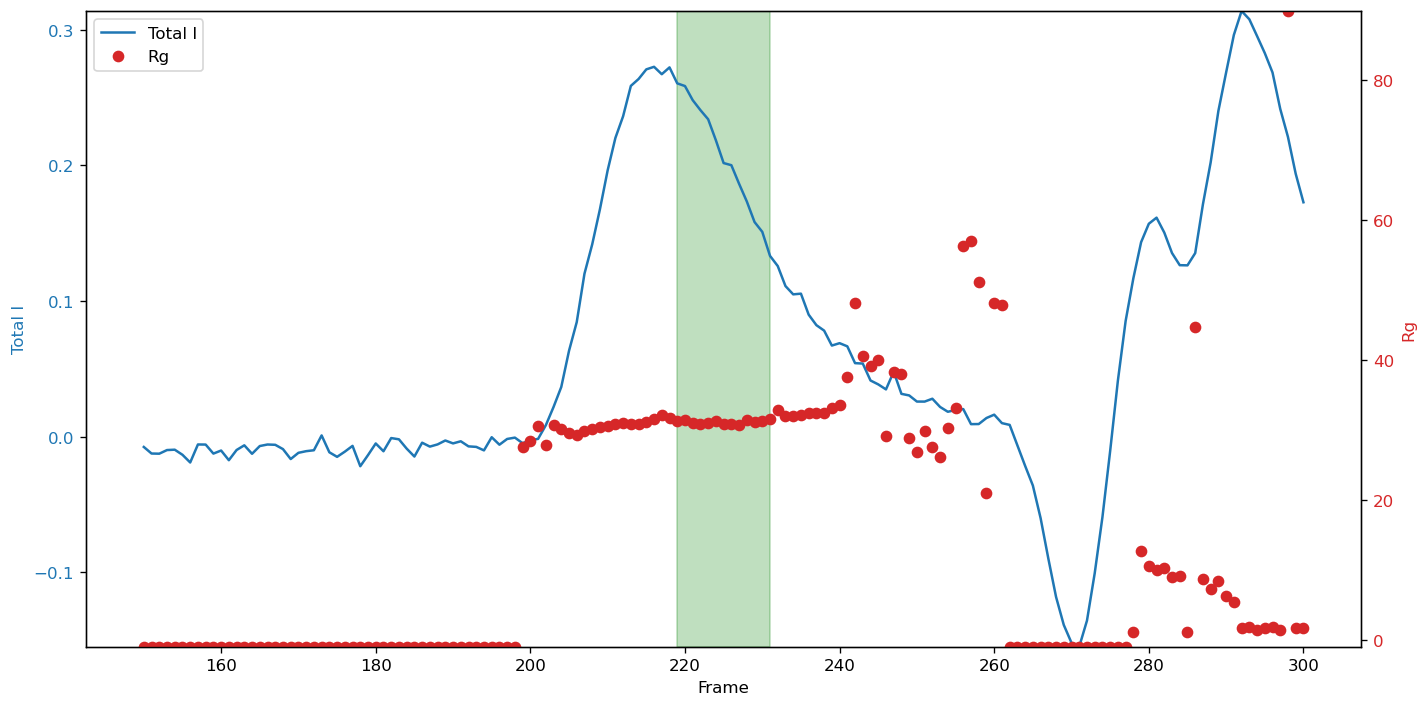

Processing window j=7: frames 218 to 232


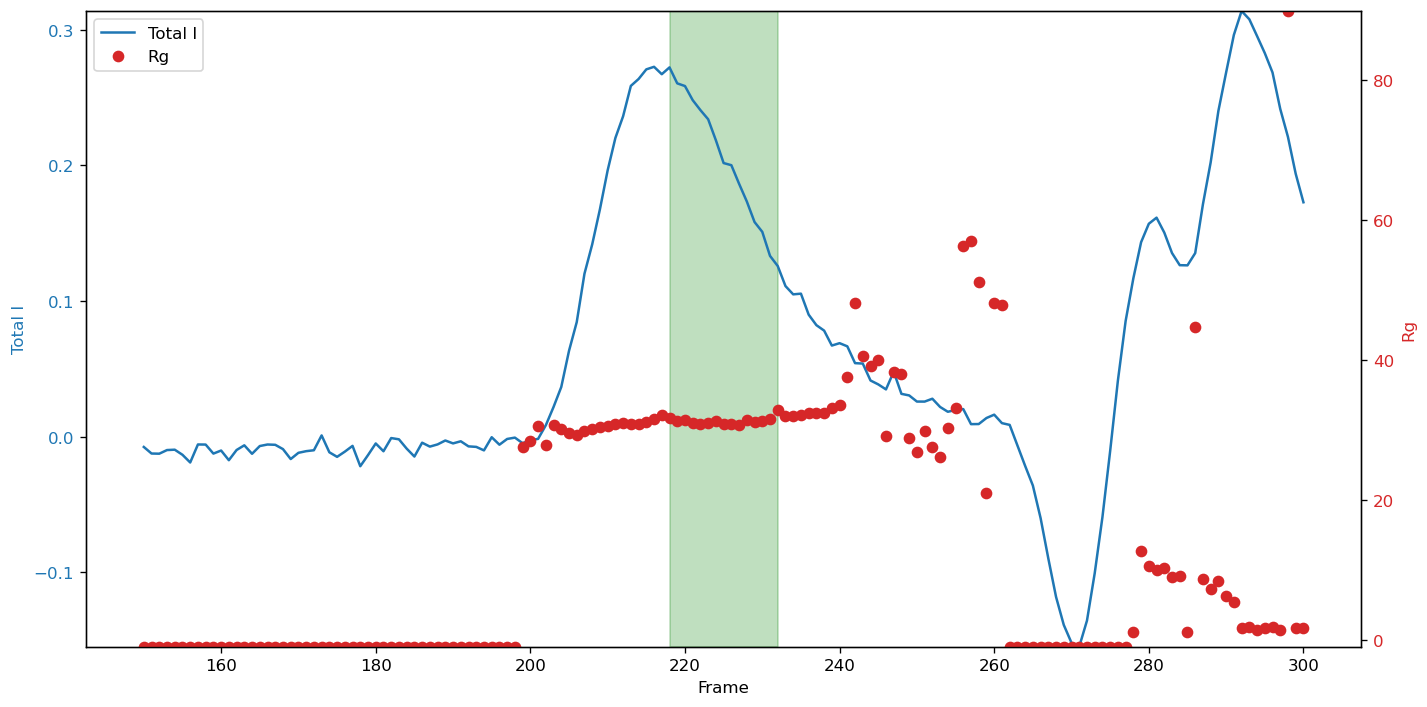

Processing window j=8: frames 217 to 233


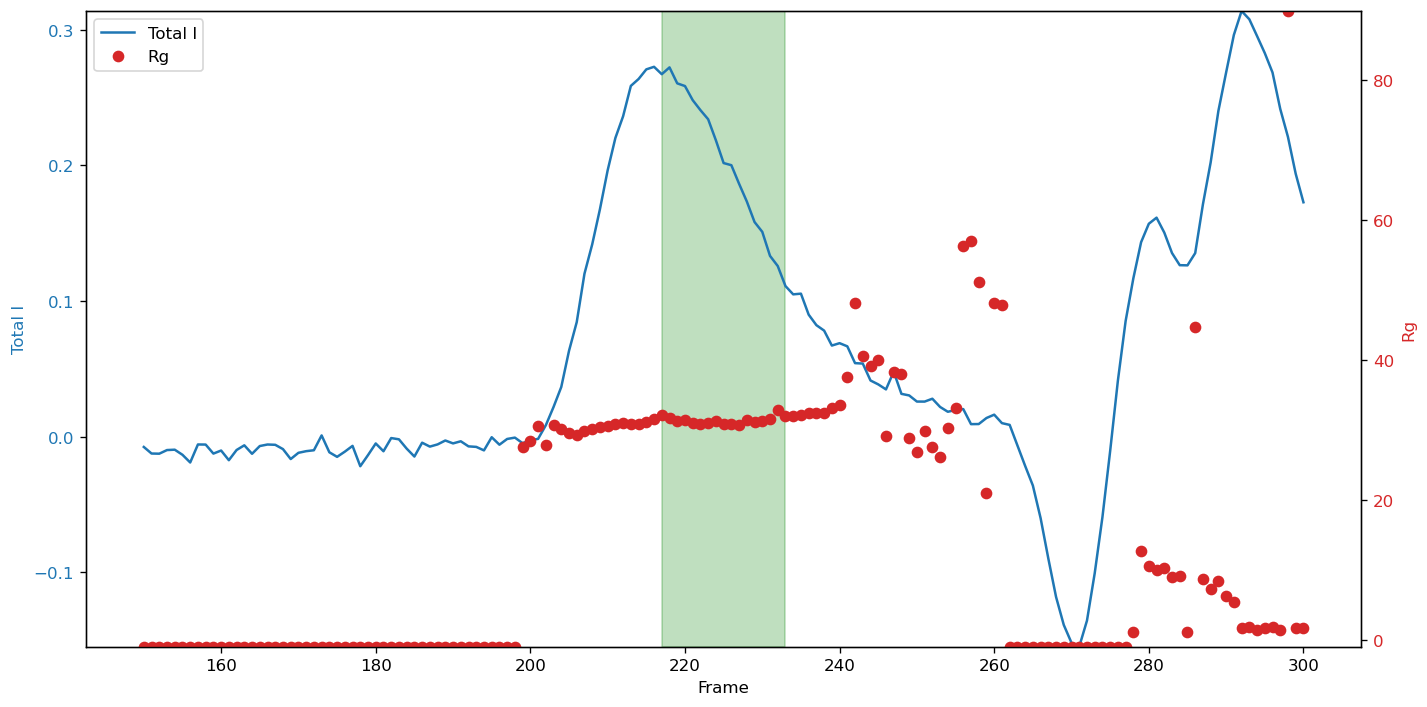

Processing window j=9: frames 216 to 234


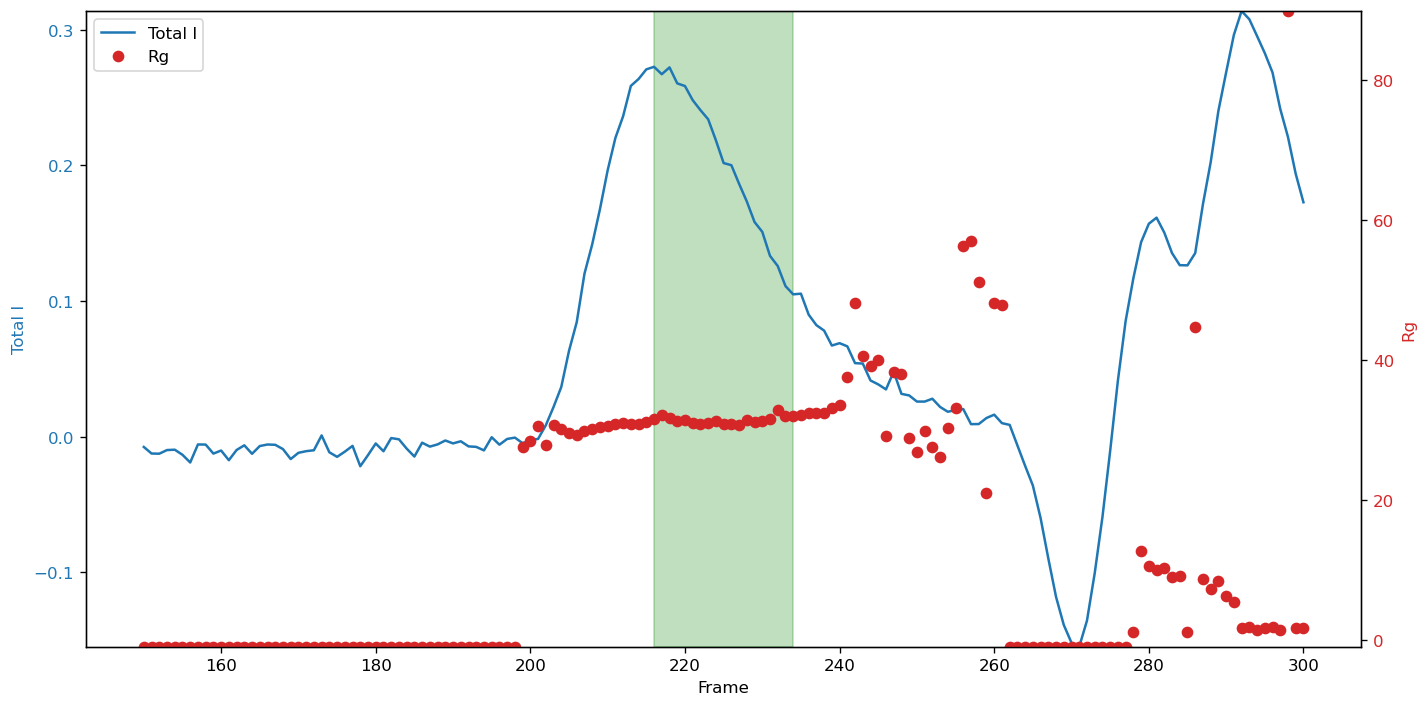

Processing window j=10: frames 215 to 235


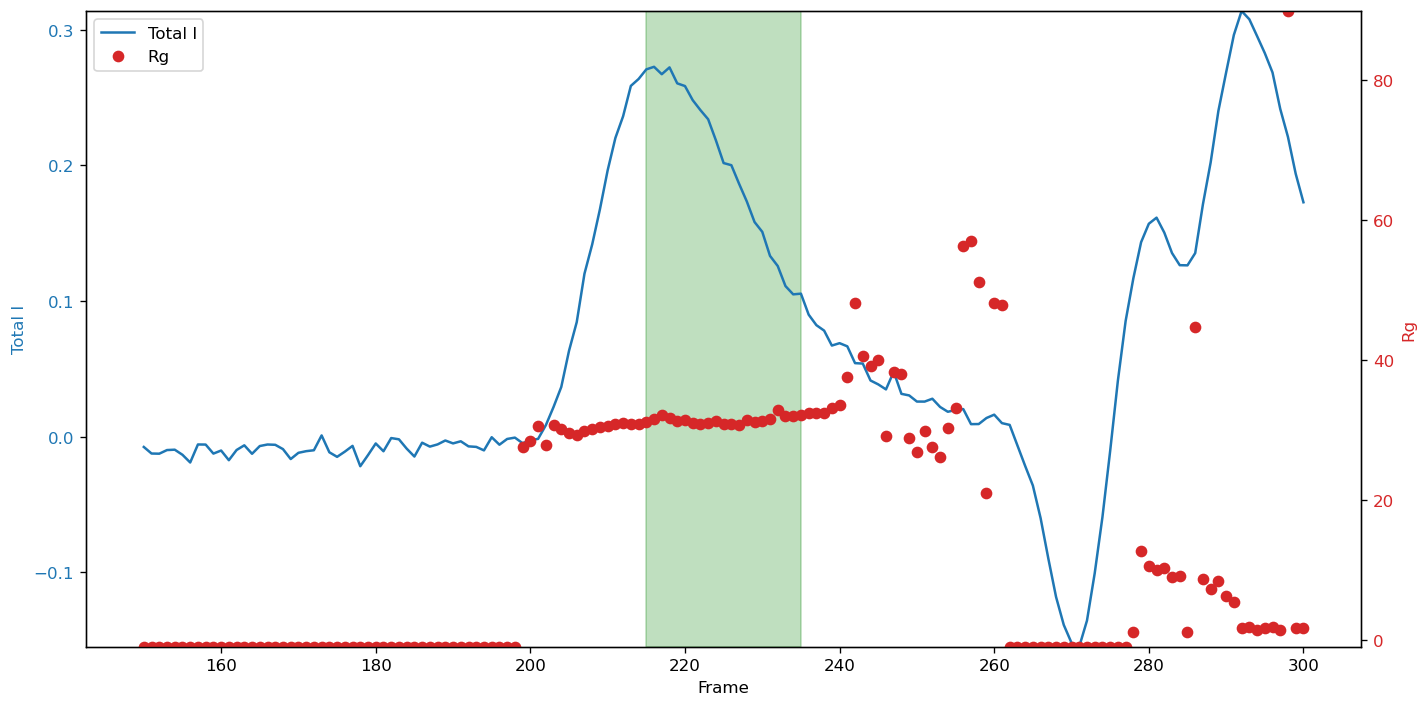

Processing window j=11: frames 214 to 236


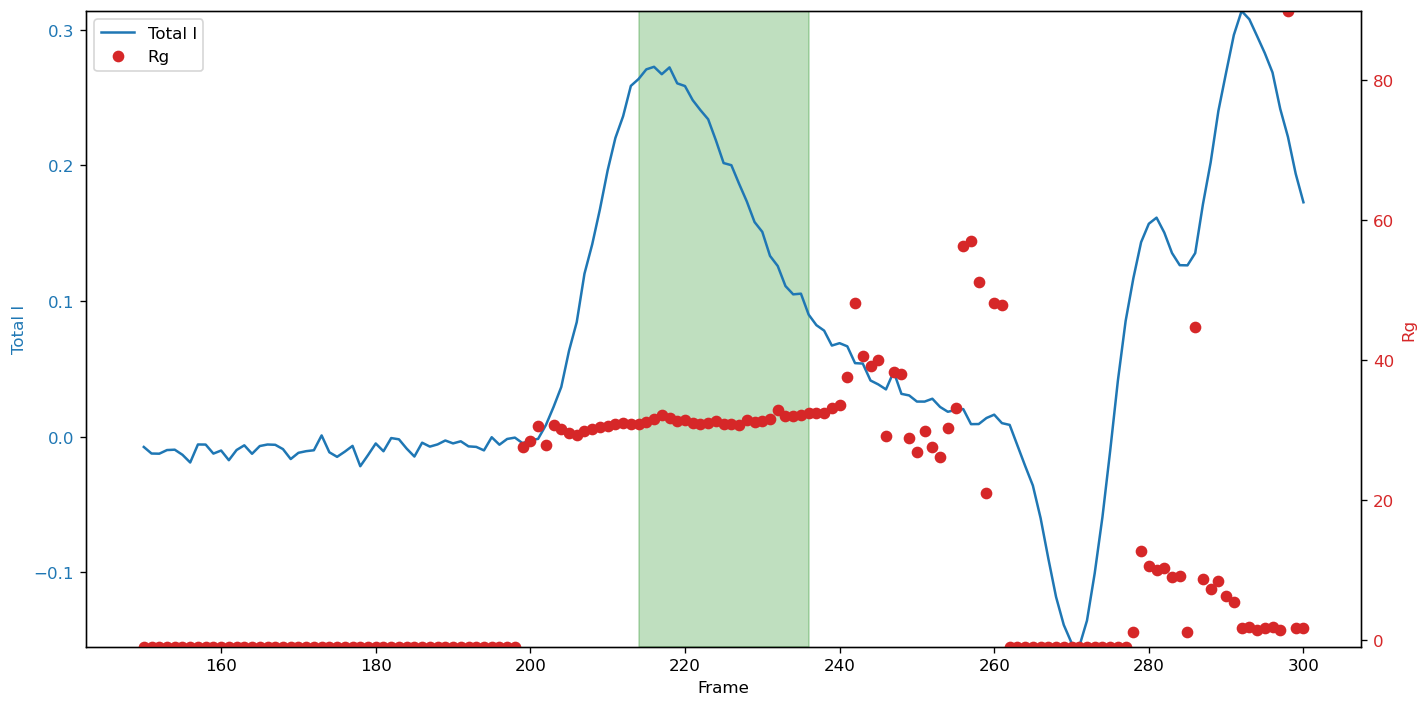

Processing window j=12: frames 213 to 237


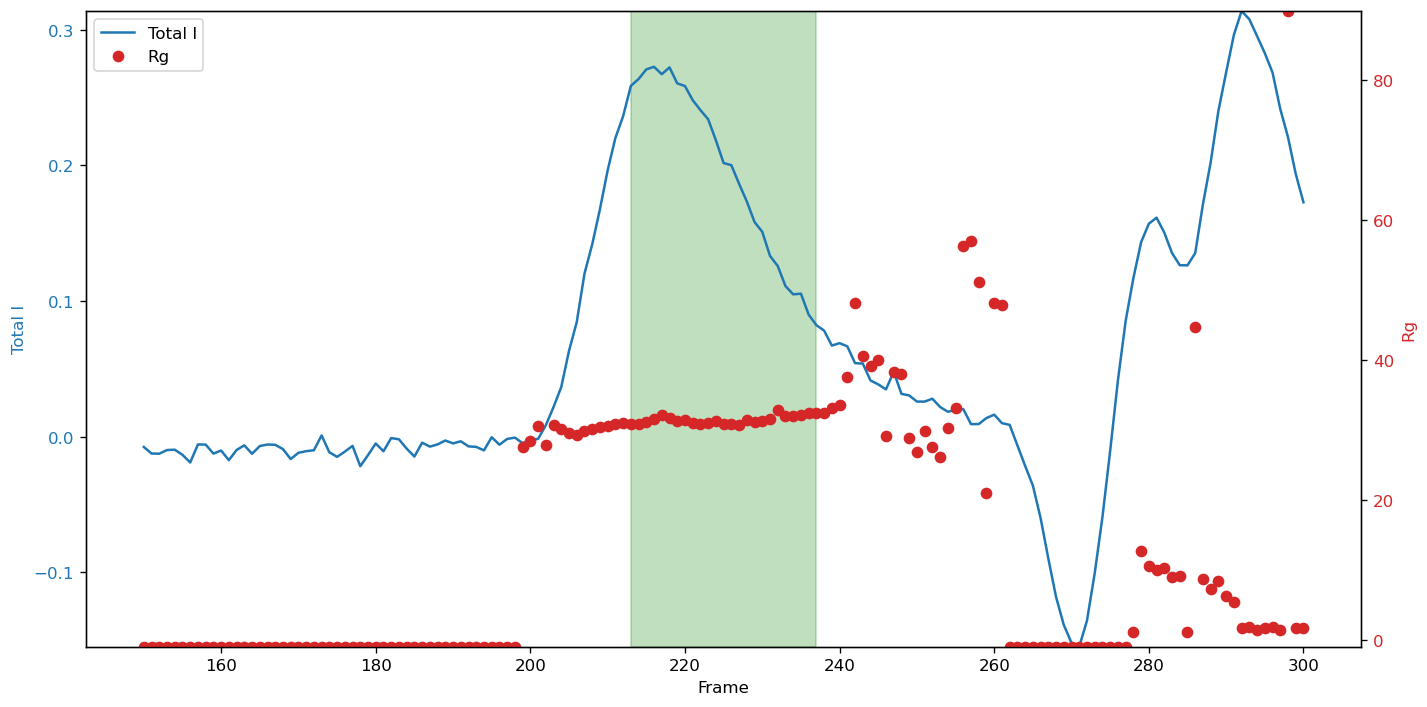

Processing window j=13: frames 212 to 238


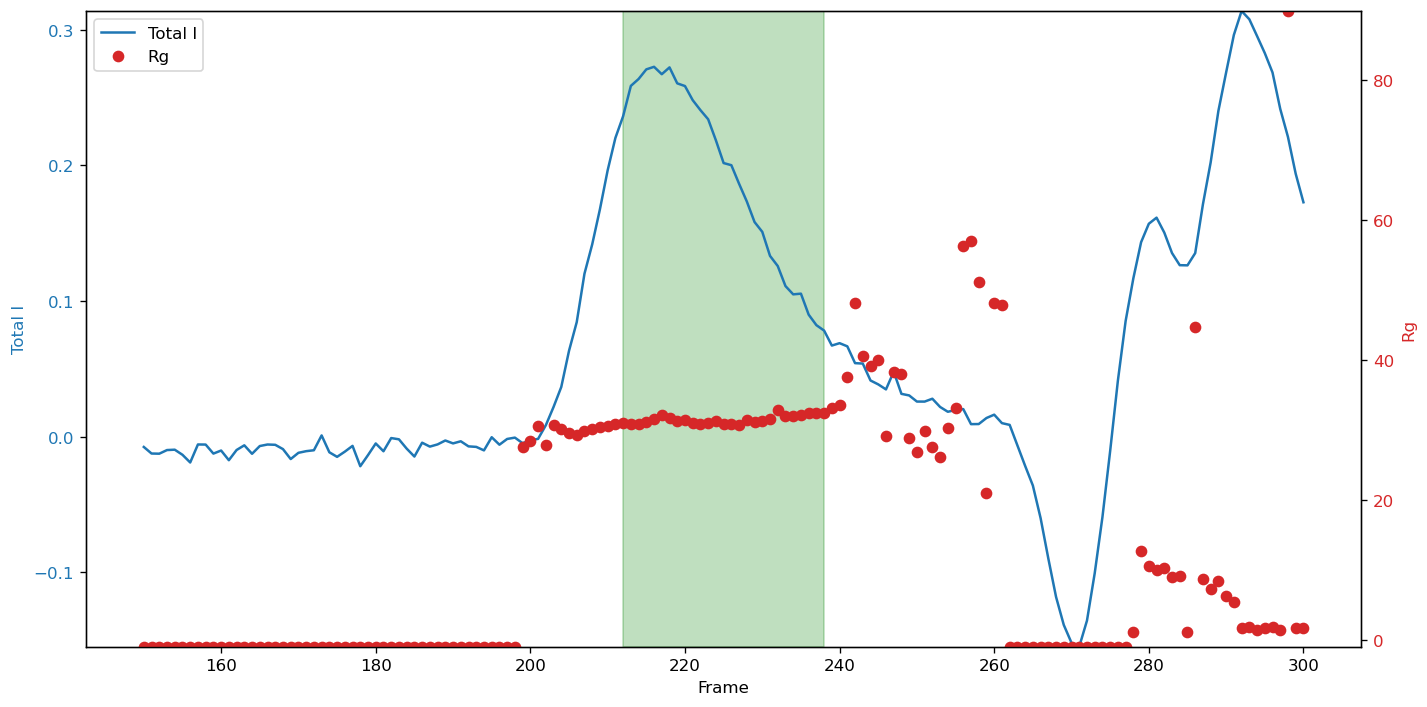

Processing window j=14: frames 211 to 239


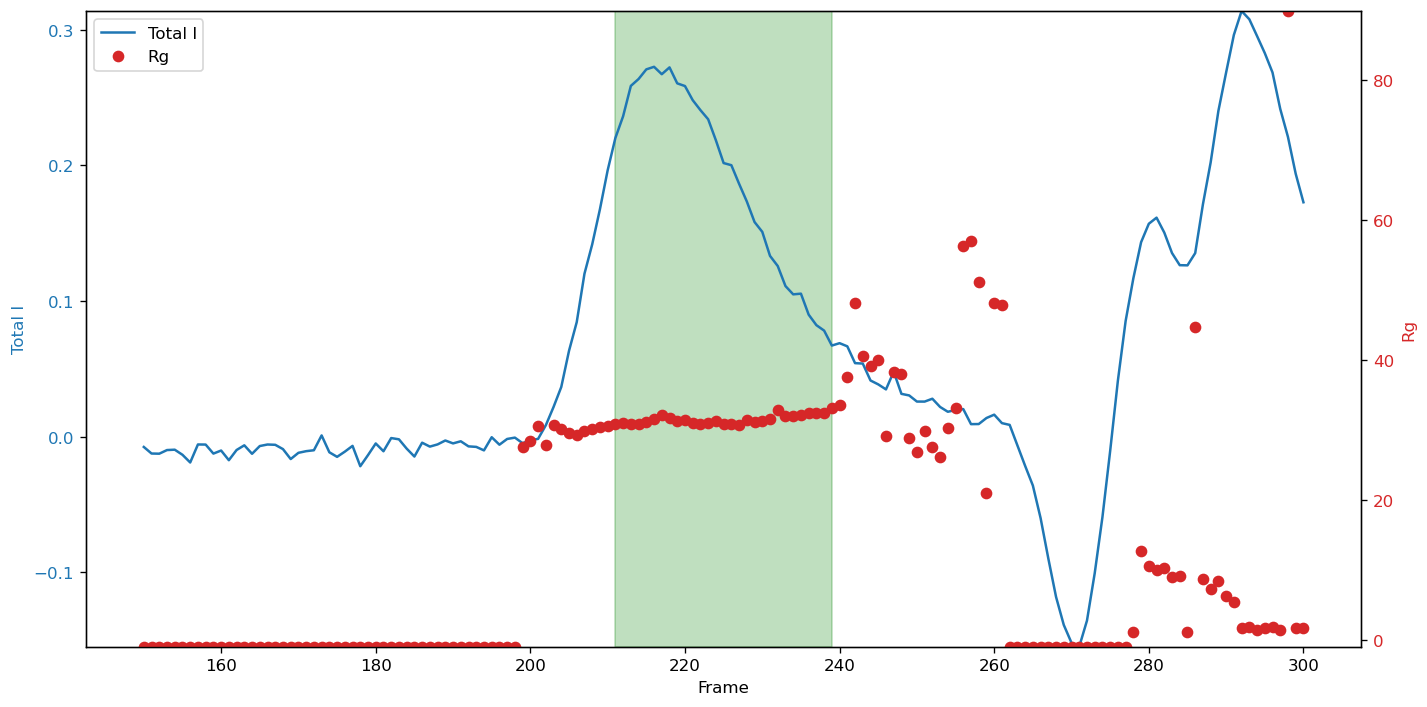

Processing window j=15: frames 210 to 240


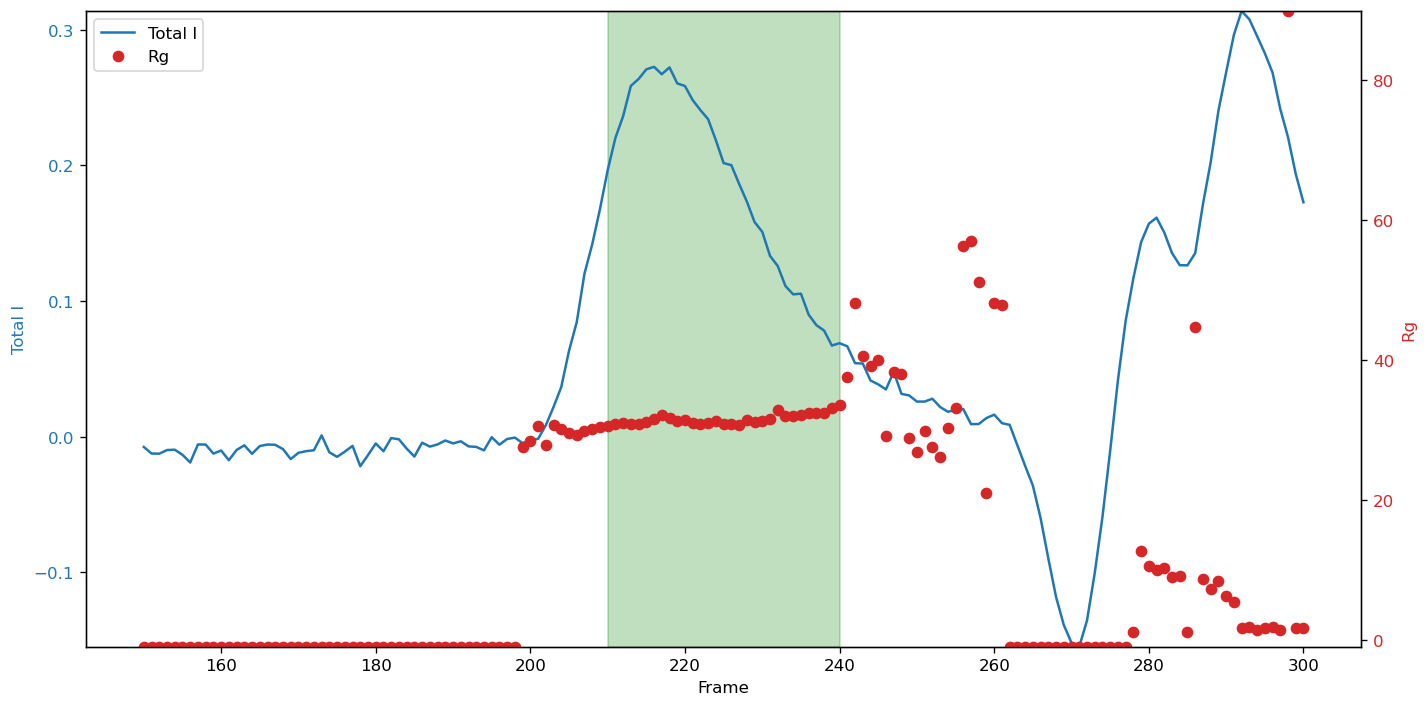

Processing window j=16: frames 209 to 241


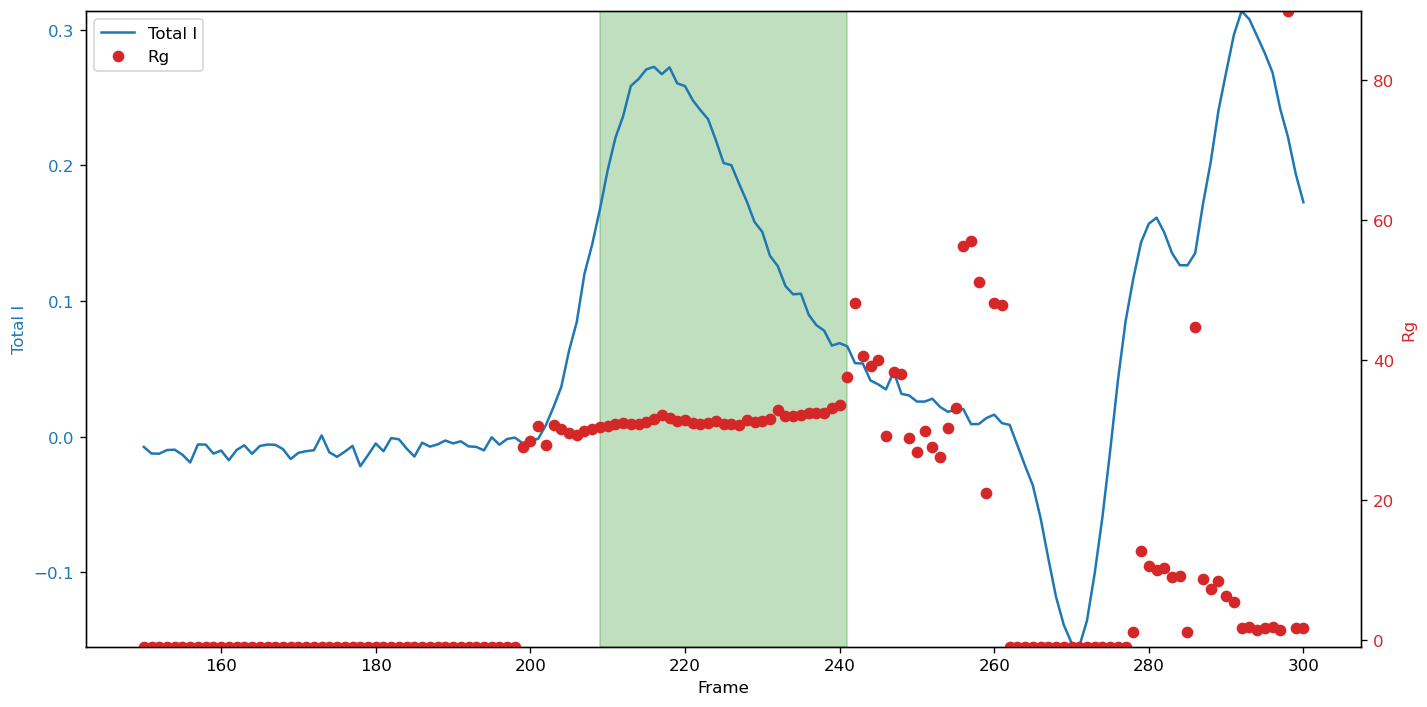

Processing window j=17: frames 208 to 242


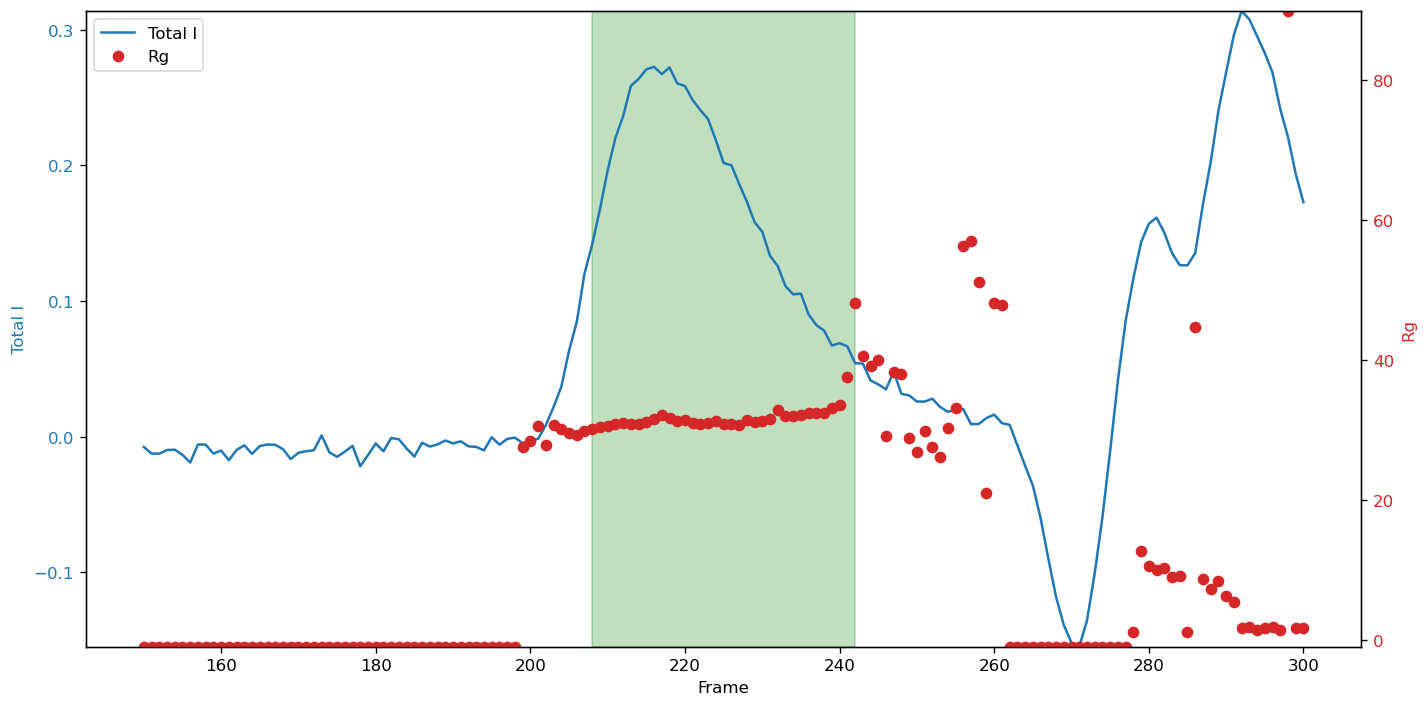

Processing window j=18: frames 207 to 243


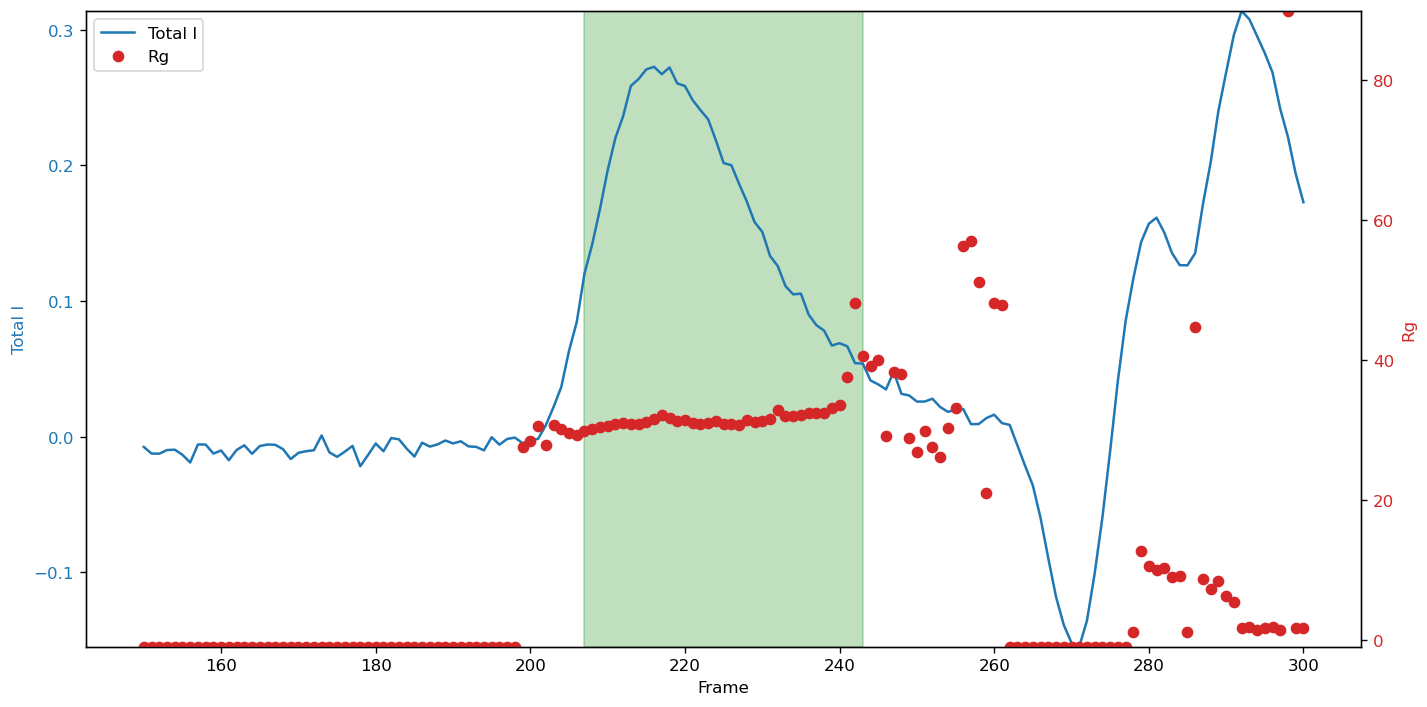

steps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
rg_values: [31.0746804  30.84253445 30.91912704 30.79750492 30.9404773  31.1758511
 31.26487588 31.30796305 31.35877356 31.43241655 31.39205345 31.37420554
 31.33160517 31.38034114 31.44703366 31.43384122 31.38912496 31.34426948]
rg_errors: [0.47443864 0.37162516 0.33912544 0.29762895 0.2684207  0.26471509
 0.24611144 0.23242175 0.22076502 0.21106952 0.20405359 0.19806535
 0.19332652 0.18910332 0.1857083  0.1837489  0.18273733 0.18275906]


In [37]:
# Set center frame for step-wise analysis
centerframe=int(start_frame + (end_frame - start_frame) / 2)
print(f"Center frame for step-wise analysis: {centerframe} for {roi_start}:{roi_end}")

# step-wise j values: 1,3,5,...,13
steps = list(range(1, 19, 1))
m = len(steps)

rg_values = np.full(m, np.nan, dtype=float)
rg_errors = np.full(m, np.nan, dtype=float)
x_labels = []

for k, j in enumerate(steps):
    roi_start = int(centerframe - j)
    roi_end = int(centerframe + j)  # +1 to include centerframe+j in the slice
    print(f"Processing window j={j}: frames {roi_start} to {roi_end}")
    x_labels.append(f"{roi_start}:{roi_end}")

    sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'sub')
    # Plot Total I and Rg with buffer and ROI highlighted, zoomed into the ROI
    fig, ax1 = plt.subplots(figsize=(12, 6), dpi=120)

    # lightly translucent rectangle for ROI (behind the plotted lines)
    ax1.axvspan(roi_start, roi_end, color='green', alpha=0.25, zorder=0)



    # boolean mask to slice arrays
    mask = (frames >= start_frame) & (frames <= end_frame)

    c1 = 'tab:blue'
    ax1.plot(frames[mask], subtracted_total_i[mask], color=c1, label='Total I')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Total I', color=c1)
    ax1.tick_params(axis='y', labelcolor=c1)
    # set y limits safely ignoring NaNs
    try:
        ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
        if ymin == ymax:
            ymin -= 0.5; ymax += 0.5
        ax1.set_ylim(ymin, ymax)
    except ValueError:
        pass

    ax2 = ax1.twinx()
    c2 = 'tab:red'
    ax2.plot(frames[mask], rg[mask], color=c2, marker='o', linestyle='None', label='Rg')
    ax2.set_ylabel('Rg', color=c2)
    ax2.tick_params(axis='y', labelcolor=c2)
    try:
        ymin2, ymax2 = np.nanmin(rg[mask]), np.nanmax(rg[mask])
        if ymin2 == ymax2:
            ymin2 -= 0.5; ymax2 += 0.5
        ax2.set_ylim(ymin2, ymax2)
    except ValueError:
        pass

    # combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

    fig.tight_layout()
    plt.show()
    average_profile = raw.average(sub_profiles_roi)
    try:
        (rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max,
         idx_min, idx_max, r_sq) = raw.auto_guinier(average_profile, settings=my_settings)
        rg_values[k] = rg_j
        rg_errors[k] = rg_err_j
    except Exception as e:
        print(f"Error processing window j={j} (slice {roi_start}:{end}): {e}")

print("steps:", steps)
print("rg_values:", rg_values)
print("rg_errors:", rg_errors)
# ...existing code...

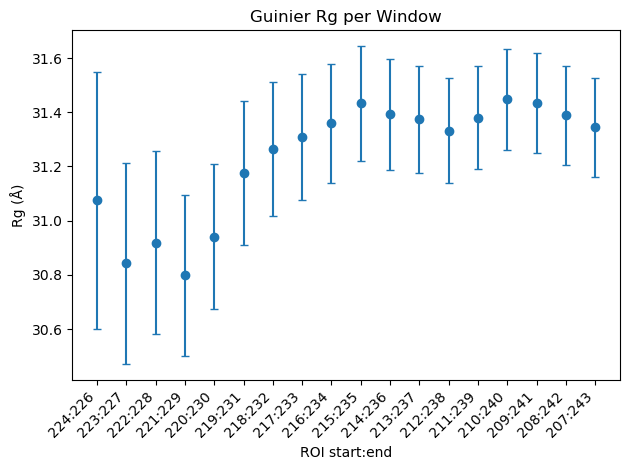

In [38]:
# make numeric x positions and use x_labels for tick labels
x = np.arange(len(x_labels))                     # numeric positions 0..N-1
fig, ax = plt.subplots()
ax.errorbar(x, rg_values, yerr=rg_errors, fmt='o', capsize=3)
ax.set_xlabel('ROI start:end')
ax.set_ylabel('Rg (Å)')
ax.set_title('Guinier Rg per Window')

m = len(x_labels)
# choose which tick positions to show (all for small m, subsample for large)
if m <= 20:
    ticks = x
else:
    step = max(1, m // 10)
    ticks = x[::step]

ax.set_xticks(ticks)
ax.set_xticklabels([x_labels[i] for i in ticks], rotation=45, ha='right')

fig.tight_layout()
plt.show()

In [45]:
# Define a LARGE region of interest (ROI) for analysis with centerframe and step range
range_int =int(30)
centerframe_int= int(roi_start)
print(f"Center frame for step-wise analysis: {centerframe_int} for {roi_start}:{roi_end}")
step_range_int = int(20)

rg_lower_limit = int(15)
rg_upper_limit = int(40)

Center frame for step-wise analysis: 203 for 203:245


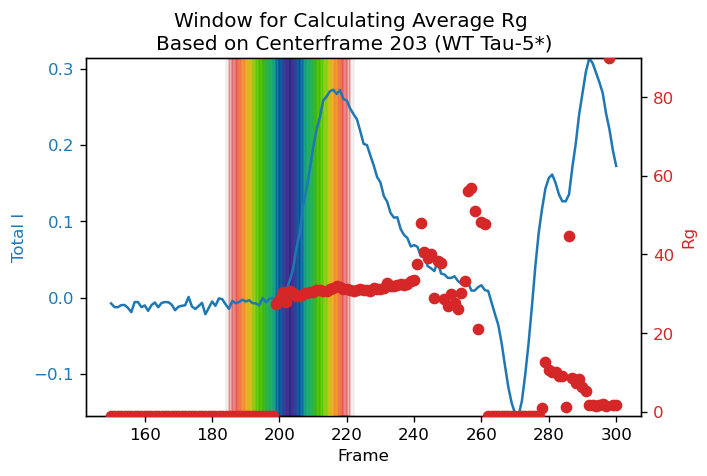

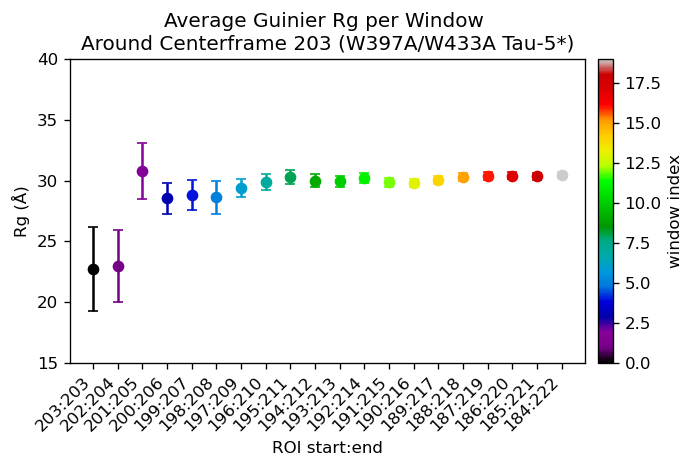

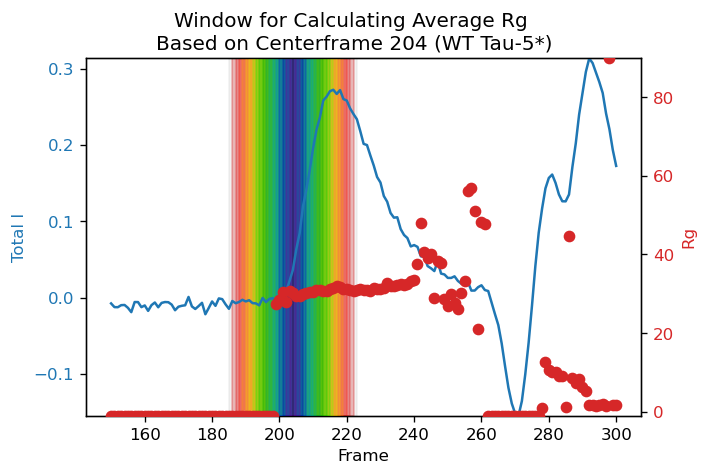

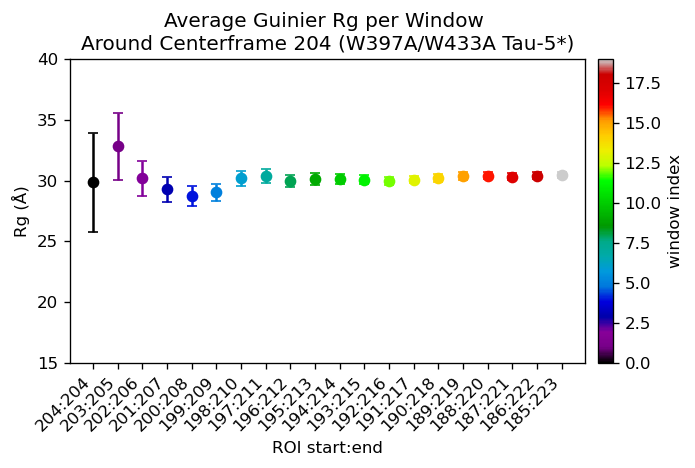

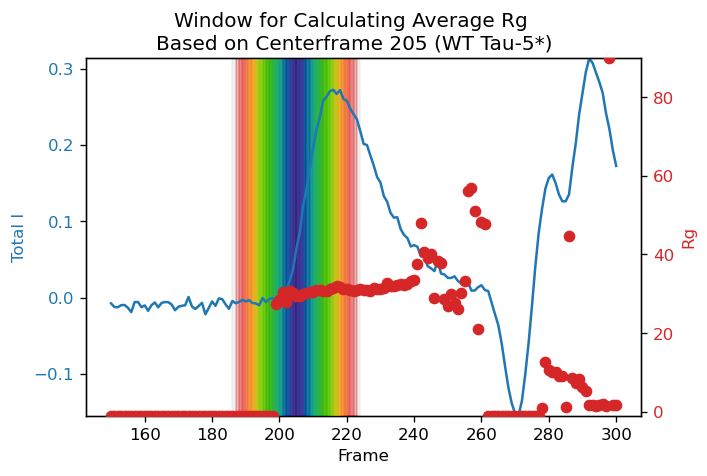

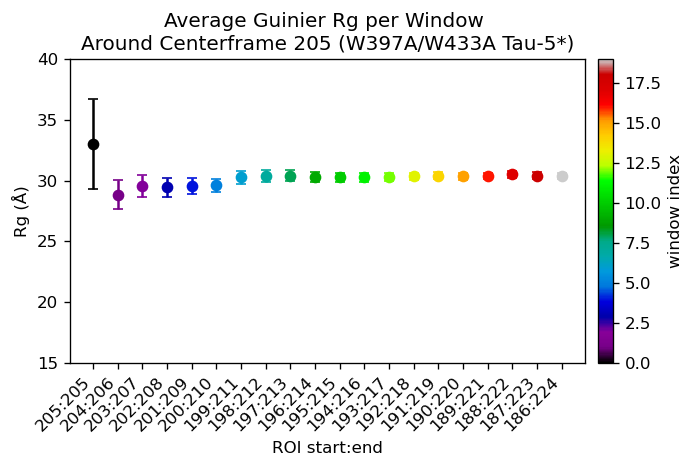

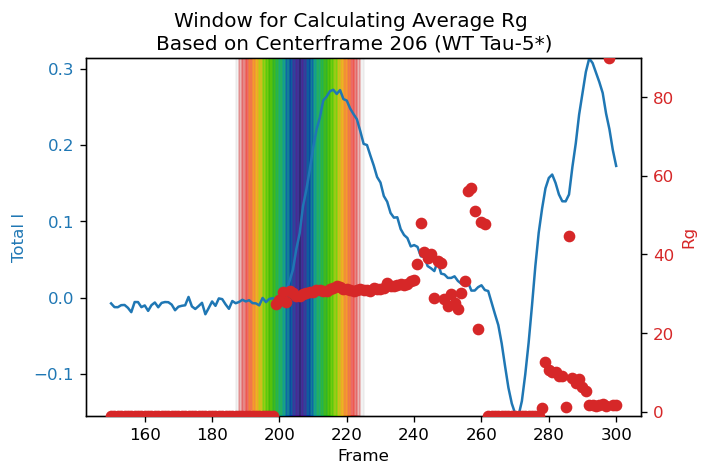

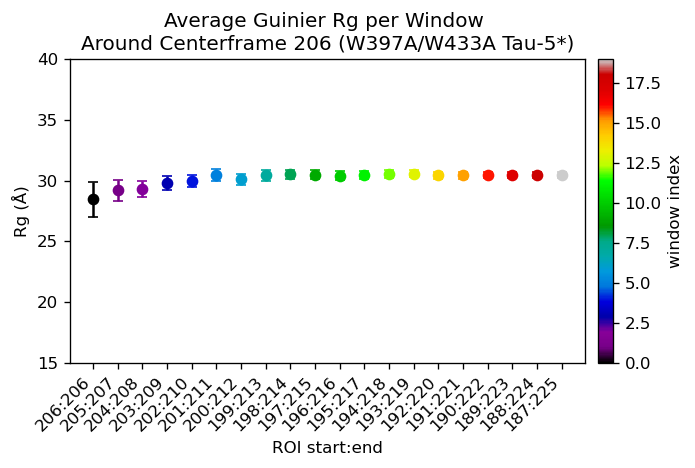

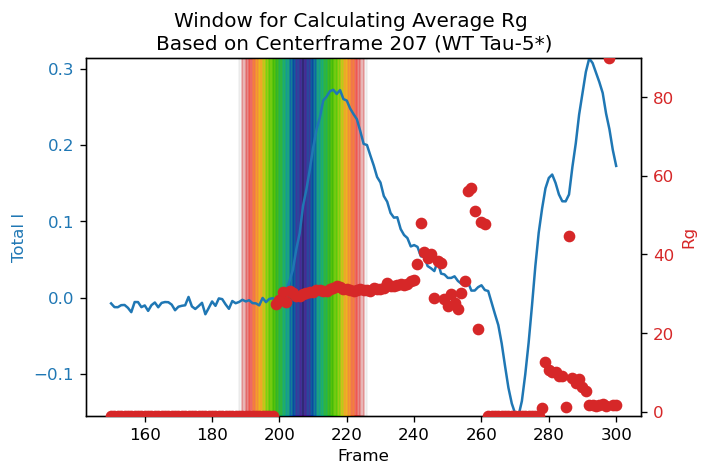

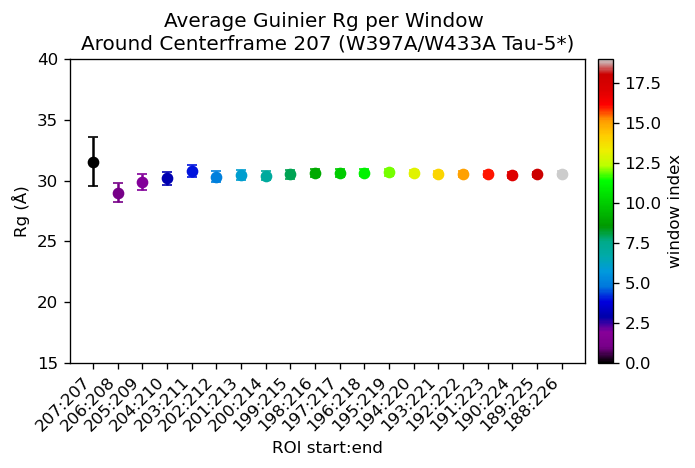

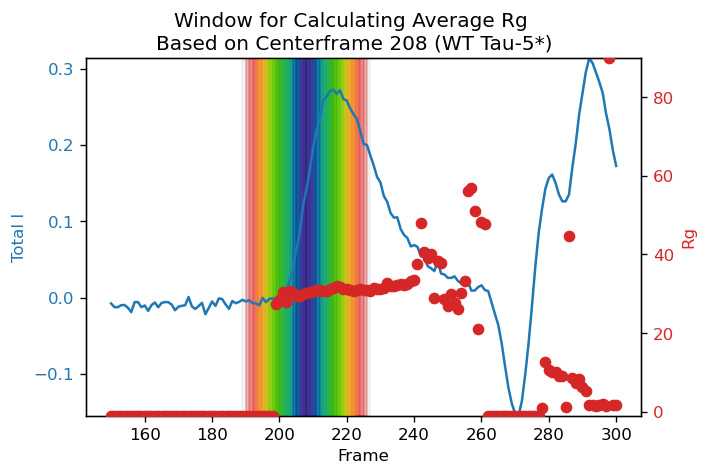

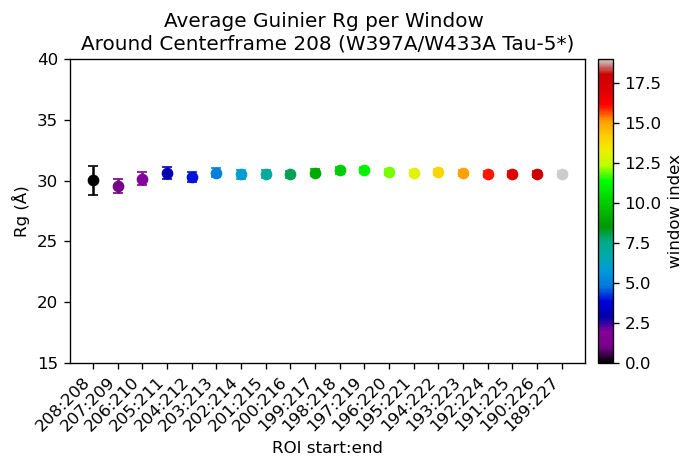

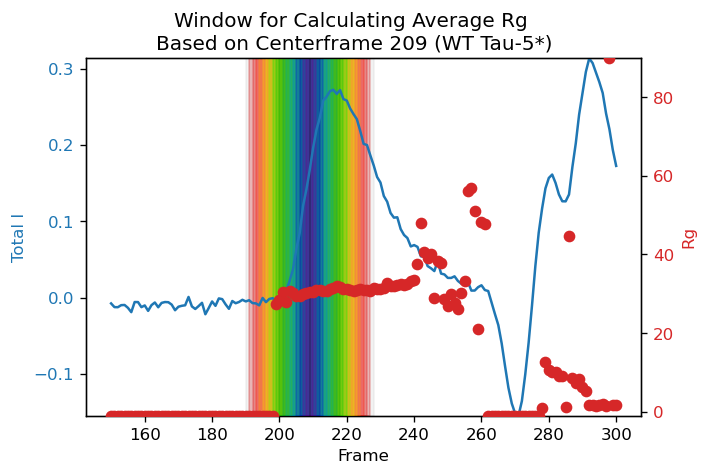

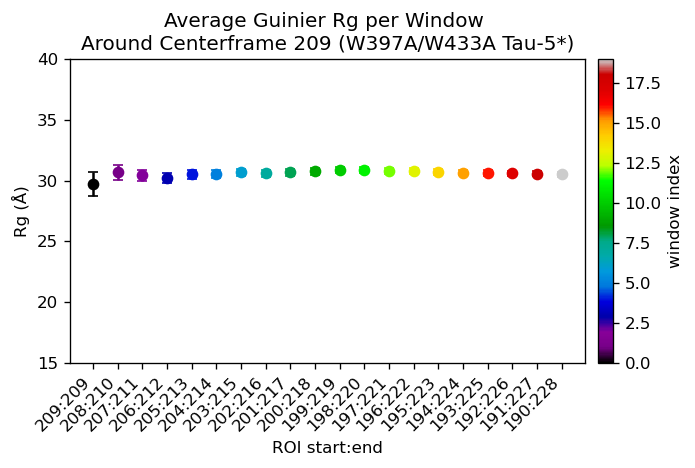

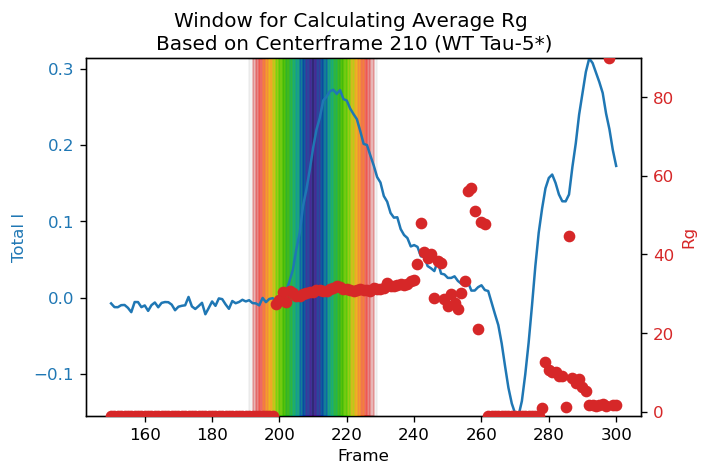

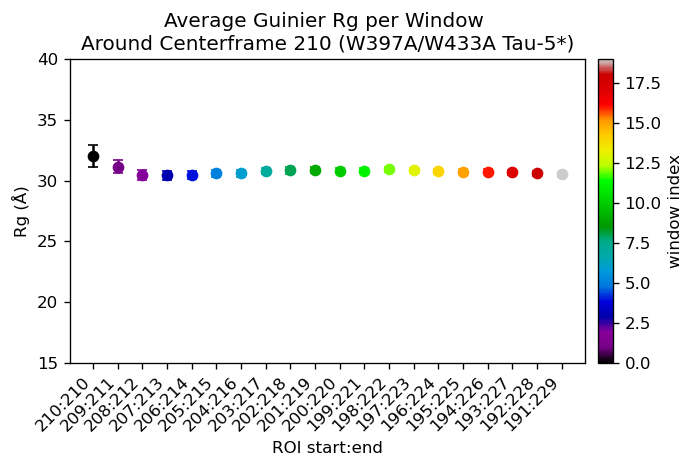

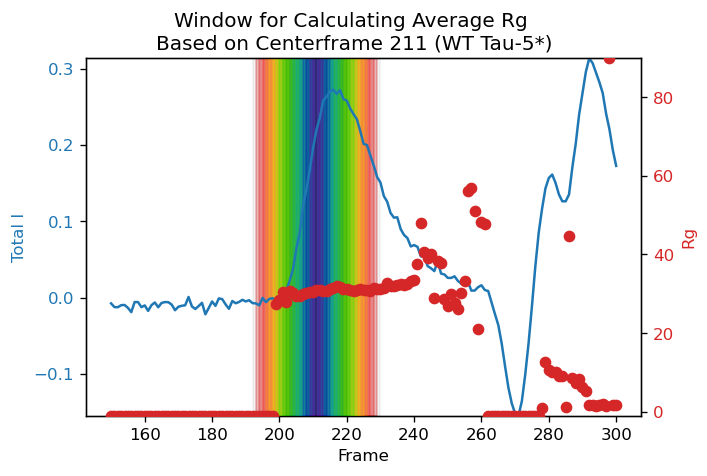

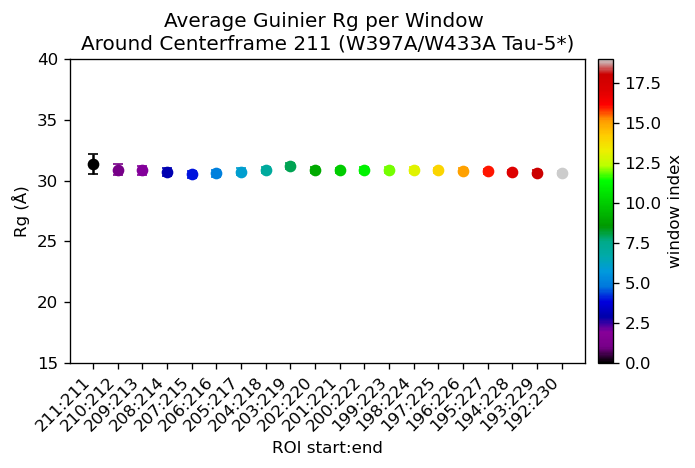

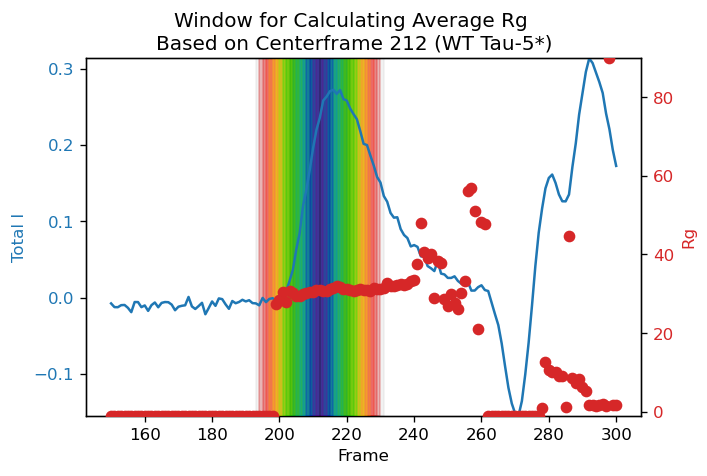

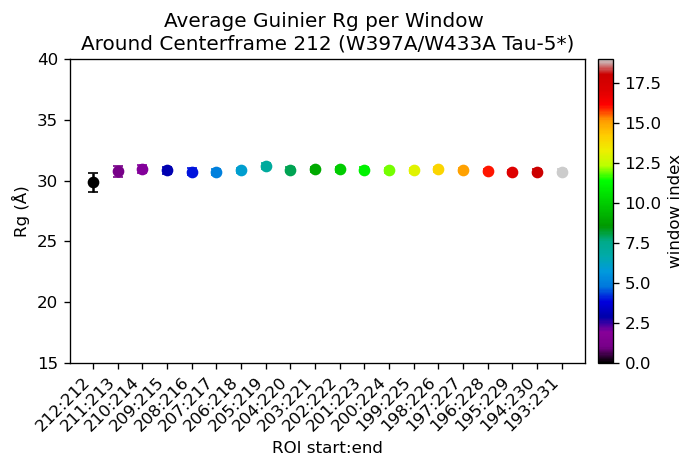

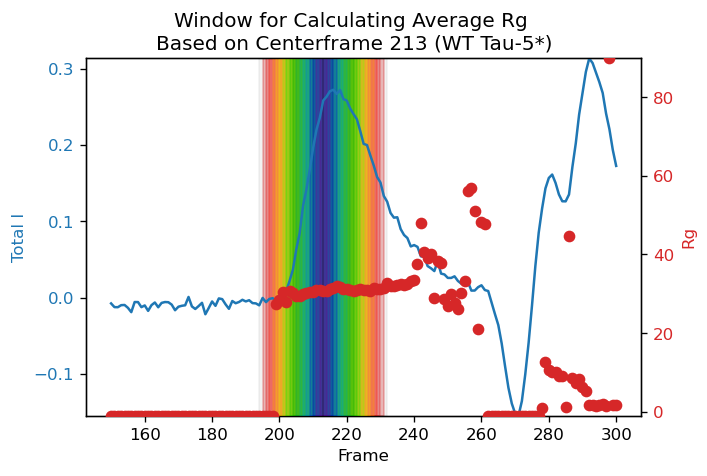

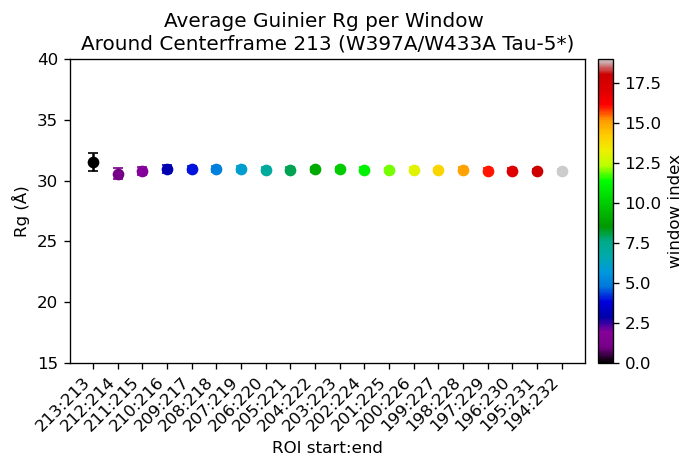

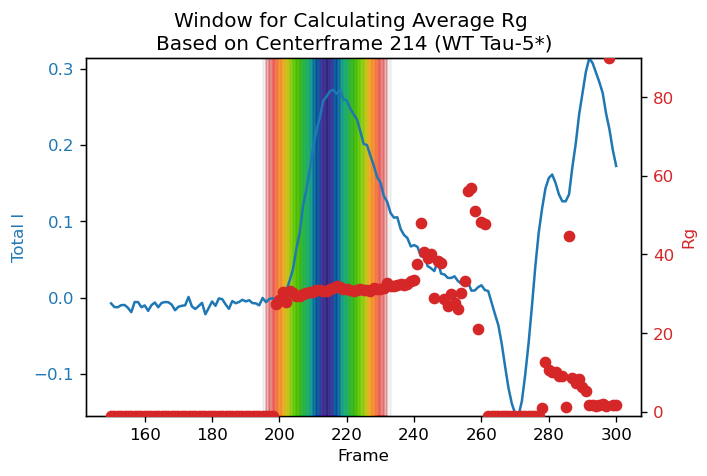

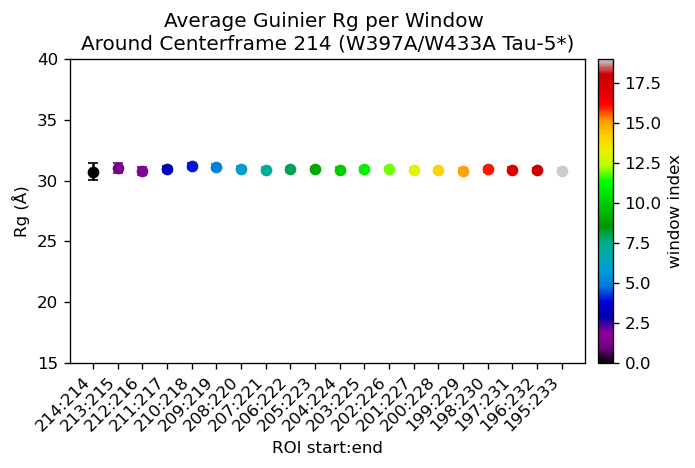

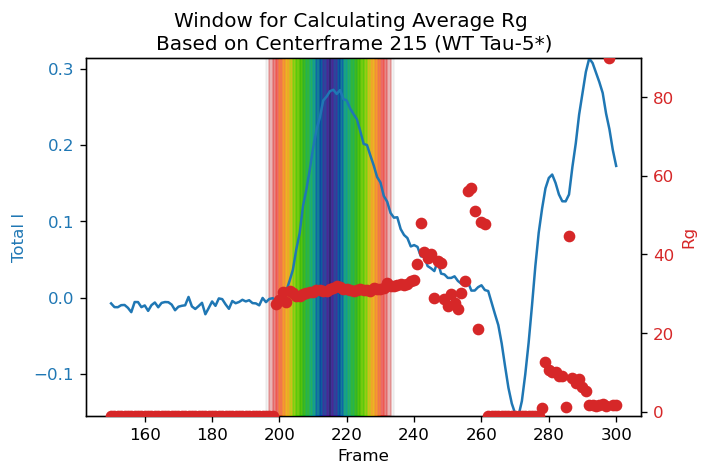

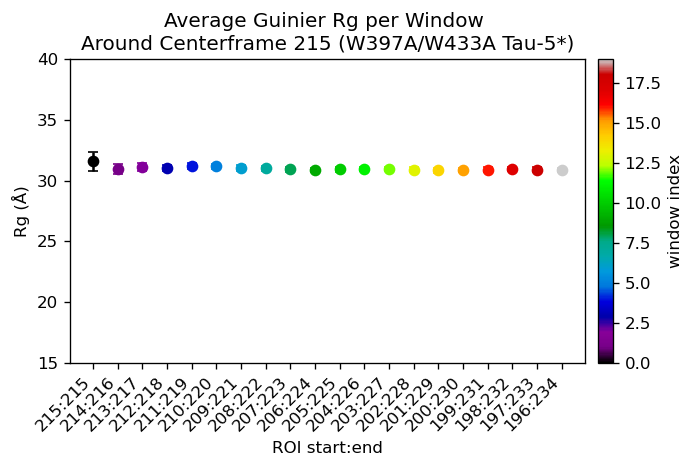

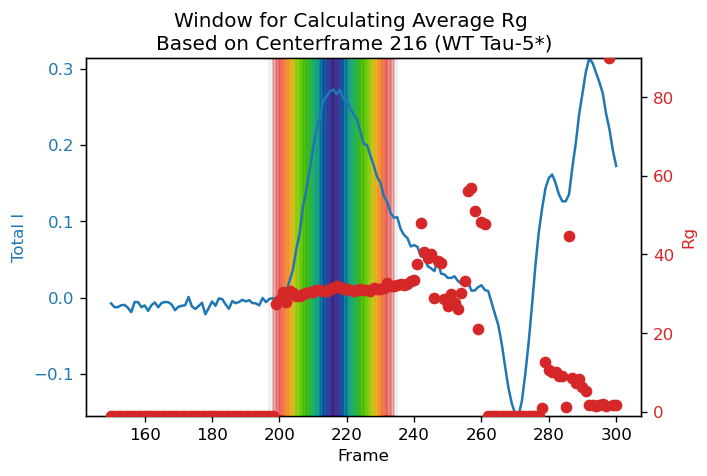

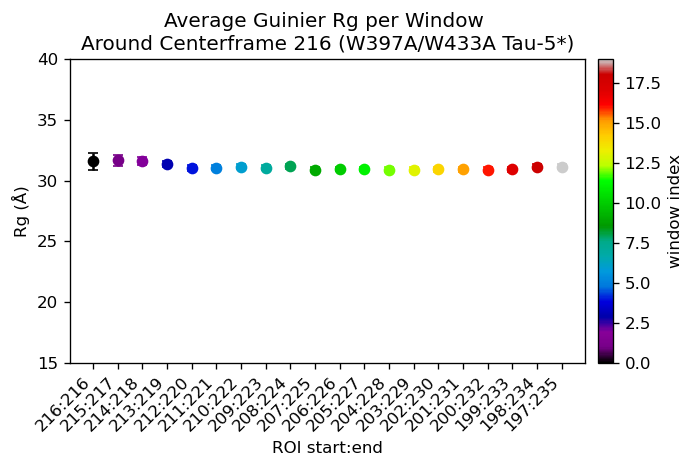

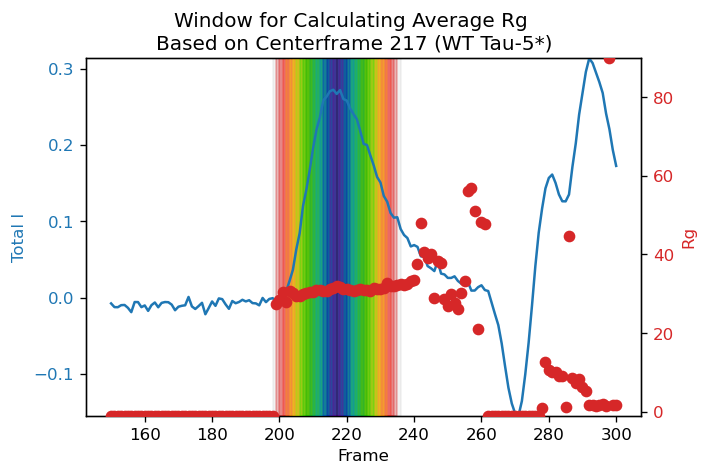

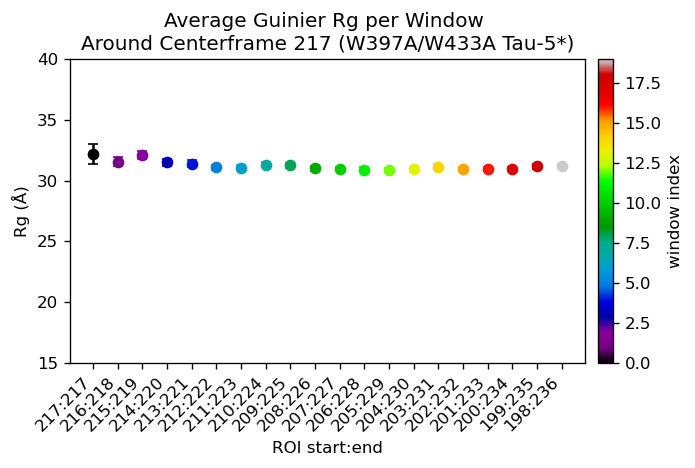

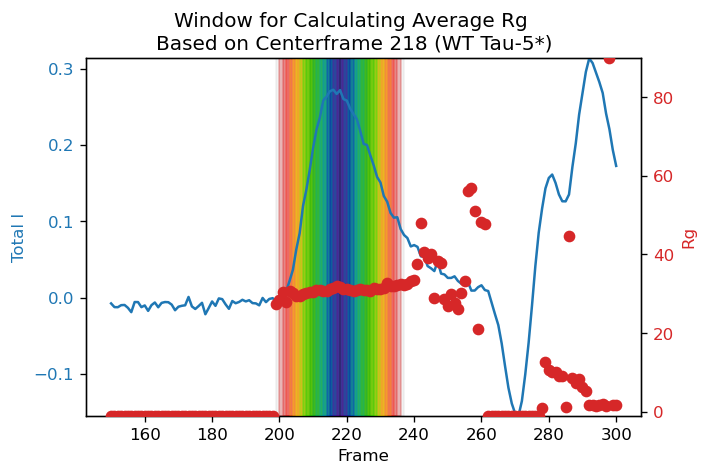

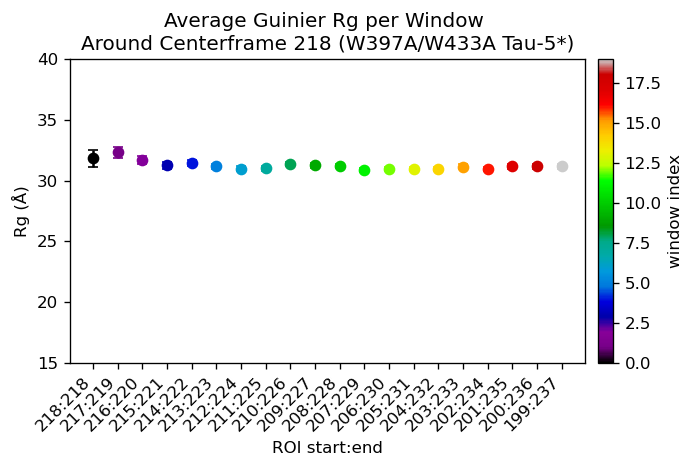

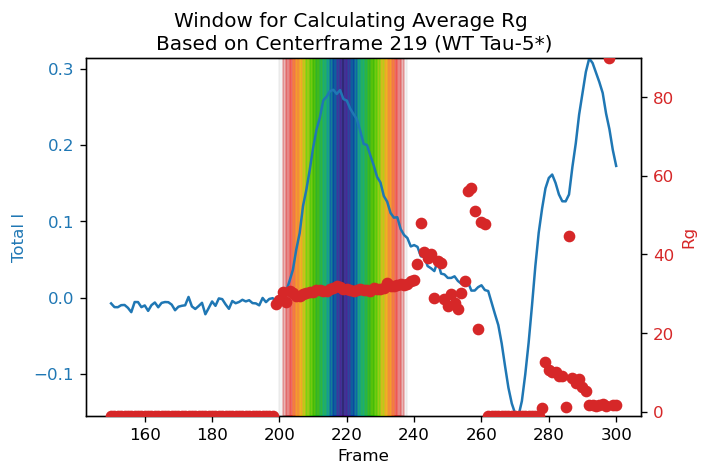

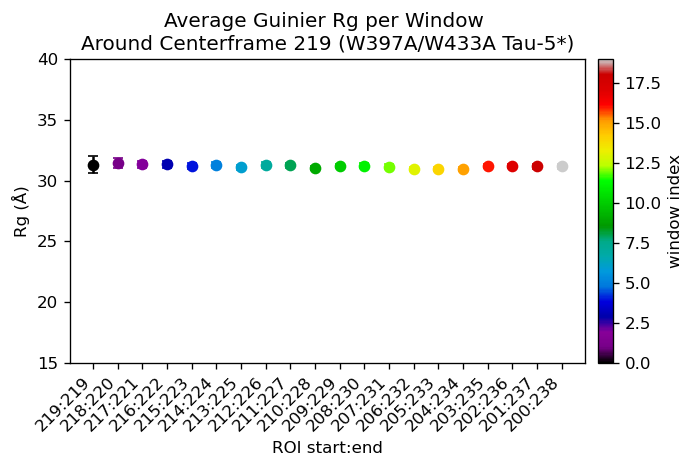

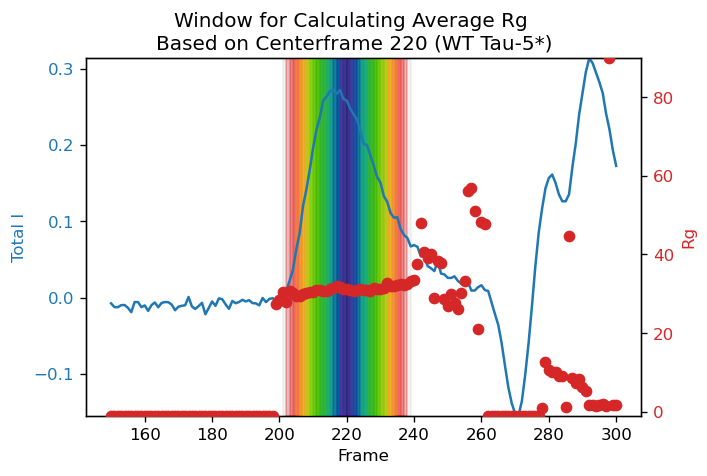

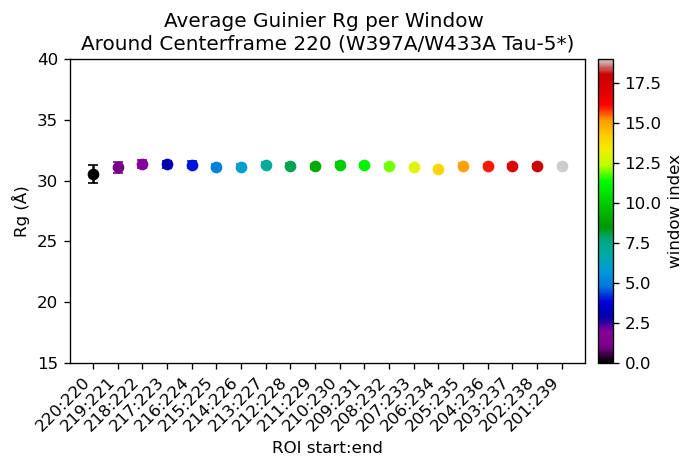

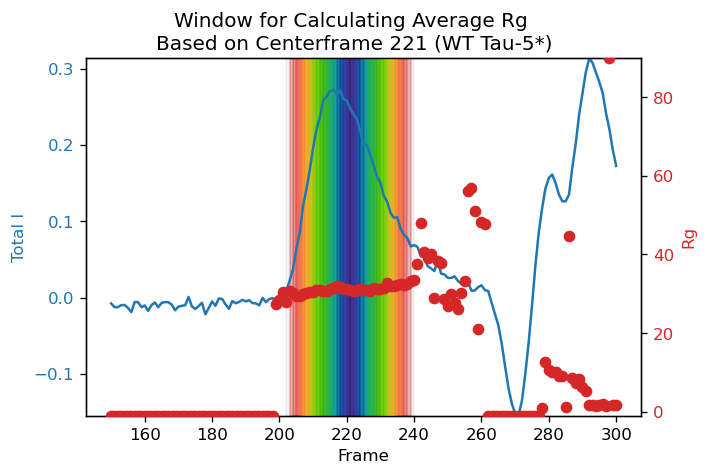

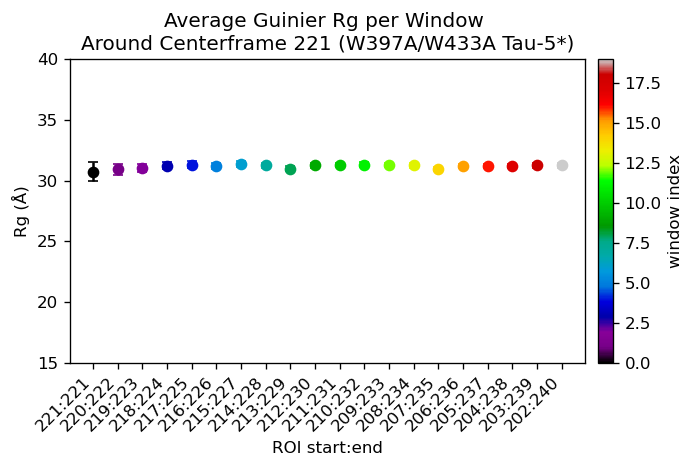

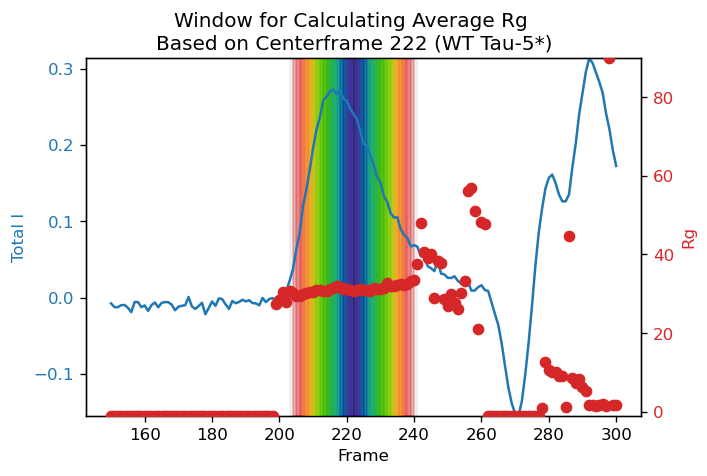

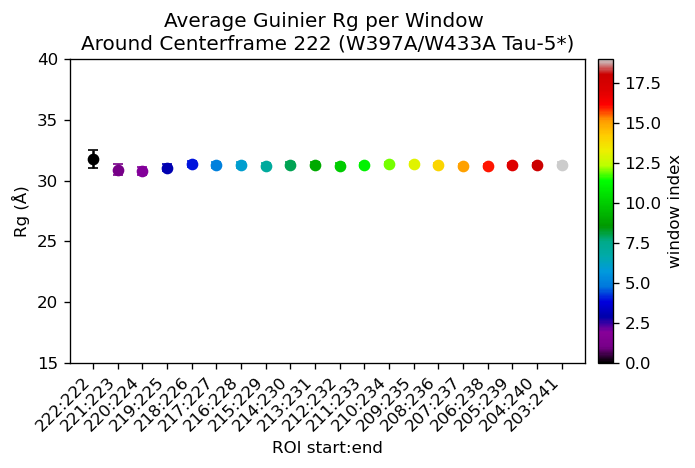

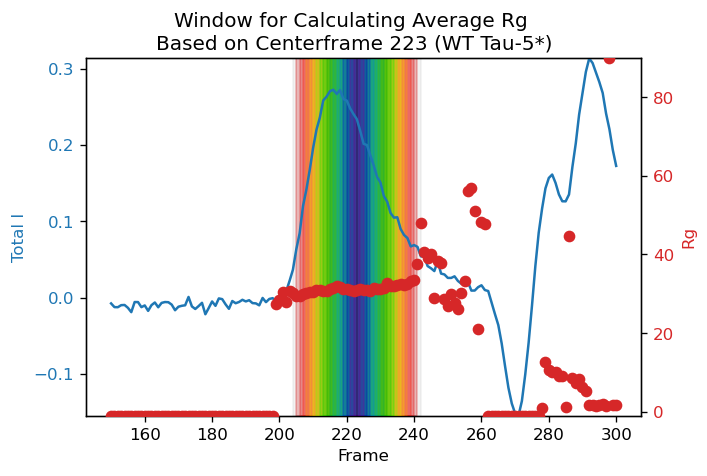

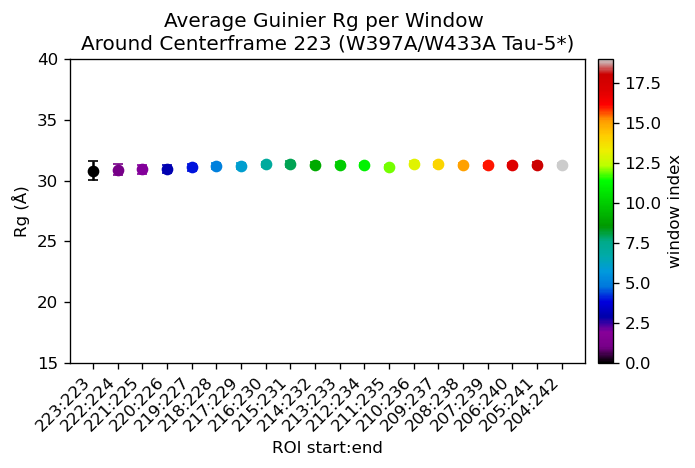

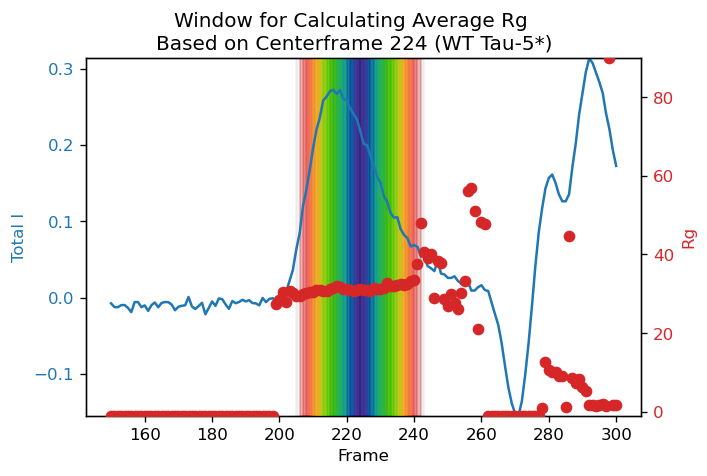

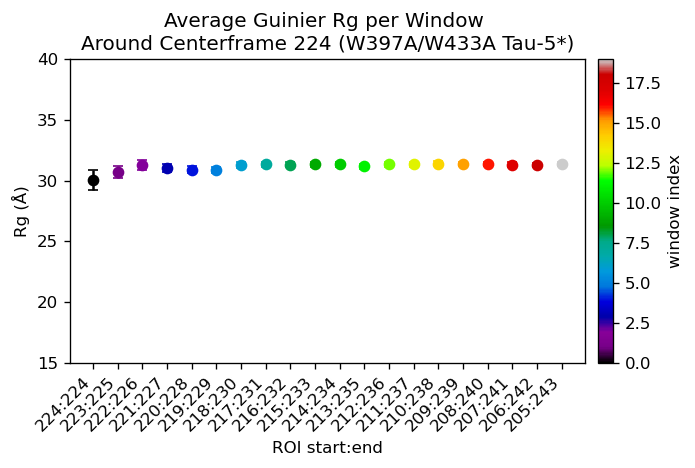

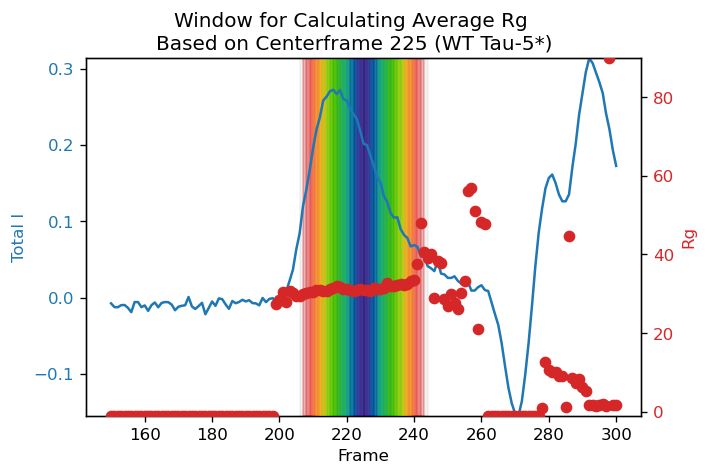

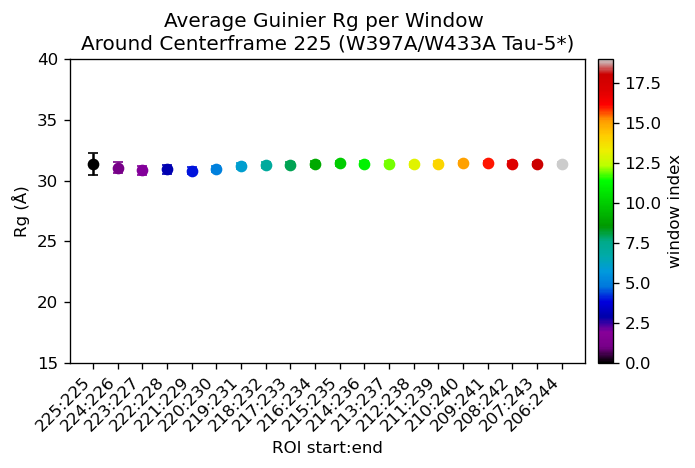

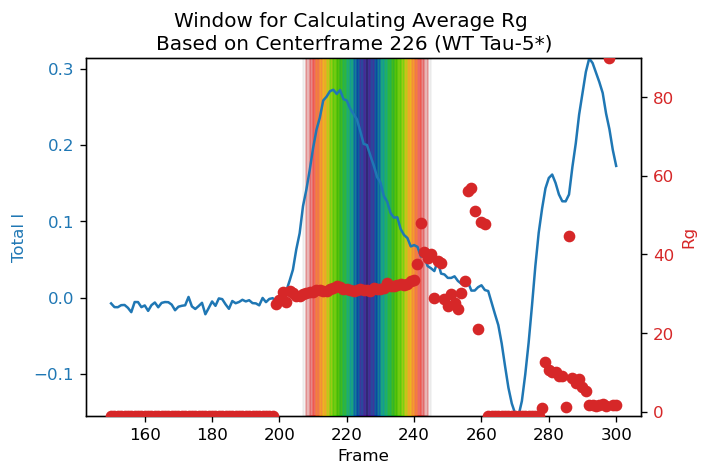

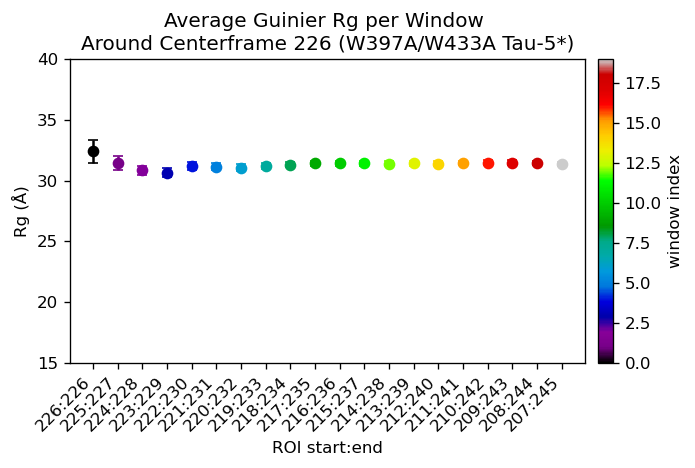

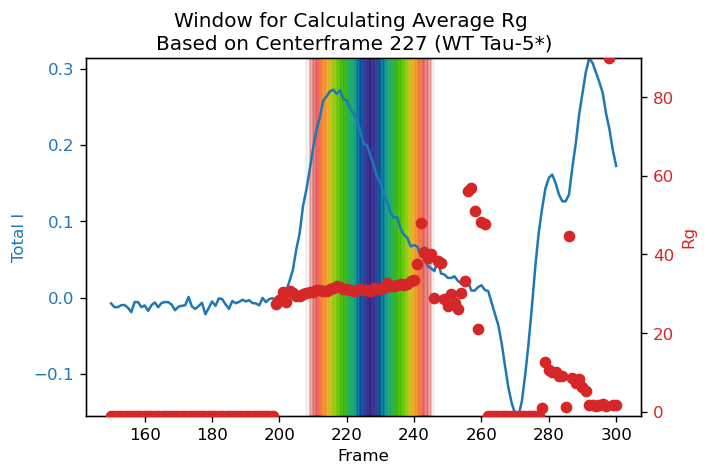

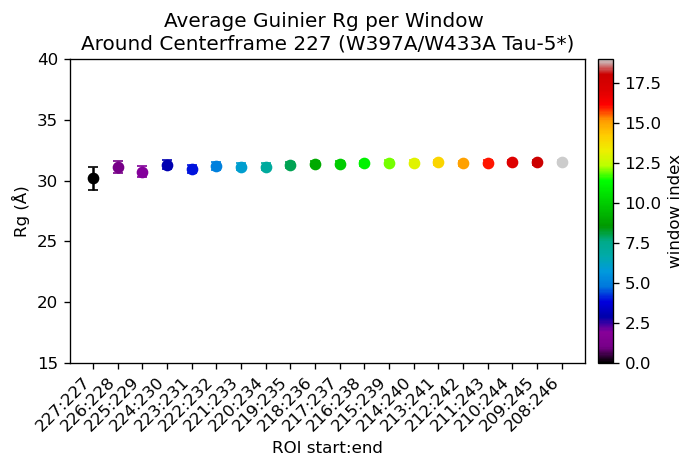

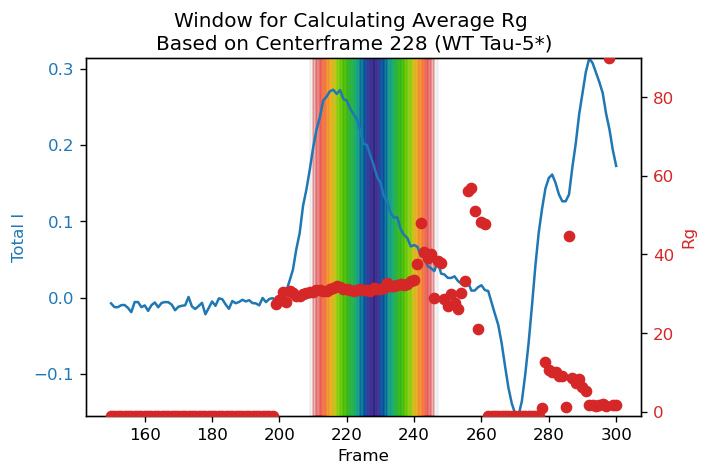

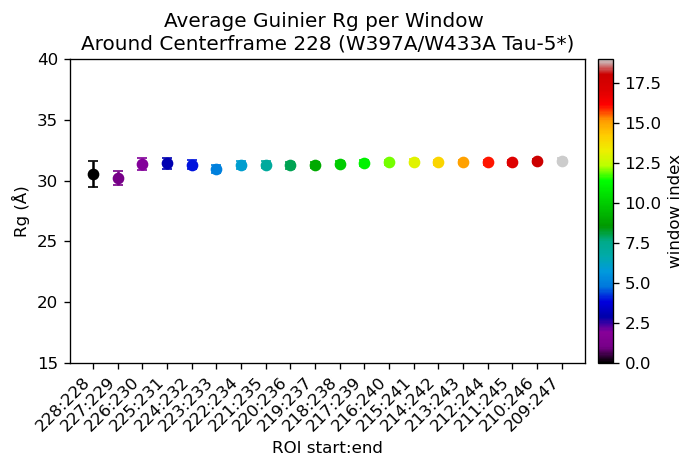

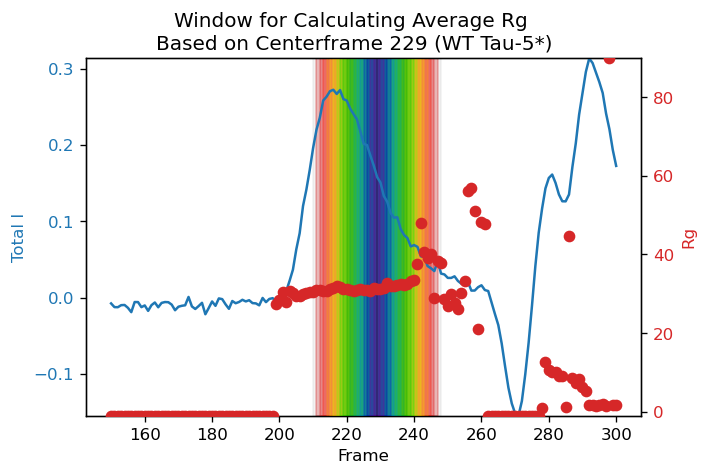

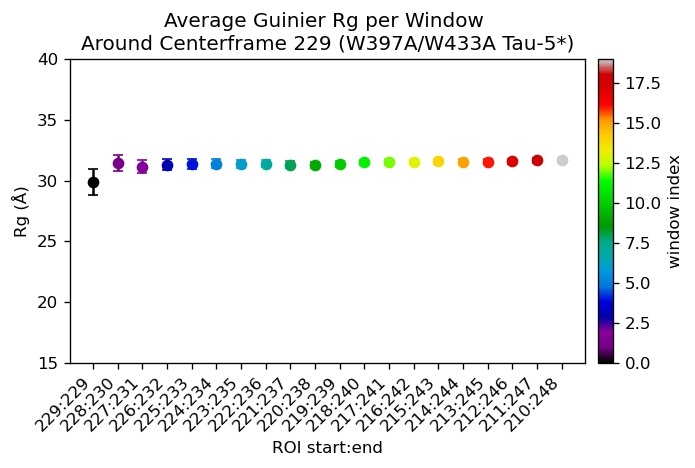

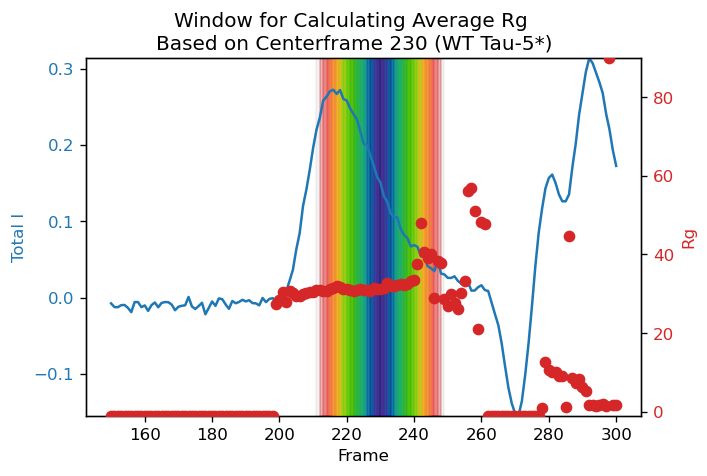

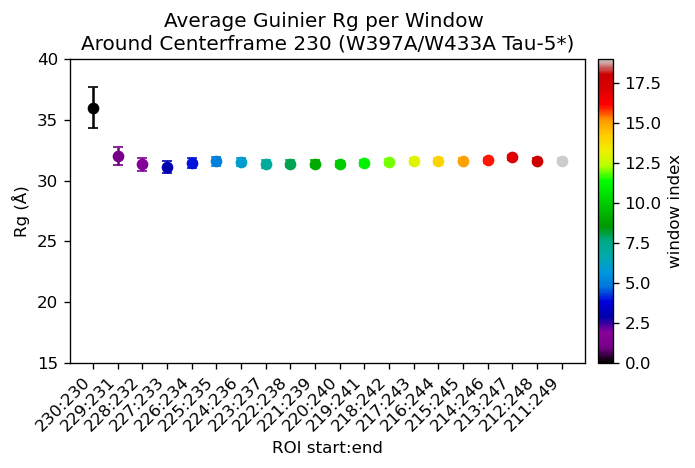

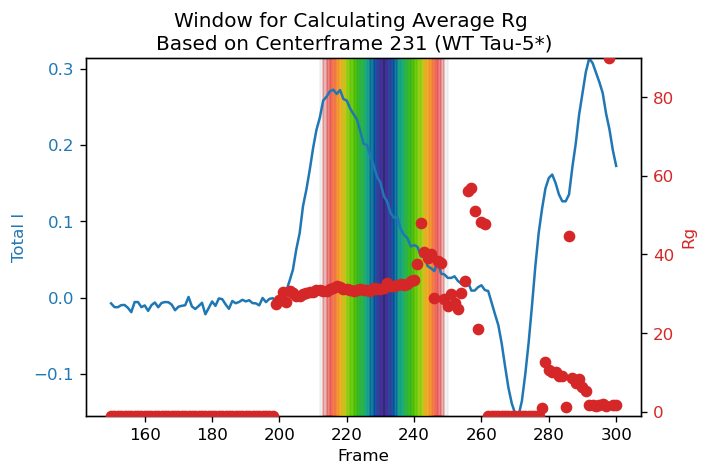

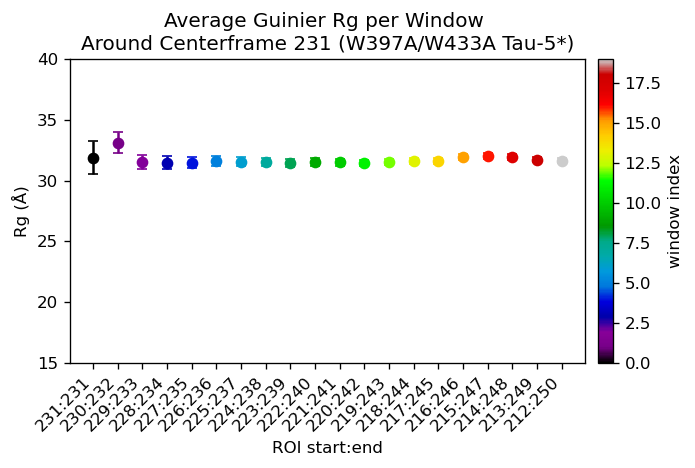

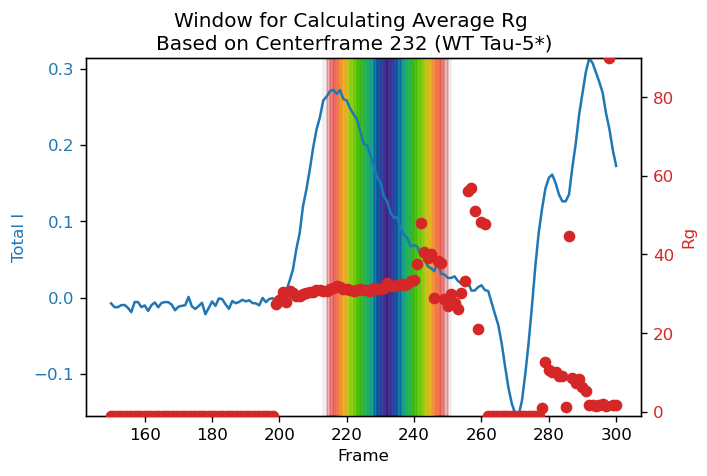

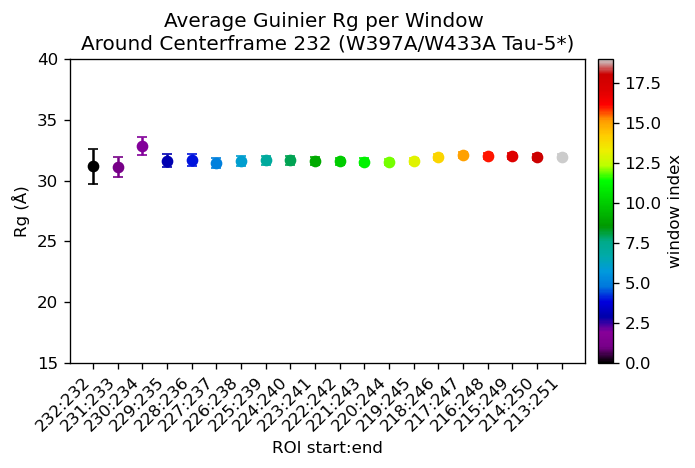

In [46]:
for i in range(range_int):
    centerframe=centerframe_int+i

    # step-wise j values
    steps = list(range(0, step_range_int, 1))
    m = len(steps)

    rg_values = np.full(m, np.nan, dtype=float)
    rg_errors = np.full(m, np.nan, dtype=float)
    x_labels = []

    # prepare colormap and normalizer across indices 0..m-1
    cmap = plt.cm.nipy_spectral
    norm = plt.Normalize(vmin=0, vmax=max(1, m-1))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # for colorbar

    # Plot background once
    fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)
    mask = (frames >= start_frame) & (frames <= end_frame)

    ax1.plot(frames[mask], subtracted_total_i[mask], color='tab:blue', label='Total I', zorder=m+3)
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('Total I', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    try:
        ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
        if ymin == ymax:
            ymin -= 0.5; ymax += 0.5
        ax1.set_ylim(ymin, ymax)
    except ValueError:
        pass

    ax2 = ax1.twinx()
    ax2.plot(frames[mask], rg[mask], color='tab:red', marker='o', linestyle='None', label='Rg', zorder=m+4)
    ax2.set_ylabel('Rg', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    try:
        ymin2, ymax2 = np.nanmin(rg[mask]), np.nanmax(rg[mask])
        if ymin2 == ymax2:
            ymin2 -= 0.5; ymax2 += 0.5
        ax2.set_ylim(ymin2, ymax2)
    except ValueError:
        pass

    # draw windows using evenly spaced cmap samples; later windows get lower zorder so last window is behind
    for k, j in enumerate(steps):
        roi_start = int(centerframe - j)
        roi_end = int(centerframe + j)
        x_labels.append(f"{roi_start}:{roi_end}")

        sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'sub')

        color = cmap(norm(k))          # uses full cmap range
        span_z = m - k                 # decreasing z-order for later (higher k) windows
        ax1.axvspan(roi_start, roi_end, color=color, alpha=0.25, zorder=span_z)

        average_profile = raw.average(sub_profiles_roi)
        try:
            (rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max,
            idx_min, idx_max, r_sq) = raw.auto_guinier(average_profile, settings=my_settings)
            rg_values[k] = rg_j
            rg_errors[k] = rg_err_j
        except Exception as e:
            print(f"Error processing window j={j} (slice {roi_start}:{roi_end}): {e}")

    # add a colorbar legend for the windows (index)
    # cbar = fig.colorbar(sm, ax=ax1, pad=0.02, orientation='vertical')
    # cbar.set_label('window index (0 → first, higher → wider windows)')

    # reserve space for a larger suptitle and set its font size
    fig.tight_layout(rect=[0, 0, 1, 0.92])            # leave top 8% for title
    fig.suptitle(f'Window for Calculating Average Rg \nBased on Centerframe {centerframe} (WT Tau-5*)', y=0.98)                 # adjust fontsize and vertical position
    plt.show()

    # print("steps:", steps)
    # print("rg_values:", rg_values)
    # print("rg_errors:", rg_errors)

    # Plot rg values with per-point colors matching the cmap
    x = np.arange(len(x_labels))
    fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
    for ii in range(len(x)):
        col = cmap(norm(ii))
        if np.isnan(rg_values[ii]) or np.isnan(rg_errors[ii]):
            print(f"Skipping window {x_labels[ii]} due to NaN Rg or error.")
            continue
        ax.errorbar(x[ii], rg_values[ii], yerr=rg_errors[ii], fmt='o', color=col, capsize=3)

    ax.set_xlabel('ROI start:end')
    ax.set_ylabel('Rg (Å)')
    ax.set_title('Average Guinier Rg per Window \nAround Centerframe ' + str(centerframe)+' (W397A/W433A Tau-5*)')

    if m <= 20:
        ticks = x
    else:
        step = max(1, m // 10)
        ticks = x[::step]

    ax.set_xticks(ticks)
    ax.set_xticklabels([x_labels[i] for i in ticks], rotation=45, ha='right')
    ax.set_ylim(bottom=rg_lower_limit,top=rg_upper_limit)  # Rg cannot be negative, so start y-axis at 0
    # reuse scalar mappable for colorbar on this plot too
    fig.colorbar(sm, ax=ax, pad=0.02).set_label('window index')

    fig.tight_layout()
    plt.show()
#

In [196]:
# Set up output directory and PowerPoint file path
out_dir = 'ppt_results'
os.makedirs(out_dir, exist_ok=True)

prs = Presentation()
# make slide bigger (e.g. 16" x 9")
prs.slide_width = Inches(16)
prs.slide_height = Inches(9)

# margins and gap (adjust to taste)
left_margin = Inches(0.4)
right_margin = Inches(0.4)
gap = Inches(0.2)

# compute available width and split between left/right panels
available = prs.slide_width - left_margin - right_margin - gap
width_left = available * 0.65   # 65% for left panel
width_right = available - width_left

In [ ]:
# Make a slide layout
# Make GIF of background frames and rg frames (if needed)

ppt_path = os.path.join(out_dir, 'rg_windows_slides_comp_WT.pptx')

with tempfile.TemporaryDirectory() as tmpdir:
    bg_files = []   # <-- collect bg frames for GIF
    rg_files = []   # <-- collect rg frames for GIF (if needed)

    for i in range(range_int):
        centerframe=centerframe_int+i

        # step-wise j values
        steps = list(range(0, step_range_int, 1))
        m = len(steps)

        rg_values = np.full(m, np.nan, dtype=float)
        rg_errors = np.full(m, np.nan, dtype=float)
        x_labels = []

        # prepare colormap and normalizer across indices 0..m-1
        cmap = plt.cm.nipy_spectral
        norm = plt.Normalize(vmin=0, vmax=max(1, m-1))
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])  # for colorbar
        
        # --- create left panel figure (background + windows) ---
        fig_bg = plt.figure(figsize=(10, 6), dpi=150)
        fig_bg.tight_layout(rect=[0, 0, 1, 0.92])            # leave top 8% for title
        fig_bg.suptitle(f'Window for Calculating Average Rg \nBased on Centerframe {centerframe} (WT Tau-5*)',
                         fontsize=18, y=0.98)      
        gs = fig_bg.add_gridspec(1, 1)
        ax_bg = fig_bg.add_subplot(gs[0, 0])

        mask = (frames >= start_frame) & (frames <= end_frame)
        ax_bg.plot(frames[mask], subtracted_total_i[mask], color='tab:blue', label='Total I', zorder=m + 3)
        ax_bg.set_xlabel('Frame')
        ax_bg.set_ylabel('Total I', color='tab:blue')
        ax_bg.tick_params(axis='y', labelcolor='tab:blue')
        try:
            ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
            if ymin == ymax:
                ymin -= 0.5; ymax += 0.5
            ax_bg.set_ylim(ymin, ymax)
        except ValueError:
            pass

        ax2 = ax_bg.twinx()
        ax2.plot(frames[mask], rg[mask], color='tab:red', marker='o', linestyle='None', label='Rg', zorder=m + 4)
        ax2.set_ylabel('Rg', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')

        for k, j in enumerate(steps):
            roi_start = int(centerframe - j)
            roi_end = int(centerframe + j)
            x_labels.append(f"{roi_start}:{roi_end}")

            sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'sub')

            color = cmap(norm(k))
            span_z = m - k
            ax_bg.axvspan(roi_start, roi_end, color=color, alpha=0.25, zorder=span_z)

            average_profile = raw.average(sub_profiles_roi)
            try:
                (rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max,
                 idx_min, idx_max, r_sq) = raw.auto_guinier(average_profile, settings=my_settings)
                rg_values[k] = rg_j
                rg_errors[k] = rg_err_j
            except Exception as e:
                print(f"Error processing window j={j} (slice {roi_start}:{roi_end}): {e}")

        fname_bg = os.path.join(tmpdir, f'bg_{i:03d}.png')
        fig_bg.tight_layout()
        fig_bg.savefig(fname_bg, bbox_inches='tight', dpi=150)
        plt.close(fig_bg)
        bg_files.append(fname_bg)   # <-- add saved bg image to list


        # --- create right panel figure (rg vs window index) ---
        fig_rg = plt.figure(figsize=(6, 4), dpi=150)
        ax_rg = fig_rg.add_subplot(111)
        x = np.arange(len(x_labels))
        for ii in range(len(x)):
            col = cmap(norm(ii))
            ax_rg.errorbar(x[ii], rg_values[ii], yerr=np.abs(rg_errors[ii]), fmt='o', color=col, capsize=3)

        ax_rg.set_xlabel('ROI start:end')
        ax_rg.set_ylabel('Rg (Å)')
        ax_rg.set_title(f'Average Guinier Rg per Window\nAround Centerframe {centerframe}'+ ' (WT Tau-5*)')
        if len(x_labels) <= 20:
            ticks = x
        else:
            step = max(1, len(x_labels) // 10)
            ticks = x[::step]
        
        ax_rg.set_xticks(ticks)
        ax_rg.set_xticklabels([x_labels[i] for i in ticks], rotation=45, ha='right')
        ax_rg.set_ylim(bottom=rg_lower_limit, top=rg_upper_limit)
        fig_rg.tight_layout()
        fname_rg = os.path.join(tmpdir, f'rg_{i:03d}.png')
        fig_rg.savefig(fname_rg, bbox_inches='tight', dpi=150)
        plt.close(fig_rg)
        rg_files.append(fname_rg)   # <-- add saved rg image to list

        # Histogram figure for Rg values
        fig_hist = plt.figure(figsize=(4, 3), dpi=150)
        valid = ~np.isnan(rg_values)
        if np.count_nonzero(valid) == 0:
            plt.text(0.5, 0.5, "no valid Rg values", ha='center', va='center')
            plt.axis('off')
        else:
            vals = rg_values[valid]
            # choose bins (you can adjust)
            bins = min(12, max(6, len(vals)))
            plt.hist(vals, bins=bins, color=color, alpha=0.8, edgecolor='k')
            mean_rg = np.mean(vals)
            med_rg = np.median(vals)
            plt.axvline(mean_rg, color='k', linestyle='--', label=f'mean={mean_rg:.2f}')
            plt.axvline(med_rg, color='gray', linestyle=':', label=f'median={med_rg:.2f}')
            plt.xlabel('Rg (Å)')
            plt.ylabel('Count')
            plt.legend()
            plt.title(f'Rg Distribution for Centerframe {centerframe}\n(WT Tau-5*)')
            plt.xlim(left=rg_lower_limit, right=rg_upper_limit)  # Rg cannot be negative, so start x-axis at 0
            plt.tight_layout()
        
        fname_hist = os.path.join(tmpdir, f'hist_{i:03d}.png')
        fig_hist.savefig(fname_hist, bbox_inches='tight', dpi=150)
        plt.close(fig_hist)

        #-----------------------------------------#

        # Create slides of saved images (if needed)
        # --- add a slide and place both images at fixed positions ---
        slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank layout
        # left image position and size
        left = Inches(0.4)
        top = Inches(0.7)
        width_left = Inches(8.5)   # adjust to taste
        slide.shapes.add_picture(fname_bg, left, top, width=width_left)

        # right image position and size
        left_r = left + width_left + Inches(0.2)
        top_r = top
        width_right = Inches(6.0)
        # add right picture and place histogram above bottom by using picture height
        pic_rg = slide.shapes.add_picture(fname_rg, left_r, top_r, width=width_right)
        
        # place histogram higher: use a fraction of the right picture height plus a small padding
        hist_top = top_r + pic_rg.height * 0.5 + Inches(2)   # adjust 0.5 and 0.05 as needed
        slide.shapes.add_picture(fname_hist, left_r, hist_top, width=width_right)

        # print(f"Added slide for centerframe {centerframe}")

        #-------------------------#

    # Create GIFs from saved images
    gif_path = os.path.join(out_dir, 'fig_bg_animation_WT.gif')
    try:
        images = [imageio.imread(f) for f in sorted(bg_files)]
        imageio.mimsave(gif_path, images, duration=2)   # adjust duration (seconds/frame)
        print("Saved GIF:", gif_path)
    except Exception as e:
        print("Failed to create GIF:", e)

    gif_path = os.path.join(out_dir, 'fig_rg_animation_WT.gif')
    try:
        images = [imageio.imread(f) for f in sorted(rg_files)]
        imageio.mimsave(gif_path, images, duration=2)   # adjust duration (seconds/frame)
        print("Saved GIF:", gif_path)
    except Exception as e:
        print("Failed to create GIF:", e)

prs.save(ppt_path)
print("Saved PowerPoint:", ppt_path)

Saved GIF: ppt_results/fig_bg_animation_WT.gif
Saved GIF: ppt_results/fig_rg_animation_WT.gif
Saved PowerPoint: ppt_results/rg_windows_slides_comp_WT.pptx


In [ ]:
# Make power point slides for each centerframe and window range, save bg and rg plots as images, then add to slides
ppt_path = os.path.join(out_dir, 'rg_windows_slides_comp_WT_5.pptx')


with tempfile.TemporaryDirectory() as tmpdir:

    for i in range(range_int):
        centerframe=centerframe_int+i

        # step-wise j values
        steps = list(range(0, 5, 1))
        m = len(steps)

        rg_values = np.full(m, np.nan, dtype=float)
        rg_errors = np.full(m, np.nan, dtype=float)
        x_labels = []

        # prepare colormap and normalizer across indices 0..m-1
        cmap = plt.cm.nipy_spectral
        norm = plt.Normalize(vmin=0, vmax=max(1, m-1))
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])  # for colorbar
        
        # --- create left panel figure (background + windows) ---
        fig_bg = plt.figure(figsize=(10, 6), dpi=150)
        fig_bg.tight_layout(rect=[0, 0, 1, 0.92])            # leave top 8% for title
        fig_bg.suptitle(f'Window for Calculating Average Rg \nBased on Centerframe {centerframe} (WT Tau-5*)',
                         fontsize=18, y=0.98)      
        gs = fig_bg.add_gridspec(1, 1)
        ax_bg = fig_bg.add_subplot(gs[0, 0])

        mask = (frames >= start_frame) & (frames <= end_frame)
        ax_bg.plot(frames[mask], subtracted_total_i[mask], color='tab:blue', label='Total I', zorder=m + 3)
        ax_bg.set_xlabel('Frame')
        ax_bg.set_ylabel('Total I', color='tab:blue')
        ax_bg.tick_params(axis='y', labelcolor='tab:blue')
        try:
            ymin, ymax = np.nanmin(subtracted_total_i[mask]), np.nanmax(subtracted_total_i[mask])
            if ymin == ymax:
                ymin -= 0.5; ymax += 0.5
            ax_bg.set_ylim(ymin, ymax)
        except ValueError:
            pass

        ax2 = ax_bg.twinx()
        ax2.plot(frames[mask], rg[mask], color='tab:red', marker='o', linestyle='None', label='Rg', zorder=m + 4)
        ax2.set_ylabel('Rg', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')

        for k, j in enumerate(steps):
            roi_start = int(centerframe - j)
            roi_end = int(centerframe + j)
            x_labels.append(f"{roi_start}:{roi_end}")

            sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'sub')

            color = cmap(norm(k))
            span_z = m - k
            ax_bg.axvspan(roi_start, roi_end, color=color, alpha=0.25, zorder=span_z)

            average_profile = raw.average(sub_profiles_roi)
            try:
                (rg_j, i0_j, rg_err_j, i0_err_j, qmin, qmax, qrg_min, qrg_max,
                 idx_min, idx_max, r_sq) = raw.auto_guinier(average_profile, settings=my_settings)
                rg_values[k] = rg_j
                rg_errors[k] = rg_err_j
            except Exception as e:
                print(f"Error processing window j={j} (slice {roi_start}:{roi_end}): {e}")

        fname_bg = os.path.join(tmpdir, f'bg_{i:03d}.png')
        fig_bg.tight_layout()
        fig_bg.savefig(fname_bg, bbox_inches='tight', dpi=150)
        plt.close(fig_bg)
        bg_files.append(fname_bg)   # <-- add saved bg image to list


        # --- create right panel figure (rg vs window index) ---
        fig_rg = plt.figure(figsize=(6, 4), dpi=150)
        ax_rg = fig_rg.add_subplot(111)
        x = np.arange(len(x_labels))
        for ii in range(len(x)):
            col = cmap(norm(ii))
            ax_rg.errorbar(x[ii], rg_values[ii], yerr=np.abs(rg_errors[ii]), fmt='o', color=col, capsize=3)

        ax_rg.set_xlabel('ROI start:end')
        ax_rg.set_ylabel('Rg (Å)')
        ax_rg.set_title(f'Average Guinier Rg per Window\nAround Centerframe {centerframe}'+ ' (WT Tau-5*)')
        if len(x_labels) <= 20:
            ticks = x
        else:
            step = max(1, len(x_labels) // 10)
            ticks = x[::step]
        
        ax_rg.set_xticks(ticks)
        ax_rg.set_xticklabels([x_labels[i] for i in ticks], rotation=45, ha='right')
        ax_rg.set_ylim(bottom=rg_lower_limit, top=rg_upper_limit)
        fig_rg.tight_layout()
        fname_rg = os.path.join(tmpdir, f'rg_{i:03d}.png')
        fig_rg.savefig(fname_rg, bbox_inches='tight', dpi=150)
        plt.close(fig_rg)

        # Histogram figure for Rg values
        fig_hist = plt.figure(figsize=(4, 3), dpi=150)
        valid = ~np.isnan(rg_values)
        if np.count_nonzero(valid) == 0:
            plt.text(0.5, 0.5, "no valid Rg values", ha='center', va='center')
            plt.axis('off')
        else:
            vals = rg_values[valid]
            # choose bins (you can adjust)
            bins = min(12, max(6, len(vals)))
            plt.hist(vals, bins=bins, color=color, alpha=0.8, edgecolor='k')
            mean_rg = np.mean(vals)
            med_rg = np.median(vals)
            plt.axvline(mean_rg, color='k', linestyle='--', label=f'mean={mean_rg:.2f}')
            plt.axvline(med_rg, color='gray', linestyle=':', label=f'median={med_rg:.2f}')
            plt.xlabel('Rg (Å)')
            plt.ylabel('Count')
            plt.legend()
            plt.title(f'Rg Distribution for Centerframe {centerframe}\n(WT Tau-5*)')
            plt.xlim(left=rg_lower_limit, right=rg_upper_limit)  # Rg cannot be negative, so start x-axis at 0
            plt.tight_layout()
        fname_hist = os.path.join(tmpdir, f'hist_{i:03d}.png')
        fig_hist.savefig(fname_hist, bbox_inches='tight', dpi=150)
        plt.close(fig_hist)

        # --- add a slide and place both images at fixed positions ---
        slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank layout
        # left image position and size
        left = Inches(0.4)
        top = Inches(0.7)
        width_left = Inches(8.5)   # adjust to taste
        slide.shapes.add_picture(fname_bg, left, top, width=width_left)

        # right image position and size
        left_r = left + width_left + Inches(0.2)
        top_r = top
        width_right = Inches(6.0)
        # add right picture and place histogram above bottom by using picture height
        pic_rg = slide.shapes.add_picture(fname_rg, left_r, top_r, width=width_right)
        
        # place histogram higher: use a fraction of the right picture height plus a small padding
        hist_top = top_r + pic_rg.height * 0.5 + Inches(2)   # adjust 0.5 and 0.05 as needed
        slide.shapes.add_picture(fname_hist, left_r, hist_top, width=width_right)

        print(f"Added slide for centerframe {centerframe}")

    prs.save(ppt_path)
    print("Saved PowerPoint:", ppt_path)

Added slide for centerframe 315
Added slide for centerframe 316
Added slide for centerframe 317
Added slide for centerframe 318
Added slide for centerframe 319
Added slide for centerframe 320
Added slide for centerframe 321
Added slide for centerframe 322
Added slide for centerframe 323
Added slide for centerframe 324
Added slide for centerframe 325
Added slide for centerframe 326
Added slide for centerframe 327
Added slide for centerframe 328
Added slide for centerframe 329
Added slide for centerframe 330
Added slide for centerframe 331
Added slide for centerframe 332
Added slide for centerframe 333
Added slide for centerframe 334
Added slide for centerframe 335
Added slide for centerframe 336
Added slide for centerframe 337
Added slide for centerframe 338
Added slide for centerframe 339
Added slide for centerframe 340
Added slide for centerframe 341
Added slide for centerframe 342
Added slide for centerframe 343
Added slide for centerframe 344
Added slide for centerframe 345
Added sl

### Average Profiles 

In [74]:
# Define a region of interest (ROI) for analysis, zero indexed
roi_start = int(220)
roi_end = int(230)

#Get profiles from the series in a given range, zero indexed
profiles_roi = my_series.getSASMList(roi_start, roi_end)
sub_profiles_roi = my_series.getSASMList(roi_start, roi_end, 'baseline')


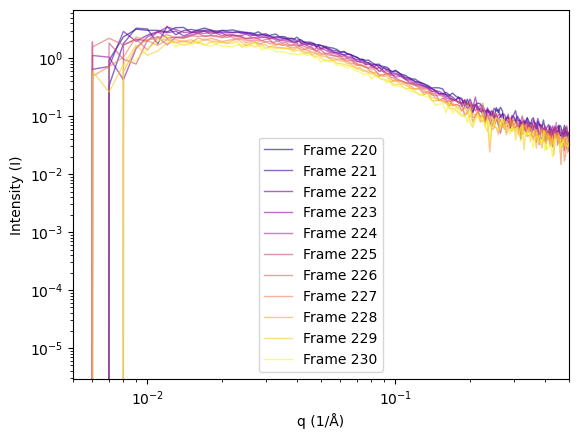

In [75]:
# Plot Sub-profiles
plt.figure()

n = len(sub_profiles_roi)
cmap = plt.cm.plasma  # yellow → purple

for i in range(len(sub_profiles_roi)):
    profile_n = sub_profiles_roi[i]

    q = profile_n.getQ()
    intensity = profile_n.getI()
    error = profile_n.getErr()

    # Normalize index to [0,1] for colormap
    color = cmap(i / (n - 1))

    # Plot individual curves
    plt.plot(q, intensity, color=color, alpha=0.6, linewidth=1, label=f'Frame {roi_start + i}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')
plt.xlim(0.005, 0.5)
plt.legend()


In [76]:
average_profile = raw.average(sub_profiles_roi[:])
average_profile

In [77]:
# AverageProfile 
q_avg=average_profile.getQ()
intensity_avg=average_profile.getI()
error_avg=average_profile.getErr()

Text(0, 0.5, 'Intensity (I)')

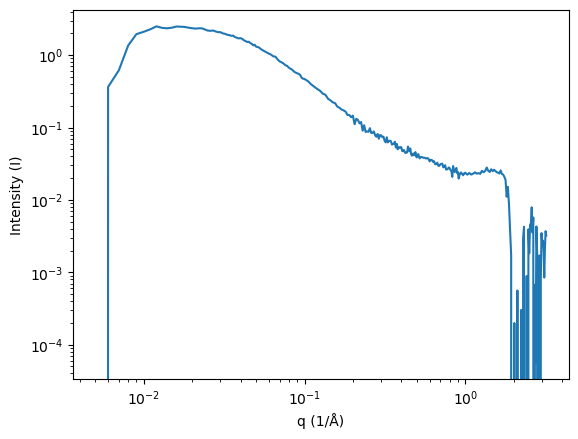

In [78]:
# Average curve
plt.Figure(figsize=(8,6), dpi=120)
plt.plot(q_avg, intensity_avg, linestyle='-', marker=None)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


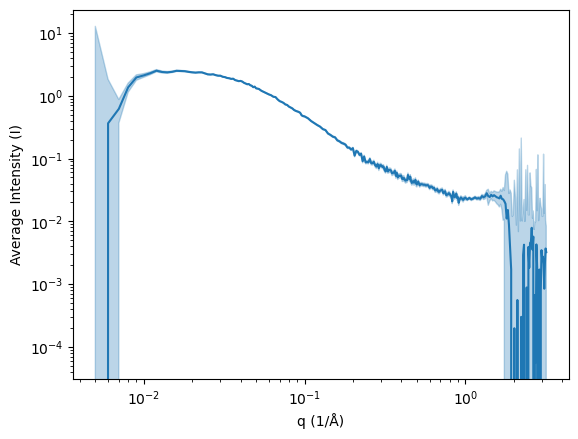

In [79]:
# Plot the average q and intensity data as Log-Log
line, = plt.plot(q_avg, intensity_avg, label='Intensity (normalized)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Average Intensity (I)')
plt.fill_between(
    q_avg,
    intensity_avg - error_avg,
    intensity_avg + error_avg,
    alpha=0.3,
    color=line.get_color()
)
# plt.xlim(0.005, 0.6)
plt.show()
 

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_18532/16234987.py:15: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0.00, 0.6)


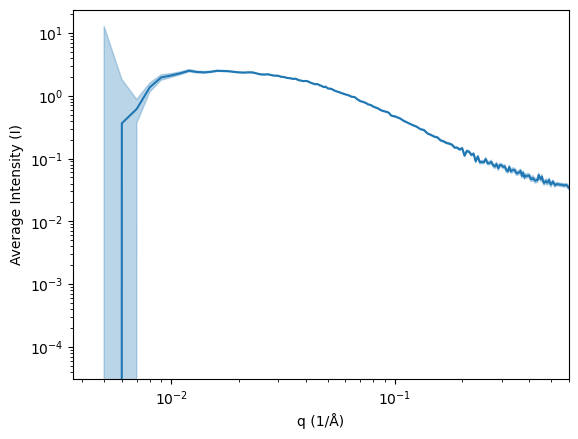

In [80]:
# Plot the average q and intensity data as Log-Log
line, = plt.plot(q_avg, intensity_avg, label='Intensity (normalized)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Average Intensity (I)')
plt.fill_between(
    q_avg,
    intensity_avg - error_avg,
    intensity_avg + error_avg,
    alpha=0.3,
    color=line.get_color()
)
plt.xlim(0.00, 0.6)
plt.show()
 

#### Analyze Average of ROI

In [81]:
#Automatically calculate the Guinier range and fit
(rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
    r_sq) = raw.auto_guinier(average_profile, settings=my_settings)

print(f"Guinier fit results for {average_profile}")
print(f"i0: {i0:.3e} ± {i0_err:.3e}")
print(f"Rg: {rg:.3e} ± {rg_err:.3e}")
print(f"Guinier fit R²: {r_sq:.4f}")
print(f"Guinier range: q = {qmin:.3e} to {qmax:.3e}")
print(f"Guinier range used Rg: q = {qrg_min:.3e} to {qrg_max:.3e}")
print(f"idx_min: {idx_min}, idx_max: {idx_max}")

Guinier fit results for <bioxtasraw.SASM.SASM object at 0x328347750>
i0: 2.650e+00 ± 1.525e-02
Rg: 2.917e+01 ± 2.500e-01
Guinier fit R²: 0.9814
Guinier range: q = 1.200e-02 to 4.400e-02
Guinier range used Rg: q = 3.501e-01 to 1.284e+00
idx_min: 7, idx_max: 39


In [82]:
# AverageProfile 
q=average_profile.getQ()
intensity = average_profile.getI()
error = average_profile.getErr()

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_18532/2859679804.py:10: RuntimeWarning: invalid value encountered in log
  i_ln = np.log(intensity)


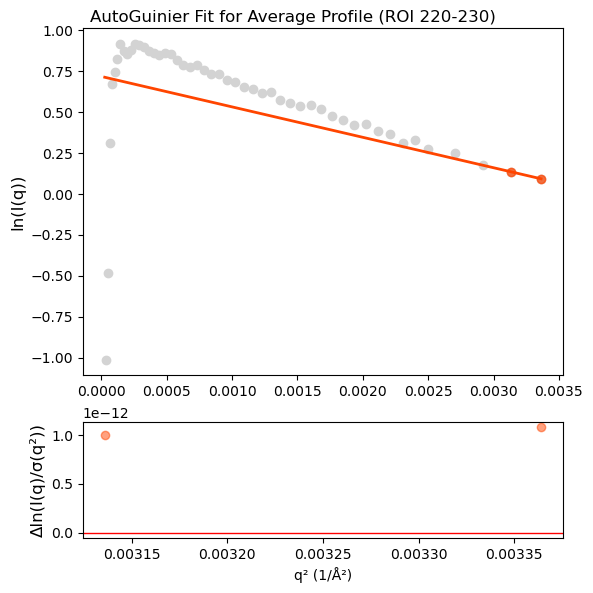

In [87]:
# Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)

# Set up the plot
fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

# Plot Some points of the data for context
q_sq = q**2
i_ln = np.log(intensity)
qmin_sq = qmin**2
qmax_sq = qmax**2
axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o', 
         linestyle='None', color='lightgray', label='Data')
axs[0].set_ylabel('ln(I(q))', fontsize=12)

# Plot the AutoGuinier fit data points
mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
            label='Guinier points', color=color, alpha=0.7)

# Line for the Guinier fit
# optional: fit a straight line to the selected Guinier points
if np.count_nonzero(mask) >= 2:
   #Get fit r squared:
    x = np.square(q[idx_min:idx_max+1])
    y = np.log(intensity[idx_min:idx_max+1])
    sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
    
    a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

    y_fit = SASCalc.linear_func(x, a, b)
    y_line= SASCalc.linear_func(q_sq[0:50], a, b)
    
    gui_err = y - y_fit
    residuals = gui_err / sigma  # weighted residuals
    
    # Plot line of best fit
    axs[0].plot(q_sq[0:50], y_line, '-', label=f'Guinier fit: slope={a:.3e}', 
             color=color, alpha=1, linewidth=2.0, zorder=100)
    
    # Plot residuals in second subplot
    axs[1].plot(x, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
    
    # Set up labels for residuals subplot
    axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
    axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
    axs[1].tick_params(axis='both', labelsize=10)

# Plot Specifications
plt.xlabel('q² (1/Å²)')
plt.suptitle(f'AutoGuinier Fit for Average Profile (ROI {roi_start}-{roi_end})')
plt.show()


Fit with idx_min=0, idx_max=39: Rg=-1.000e+00 ± 1.198e+01, R²=nan
Fit with idx_min=1, idx_max=39: Rg=2.900e+01 ± 2.495e-01, R²=-0.2754
Fit with idx_min=2, idx_max=39: Rg=2.900e+01 ± 2.495e-01, R²=-0.1360
Fit with idx_min=3, idx_max=39: Rg=2.901e+01 ± 2.494e-01, R²=0.3932
Fit with idx_min=4, idx_max=39: Rg=2.904e+01 ± 2.493e-01, R²=0.8092
Fit with idx_min=5, idx_max=39: Rg=2.907e+01 ± 2.493e-01, R²=0.9118
Fit with idx_min=6, idx_max=39: Rg=2.912e+01 ± 2.494e-01, R²=0.9644
Fit with idx_min=7, idx_max=39: Rg=2.917e+01 ± 2.500e-01, R²=0.9814
Fit with idx_min=8, idx_max=39: Rg=2.918e+01 ± 2.514e-01, R²=0.9807
Fit with idx_min=9, idx_max=39: Rg=2.924e+01 ± 2.530e-01, R²=0.9849
Fit with idx_min=10, idx_max=39: Rg=2.931e+01 ± 2.548e-01, R²=0.9910
Fit with idx_min=11, idx_max=39: Rg=2.937e+01 ± 2.577e-01, R²=0.9931
Fit with idx_min=12, idx_max=39: Rg=2.936e+01 ± 2.623e-01, R²=0.9926
Fit with idx_min=13, idx_max=39: Rg=2.934e+01 ± 2.681e-01, R²=0.9921
Fit with idx_min=14, idx_max=39: Rg=2.930e+0

/opt/anaconda3/envs/RAW/lib/python3.14/site-packages/bioxtasraw/RAWAPI.py:1386: RuntimeWarning: invalid value encountered in log
  y = np.log(i)


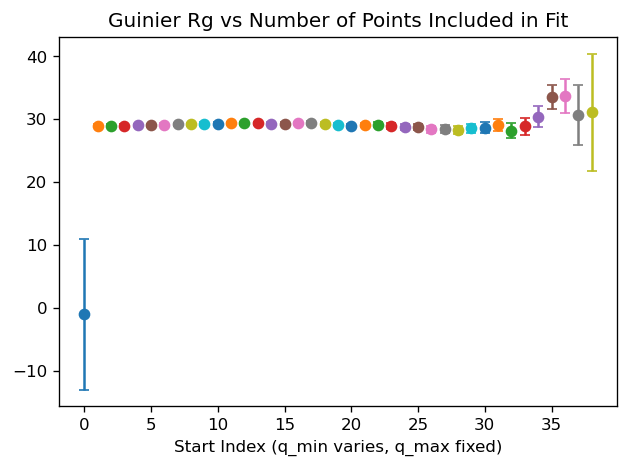

In [84]:
# Iteratively calculate the Guinier range for the average profile, excluding one point at a time from the high-q end, to see how Rg changes

n_points = idx_max # start with a few points beyond the initial idx_max to see the trend
plt.figure(figsize=(6,4), dpi=120)
plt.title('Guinier Rg vs Number of Points Included in Fit')
plt.xlabel('Start Index (q_min varies, q_max fixed)')

for i in range(n_points):
    # Calculate the Guinier range and fit using specified index range

    idx_min = i
    idx_max = n_points
    try:
        (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
            r_sq) = raw.guinier_fit(average_profile, idx_min,idx_max)
        print(f"Fit with idx_min={idx_min}, idx_max={idx_max}: Rg={rg:.3e} ± {rg_err:.3e}, R²={r_sq:.4f}")
    except Exception as e:
        print(f"Error fitting Guinier profile at iteration {i}: {e}")
        continue

    plt.errorbar(idx_min, rg, yerr=rg_err, fmt='o')


Fit with idx_min=0, idx_max=49: Rg=-1.000e+00 ± 1.101e+01, R²=nan
Fit with idx_min=1, idx_max=49: Rg=2.822e+01 ± 1.815e-01, R²=-0.0176
Fit with idx_min=2, idx_max=49: Rg=2.822e+01 ± 1.844e-01, R²=0.3167
Fit with idx_min=3, idx_max=49: Rg=2.822e+01 ± 1.881e-01, R²=0.7929
Fit with idx_min=4, idx_max=49: Rg=2.823e+01 ± 1.912e-01, R²=0.9467
Fit with idx_min=5, idx_max=49: Rg=2.824e+01 ± 1.949e-01, R²=0.9753
Fit with idx_min=6, idx_max=49: Rg=2.826e+01 ± 1.999e-01, R²=0.9892
Fit with idx_min=7, idx_max=49: Rg=2.827e+01 ± 2.056e-01, R²=0.9932
Fit with idx_min=8, idx_max=49: Rg=2.827e+01 ± 2.095e-01, R²=0.9929
Fit with idx_min=9, idx_max=49: Rg=2.829e+01 ± 2.125e-01, R²=0.9936
Fit with idx_min=10, idx_max=49: Rg=2.831e+01 ± 2.155e-01, R²=0.9946
Fit with idx_min=11, idx_max=49: Rg=2.832e+01 ± 1.527e-01, R²=0.9947
Fit with idx_min=12, idx_max=49: Rg=2.830e+01 ± 1.526e-01, R²=0.9946
Fit with idx_min=13, idx_max=49: Rg=2.828e+01 ± 1.522e-01, R²=0.9946
Fit with idx_min=14, idx_max=49: Rg=2.825e+01

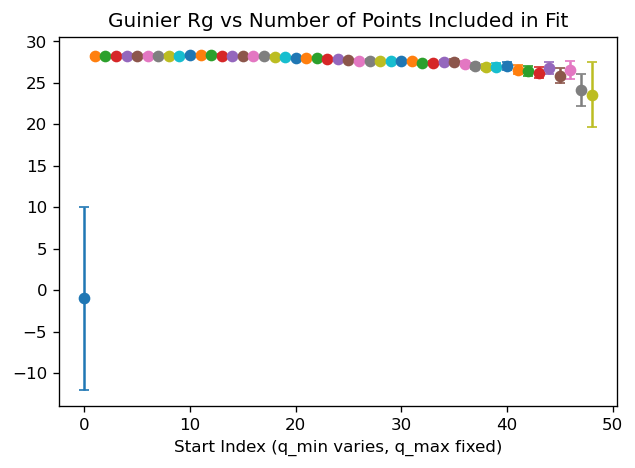

In [85]:
# Iteratively calculate the Guinier range for the average profile, excluding one point at a time from the high-q end, to see how Rg changes

(rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
    r_sq) = raw.auto_guinier(average_profile, settings=my_settings)

n_points = idx_max+10 # start with a few points beyond the initial idx_max to see the trend
plt.figure(figsize=(6,4), dpi=120)
plt.title('Guinier Rg vs Number of Points Included in Fit')
plt.xlabel('Start Index (q_min varies, q_max fixed)')

for i in range(n_points):
    # Calculate the Guinier range and fit using specified index range

    idx_min = i
    idx_max = n_points
    try:
        (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
            r_sq) = raw.guinier_fit(average_profile, idx_min,idx_max)
        print(f"Fit with idx_min={idx_min}, idx_max={idx_max}: Rg={rg:.3e} ± {rg_err:.3e}, R²={r_sq:.4f}")
    except Exception as e:
        print(f"Error fitting Guinier profile at iteration {i}: {e}")
        continue

    plt.errorbar(idx_min, rg, yerr=rg_err, fmt='o')

    



In [80]:
# Manual Guinier fit using a specified index range, for example idx_min=1, idx_max=45
# Calculate the Guinier range and fit using specified index range

idx_min = 3
idx_max = 41

(rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
    r_sq) = raw.guinier_fit(average_profile, idx_min,idx_max)

print(f"i0: {i0:.3e} ± {i0_err:.3e}")
print(f"Rg: {rg:.3e} ± {rg_err:.3e}")
print(f"Guinier fit R²: {r_sq:.4f}")
print(f"Guinier range: q = {qmin:.3e} to {qmax:.3e}")
print(f"Guinier range used Rg: q = {qrg_min:.3e} to {qrg_max:.3e}")
print(f"idx_min: {idx_min}, idx_max: {idx_max}")

i0: 5.243e+00 ± 1.621e-02
Rg: 3.078e+01 ± 1.390e-01
Guinier fit R²: 0.9888
Guinier range: q = 8.000e-03 to 4.600e-02
Guinier range used Rg: q = 2.463e-01 to 1.416e+00
idx_min: 3, idx_max: 41


/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_15372/543922441.py:11: RuntimeWarning: invalid value encountered in log
  I_ln = np.log(intensity)


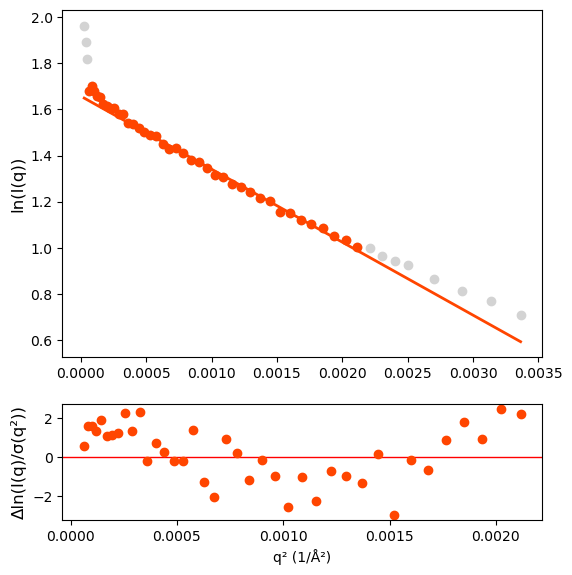

In [81]:
# Plot the q and intensity data from Manual Guinier plot (ln(I) vs q^2)

# Set up the plot
fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)


# Plot points [0:50] of the data for context
q_sq = q ** 2
I_ln = np.log(intensity)

axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o', 
         linestyle='None', color='lightgray', label='Data')
axs[0].set_ylabel('ln(I(q))', fontsize=12)

# Plot the ManualGuinier fit data points
qmin_sq = qmin**2
qmax_sq = qmax**2

mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
            label='Guinier points', color=color)


# Line for the Manual Guinier fit
if np.count_nonzero(mask) >= 2:
   #Get fit r squared:
    x = np.square(q[idx_min:idx_max+1])
    y = np.log(intensity[idx_min:idx_max+1])
    sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
    
    a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

    y_fit = SASCalc.linear_func(x, a, b)
    y_line= SASCalc.linear_func(q_sq[0:50], a, b)

    gui_err = y - y_fit
    residuals = gui_err / sigma  # weighted residuals
    
    # Plot line of best fit
    axs[0].plot(q_sq[0:50], y_line, '-', label=f'Guinier fit: slope={a:.3e}', 
             color=color, alpha=1, linewidth=2.0, zorder=100)
    
    # Plot residuals in second subplot
    axs[1].plot(x, residuals, marker='o', linestyle='None', color=color)
    
    # Set up labels for residuals subplot
    axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
    axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
    axs[1].tick_params(axis='both', labelsize=10)
    
plt.xlabel('q² (1/Å²)')
# plt.ylabel('ln(I)')
plt.show()

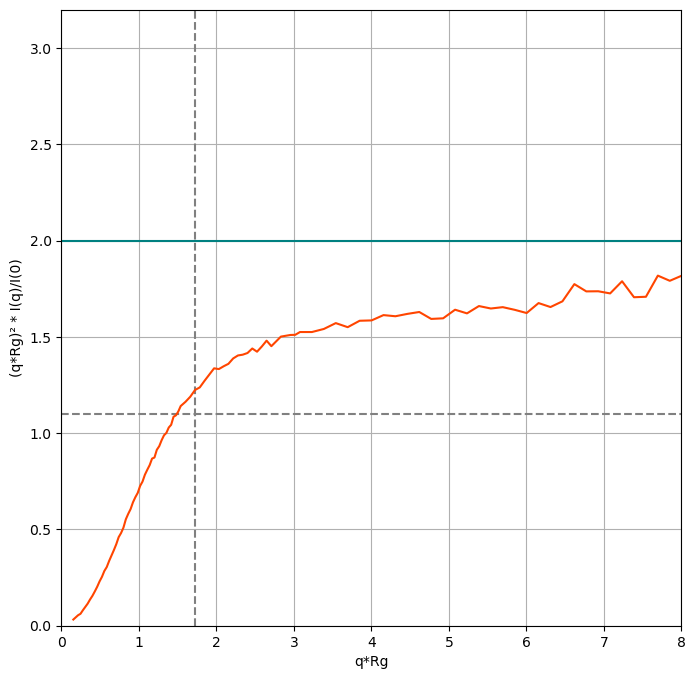

In [82]:
# Kratky Analysis

# Calculate Kratky parameters
xkrat = q * rg 
ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0

# Set up plot
plt.figure(figsize=(8,8))        
plt.xlabel('q*Rg')
plt.ylabel('(q*Rg)² * I(q)/I(0)')

plt.axvline(x=1.73, color='grey', linestyle='--')
plt.axhline(y=1.1, color='grey', linestyle='--', label='1.1')
plt.axhline(y=2, color='teal', linestyle='-') 
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 3.2) 

# Plot Kratky curve
plt.plot(xkrat, ykrat, linestyle='-', color=color, label='Kratky plot')

Auto-determined Dmax: 114.00 Å
GNOM fit results for Dmax=114 Å:
Dmax: 114.00 Å
Rg: 3.268e+01 ± 2.377e-01 Å
i0: 5.317e+00


Text(0, 0.5, 'P(Rg) / I0')

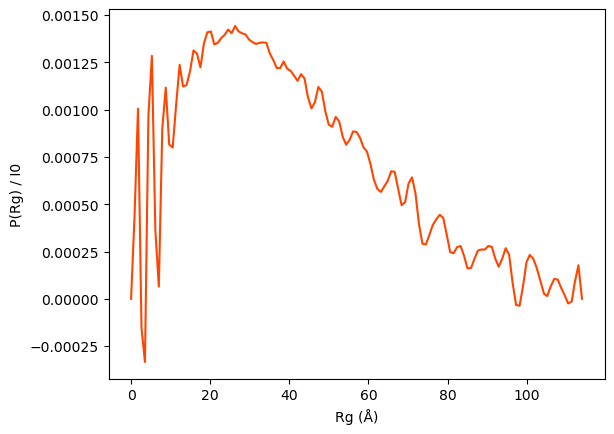

In [86]:
#Use the auto_dmax function to find the best Dmax and then calculate the IFT using GNOM
dmax = raw.auto_dmax(average_profile)
print(f"Auto-determined Dmax: {dmax:.2f} Å")

(gi_gnom_ift, gi_gnom_dmax, gi_gnom_rg, gi_gnom_i0, gi_gnom_rg_err,
    gi_gnom_i0_err, gi_gnom_total_est, gi_gnom_chi_sq, gi_gnom_alpha,
    gi_gnom_quality) = raw.gnom(average_profile, dmax)

print(f"GNOM fit results for Dmax={dmax} Å:")
print(f"Dmax: {gi_gnom_dmax:.2f} Å")
print(f"Rg: {gi_gnom_rg:.3e} ± {gi_gnom_rg_err:.3e} Å")

iftm = gi_gnom_ift

i0 = float(iftm.getParameter('i0'))
print(f"i0: {i0:.3e}")

# Set Plot Specifications
plt.plot(iftm.r, iftm.p/i0, color=color)
plt.xlabel('Rg (Å)')
plt.ylabel('P(Rg) / I0')

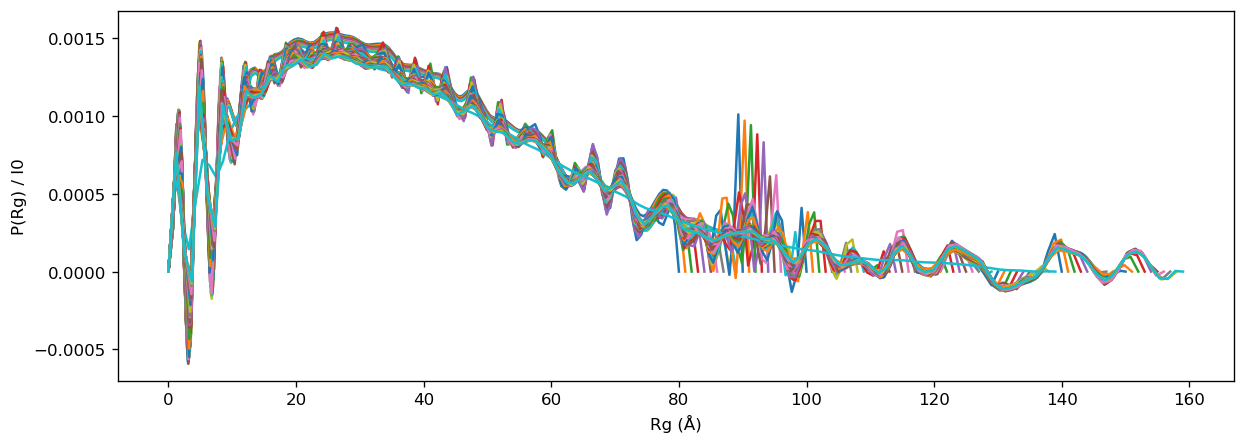

In [102]:
dmax_values = np.arange(80, 160, 1)

plt.figure(figsize=(12,4), dpi=120)
plt.xlabel('Rg (Å)')
plt.ylabel('P(Rg) / I0')

for dmax in dmax_values:
    try:
        (gi_gnom_ift, gi_gnom_dmax, gi_gnom_rg, gi_gnom_i0, gi_gnom_rg_err,
            gi_gnom_i0_err, gi_gnom_total_est, gi_gnom_chi_sq, gi_gnom_alpha,
            gi_gnom_quality) = raw.gnom(average_profile, dmax)
        # print(f"Dmax: {gi_gnom_dmax:.2f} Å, Rg: {gi_gnom_rg:.2f} Å ± {gi_gnom_rg_err:.2f} Å")
        
        iftm = gi_gnom_ift
        i0 = float(iftm.getParameter('i0'))

        plt.plot(iftm.r, iftm.p/i0, label = f'Dmax={dmax} Å')

    except Exception as e:
        print(f"Error fitting GNOM with Dmax={dmax} Å: {e}")

# plt.legend()

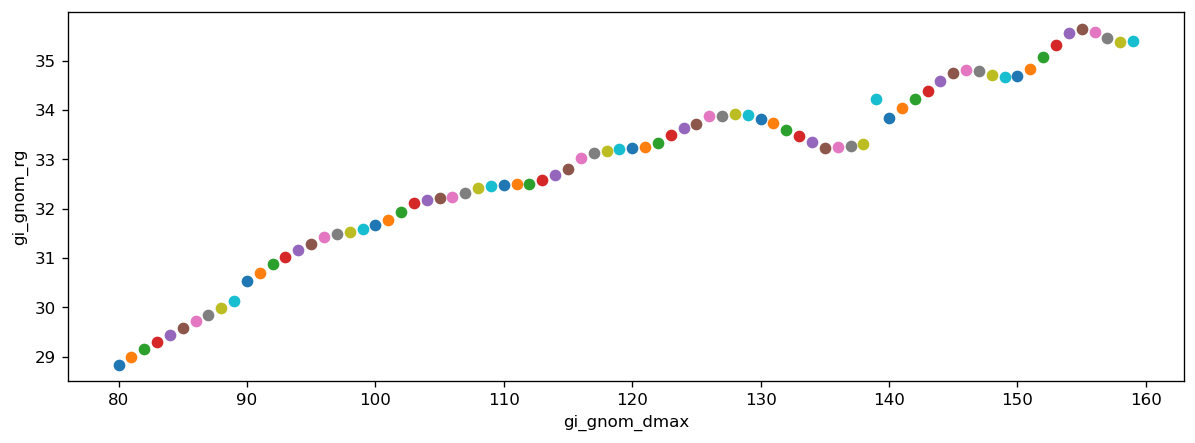

In [106]:
dmax_values = np.arange(80, 160, 1)

plt.figure(figsize=(12,4), dpi=120)
plt.xlabel('gi_gnom_dmax')
plt.ylabel('gi_gnom_rg')

for dmax in dmax_values:
    try:
        (gi_gnom_ift, gi_gnom_dmax, gi_gnom_rg, gi_gnom_i0, gi_gnom_rg_err,
            gi_gnom_i0_err, gi_gnom_total_est, gi_gnom_chi_sq, gi_gnom_alpha,
            gi_gnom_quality) = raw.gnom(average_profile, dmax)
        # print(f"Dmax: {gi_gnom_dmax:.2f} Å, Rg: {gi_gnom_rg:.2f} Å ± {gi_gnom_rg_err:.2f} Å")
        
        plt.plot(gi_gnom_dmax, gi_gnom_rg,'o', label = f'Dmax={dmax} Å')

    except Exception as e:
        print(f"Error fitting GNOM with Dmax={dmax} Å: {e}")

# plt.legend()

GNOM fit results for Dmax=139.0 Å:
Dmax: 139.00 Å
Rg: 3.423e+01 ± 3.708e-01 Å
i0: 5.427e+00


Text(0, 0.5, 'P(Rg) / I0')

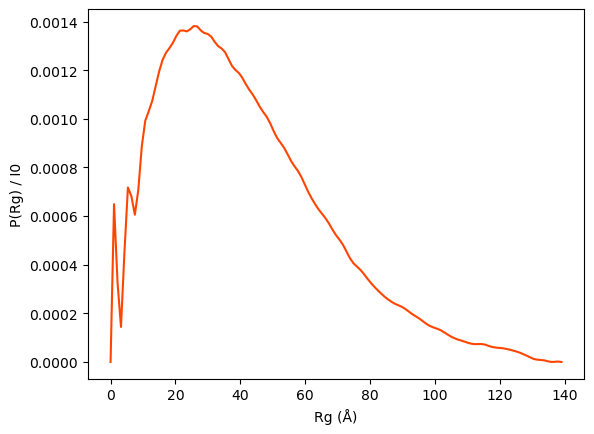

In [103]:
# Use known Dmax to calculate the IFT using GNOM

dmax = 139.0  # example Dmax value in Å

(gi_gnom_ift, gi_gnom_dmax, gi_gnom_rg, gi_gnom_i0, gi_gnom_rg_err,
    gi_gnom_i0_err, gi_gnom_total_est, gi_gnom_chi_sq, gi_gnom_alpha,
    gi_gnom_quality) = raw.gnom(average_profile, dmax)

print(f"GNOM fit results for Dmax={dmax} Å:")
print(f"Dmax: {gi_gnom_dmax:.2f} Å")
print(f"Rg: {gi_gnom_rg:.3e} ± {gi_gnom_rg_err:.3e} Å")


iftm = gi_gnom_ift

i0 = float(iftm.getParameter('i0'))
print(f"i0: {i0:.3e}")

# Set Plot Specifications
plt.plot(iftm.r, iftm.p/i0, color=color)
plt.xlabel('Rg (Å)')
plt.ylabel('P(Rg) / I0')

#### Calculate Extended Guinier

In [97]:
Nres=121
b_Angstrom=5.5
nu_init=0.5
Rg_input=31
q_start_index=3
# qmin_offset=2
# qmax_offset=40

In [88]:
class ExtendedGuinier:
    """
    Extended Guinier analysis for SAXS data.

    Parameters
    ----------
    q : array-like
        q values (Å⁻¹)
    intensity : array-like
        Scattering intensity I(q)
    error : array-like, optional
        Experimental uncertainty. Stored for convenience but not used in fitting.
    """

    def __init__(self, q, intensity, error=None):

        self.q = np.asarray(q, dtype=float)
        self.Iq = np.asarray(intensity, dtype=float)

        if error is None:
            self.error = np.ones_like(self.Iq)
        else:
            self.error = np.asarray(error, dtype=float)

    @staticmethod
    def Rg_nu(b, N, nu):
        g = 1.1615
        return np.sqrt(
            g * (g + 1)
            / (2 * (g + 2 * nu) * (g + 2 * nu + 1))
        ) * b * N**nu

    @staticmethod
    def chisq_extguin(parms, q, log_Iq, Nres, b):

        nu = parms[0]
        log_I0 = parms[1]

        Rg = ExtendedGuinier.Rg_nu(b, Nres, nu)

        log_Iq_fit = (
            log_I0
            - q**2 * Rg**2 / 3
            + 0.0479 * (nu - 0.212) * q**4 * Rg**4
        )

        dI = log_Iq_fit - log_Iq

        return np.dot(dI, dI)

    def analyze(
        self,
        Nres,
        b_Angstrom=5.5,
        nu_init=0.5,
        qcut=None,
        q_start_index=0,
    ):

        q = self.q
        Iq = self.Iq

        valid = np.isfinite(q) & np.isfinite(Iq) & (Iq > 0)

        q = q[valid]
        Iq = Iq[valid]

        if len(q) == 0:
            return None

        if qcut is None:
            Rg_init = self.Rg_nu(b_Angstrom, Nres, 0.6)
            qcut = 2.0 / Rg_init

        mask = (q >= q[q_start_index]) & (q <= qcut)

        qrange = q[mask]
        log_Iq = np.log(Iq[mask])

        if len(qrange) < 3:
            raise ValueError("Not enough points in Guinier region.")

        log_I0_init = log_Iq[0]

        opt_parm = optimize.fmin(
            self.chisq_extguin,
            [nu_init, log_I0_init],
            args=(qrange, log_Iq, Nres, b_Angstrom),
            disp=False,
        )

        nu_final, log_I0_final = opt_parm

        Rg_final = self.Rg_nu(
            b_Angstrom,
            Nres,
            nu_final,
        )

        log_Iq_fit = (
            log_I0_final
            - qrange**2 * Rg_final**2 / 3
            + 0.0479
            * (nu_final - 0.212)
            * qrange**4
            * Rg_final**4
        )

        return {
            "nu": nu_final,
            "Rg": Rg_final,
            "I0": np.exp(log_I0_final),
            "log_I0": log_I0_final,
            "q": qrange,
            "q_squared": qrange**2,
            "log_Iq": log_Iq,
            "log_Iq_fit": log_Iq_fit,
            "residuals": log_Iq_fit - log_Iq,
        }

In [98]:
eg = ExtendedGuinier(q, intensity, error)

result = eg.analyze(Nres=121, q_start_index=q_start_index)

print(result["Rg"])
print(result["nu"])
print(result["I0"])

qrange = result["q"]
log_Iq = result["log_Iq"]
log_Iq_fit = result["log_Iq_fit"]
residuals = result ["residuals"]
I0 = result["I0"]
print(qrange)



33.178905137426206
0.561087231678471
5.411821123440527
[0.008 0.009 0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019
 0.02  0.021 0.022 0.023 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031
 0.032 0.033 0.034 0.035 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043
 0.044 0.045 0.046 0.047 0.048 0.049 0.05 ]


/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_15372/2095491694.py:11: RuntimeWarning: invalid value encountered in log
  I_ln = np.log(intensity)


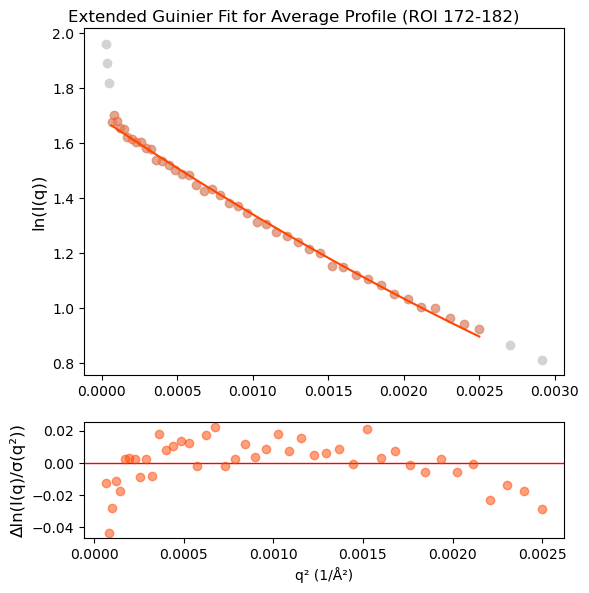

In [100]:
# Plot the q and intensity data from Manual Guinier plot (ln(I) vs q^2)

# Set up the plot
fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)


# Square the q values and take the natural logarithm of the intensity
q_sq = q ** 2
I_ln = np.log(intensity)

# plot the data points for context
max_q = len(qrange)
# mask = (q >= qrange[0]) & (q <= qrange[max_q+10])

start_idx = 0
end_idx = max_q

mask = np.zeros(len(q), dtype=bool)
mask[max(0, start_idx-1):min(len(q), end_idx+5)] = True

axs[0].plot(q_sq[mask], I_ln[mask], marker='o', 
         linestyle='None', color='lightgray', label='Data')
axs[0].set_ylabel('ln(I(q))', fontsize=12)


# Plot the ExtendedGuinier fit data points
axs[0].plot(qrange**2, log_Iq, marker='o', linestyle='None',
            label='Guinier points', color=color, alpha=0.3)
axs[0].plot(qrange**2, log_Iq_fit, linestyle='-', color=color, label='Extended Guinier fit')



# Plot residuals in second subplot
axs[1].plot(qrange**2, residuals, marker='o', 
            linestyle='None', color=color, alpha=0.5)

# Set up labels for residuals subplot
axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
axs[1].tick_params(axis='both', labelsize=10)
    
plt.xlabel('q² (1/Å²)')
plt.suptitle(f'Extended Guinier Fit for Average Profile (ROI {roi_start}-{roi_end})')
plt.show()

# IGNORE

In [ ]:
# extended guinier loop

results = []

for profile in sub_profiles_roi:

    eg = ExtendedGuinier(
        profile.getQ(),
        profile.getI(),
        profile.getErr()
    )

    results.append(
        eg.analyze(Nres=121)
    )